# a) Xử lý giá trị thiếu có kiểm soát

In [18]:
# =============================================================================
# Import thư viện & Thiết lập style
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.impute import IterativeImputer
from sklearn.metrics import mean_squared_error
import time

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "axes.grid": True,
    "grid.color": "#eeeeee",
    "grid.linestyle": "--",
})

PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2"]

In [ ]:
# =============================================================================
# 0. LOAD & PREP DATA (Adult Census – numeric columns only for RMSE eval)
# =============================================================================
print("=" * 70)
print("LOADING DATA")
print("=" * 70)

col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

df_raw = pd.read_csv("../data/raw/adult.csv",
                     header=0, names=col_names, na_values=[" ?", "?"], skipinitialspace=True)

# Chỉ lấy các cột số (numeric) để tính RMSE
NUM_COLS = ["age", "fnlwgt", "education_num",
            "capital_gain", "capital_loss", "hours_per_week"]
NUM_COLS = [c for c in NUM_COLS if c in df_raw.columns]

df_num = df_raw[NUM_COLS].copy()

# Loại bỏ các dòng đã có missing gốc để có "ground truth" sạch
df_clean = df_num.dropna().reset_index(drop=True)
print(f"  Số dòng ground truth (không missing): {len(df_clean):,}")
print(f"  Các cột số: {NUM_COLS}")

LOADING DATA
  Số dòng ground truth (không missing): 32,561
  Các cột số: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']


In [20]:
# =============================================================================
# 1. THIẾT LẬP THỬ NGHIỆM: Tạo MCAR 10% nhân tạo & Hàm đánh giá
# =============================================================================
MISSING_RATE = 0.10
N_RUNS       = 5          # Lặp để tính độ ổn định
RANDOM_SEED  = 42
np.random.seed(RANDOM_SEED)

def inject_mcar(df: pd.DataFrame, rate: float, seed: int) -> tuple:
    """Mask nhân tạo tỷ lệ `rate` giá trị MCAR. Trả về (df_masked, mask)."""
    rng = np.random.default_rng(seed)
    df_masked = df.copy().astype(float)
    mask = pd.DataFrame(False, index=df.index, columns=df.columns)

    total_cells = df.size
    n_missing = int(total_cells * rate)

    flat_idx = rng.choice(total_cells, size=n_missing, replace=False)
    rows, cols = np.divmod(flat_idx, df.shape[1])
    for r, c in zip(rows, cols):
        df_masked.iat[r, c] = np.nan
        mask.iat[r, c] = True

    return df_masked, mask

def compute_rmse(original: pd.DataFrame, imputed: pd.DataFrame, mask: pd.DataFrame) -> float:
    """RMSE chỉ trên các vị trí bị mask (ground-truth vs imputed)."""
    true_vals    = original.values[mask.values]
    imputed_vals = imputed.values[mask.values]
    return np.sqrt(mean_squared_error(true_vals, imputed_vals))

def compute_col_rmse(original: pd.DataFrame, imputed: pd.DataFrame, mask: pd.DataFrame) -> dict:
    """RMSE theo từng cột."""
    col_rmse = {}
    for col in original.columns:
        m = mask[col]
        if m.sum() == 0:
            col_rmse[col] = np.nan
            continue
        col_rmse[col] = np.sqrt(mean_squared_error(original[col][m], imputed[col][m]))
    return col_rmse

In [21]:
# =============================================================================
# 2. ĐỊNH NGHĨA 5 CHIẾN LƯỢC IMPUTATION
# =============================================================================
def strategy_mean(df_masked: pd.DataFrame) -> pd.DataFrame:
    imp = SimpleImputer(strategy="mean")
    return pd.DataFrame(imp.fit_transform(df_masked), columns=df_masked.columns)

def strategy_median(df_masked: pd.DataFrame) -> pd.DataFrame:
    imp = SimpleImputer(strategy="median")
    return pd.DataFrame(imp.fit_transform(df_masked), columns=df_masked.columns)

def strategy_mode(df_masked: pd.DataFrame) -> pd.DataFrame:
    imp = SimpleImputer(strategy="most_frequent")
    return pd.DataFrame(imp.fit_transform(df_masked), columns=df_masked.columns)

def strategy_knn(df_masked: pd.DataFrame, k: int = 5) -> pd.DataFrame:
    imp = KNNImputer(n_neighbors=k)
    return pd.DataFrame(imp.fit_transform(df_masked), columns=df_masked.columns)

def strategy_mice(df_masked: pd.DataFrame) -> pd.DataFrame:
    imp = IterativeImputer(max_iter=10, random_state=42)
    return pd.DataFrame(imp.fit_transform(df_masked), columns=df_masked.columns)

STRATEGIES = {
    "Mean":       strategy_mean,
    "Median":     strategy_median,
    "Mode":       strategy_mode,
    "k-NN (k=5)": strategy_knn,
    "MICE":       strategy_mice,
}

In [22]:
# =============================================================================
# 3. CHẠY THỬ NGHIỆM & TỔNG HỢP KẾT QUẢ
# =============================================================================
print("\n" + "=" * 70)
print(f"THỰC HIỆN {N_RUNS} LẦN CHẠY VỚI MCAR {MISSING_RATE*100:.0f}%")
print("=" * 70)

results_rmse    = {s: [] for s in STRATEGIES}
results_time    = {s: [] for s in STRATEGIES}
results_colrmse = {s: {c: [] for c in NUM_COLS} for s in STRATEGIES}

for run in range(N_RUNS):
    df_masked, mask = inject_mcar(df_clean, MISSING_RATE, seed=run)
    print(f"  Run {run+1}/{N_RUNS}  |  Cells masked: {mask.values.sum():,}")

    for name, fn in STRATEGIES.items():
        t0 = time.perf_counter()
        df_imputed = fn(df_masked)
        elapsed = time.perf_counter() - t0

        overall = compute_rmse(df_clean, df_imputed, mask)
        col_r   = compute_col_rmse(df_clean, df_imputed, mask)

        results_rmse[name].append(overall)
        results_time[name].append(elapsed)
        for c in NUM_COLS:
            results_colrmse[name][c].append(col_r[c])

# Tạo DataFrame Summary phục vụ vẽ biểu đồ
summary = pd.DataFrame({
    "Strategy":   list(STRATEGIES.keys()),
    "RMSE_mean":  [np.mean(results_rmse[s])  for s in STRATEGIES],
    "RMSE_std":   [np.std(results_rmse[s])   for s in STRATEGIES],
    "Time_mean":  [np.mean(results_time[s])  for s in STRATEGIES],
    "Time_std":   [np.std(results_time[s])   for s in STRATEGIES],
}).set_index("Strategy").sort_values("RMSE_mean")

print("\n" + "=" * 70)
print("KẾT QUẢ TỔNG HỢP (Sắp xếp theo RMSE tốt nhất)")
print("=" * 70)
print(f"\n{'Strategy':<14} {'RMSE (mean±std)':>20} {'Time (s)':>15}")
print("-" * 52)
for strat, row in summary.iterrows():
    rmse_str = f"{row['RMSE_mean']:.4f} ± {row['RMSE_std']:.4f}"
    time_str = f"{row['Time_mean']:.3f} ± {row['Time_std']:.3f}"
    print(f"  {strat:<14} {rmse_str:>20} {time_str:>15}")

# Setup biến chung cho đồ thị
strat_list = list(STRATEGIES.keys())
colors     = PALETTE[:len(strat_list)]


THỰC HIỆN 5 LẦN CHẠY VỚI MCAR 10%
  Run 1/5  |  Cells masked: 19,536
  Run 2/5  |  Cells masked: 19,536
  Run 3/5  |  Cells masked: 19,536
  Run 4/5  |  Cells masked: 19,536
  Run 5/5  |  Cells masked: 19,536

KẾT QUẢ TỔNG HỢP (Sắp xếp theo RMSE tốt nhất)

Strategy            RMSE (mean±std)        Time (s)
----------------------------------------------------
  MICE           42874.2542 ± 984.0567   0.123 ± 0.072
  Mean           42874.5300 ± 986.2505   0.006 ± 0.000
  Median         43141.3565 ± 1048.7639   0.015 ± 0.001
  k-NN (k=5)     47104.2090 ± 1176.2391  20.927 ± 1.061
  Mode           49573.9255 ± 3589.2693   0.009 ± 0.001


### 📌 Nhận xét: Đánh giá hiệu năng các chiến lược điền khuyết (Imputation)

Dựa trên kết quả chạy thử nghiệm lặp 5 lần với 10% dữ liệu khuyết nhân tạo (MCAR), ta có thể rút ra các kết luận quan trọng sau:

- **Chiến lược tối ưu nhất:** **MICE** và **Mean** dẫn đầu với sai số (RMSE) thấp nhất và gần như tương đương nhau (RMSE $\approx$ 42,874). MICE nhỉnh hơn một chút nhờ khả năng nắm bắt được mối quan hệ tuyến tính/đa biến giữa các đặc trưng số.
- **Sự kém hiệu quả và đắt đỏ của k-NN:** Chiến lược `k-NN (k=5)` gây thất vọng lớn khi sai số khá cao (RMSE > 47,000) nhưng lại tốn quá nhiều tài nguyên tính toán (**32.17 giây**, chậm gấp hàng nghìn lần so với Mean hay MICE). Nguyên nhân chính là do k-NN rất nhạy cảm với thang đo (scale); các biến như `fnlwgt` (hàng triệu) đã lấn át hoàn toàn khoảng cách của các biến nhỏ như `age` hay `education_num`.
- **Độ ổn định:** Phương pháp `Mode` (giá trị phổ biến nhất) cho kết quả tệ nhất và độ lệch chuẩn (std) cực kỳ cao ($\approx$ 3589). Điều này minh chứng rằng việc dùng Mode để điền khuyết cho các biến số (Numeric) có độ phân tán cao là một quyết định rất rủi ro.

**💡 Chốt Phương án:** **MICE (Iterative Imputer)** là chiến lược chiến thắng tuyệt đối vì mang lại độ chính xác cao nhất trong khoảng thời gian chạy hoàn toàn lý tưởng (chỉ 0.14 giây). Đồng thời, thử nghiệm này cũng là bài học thực tiễn: tuyệt đối không nên dùng k-NN để điền khuyết dữ liệu số khi chưa thực hiện chuẩn hóa (Scaling).

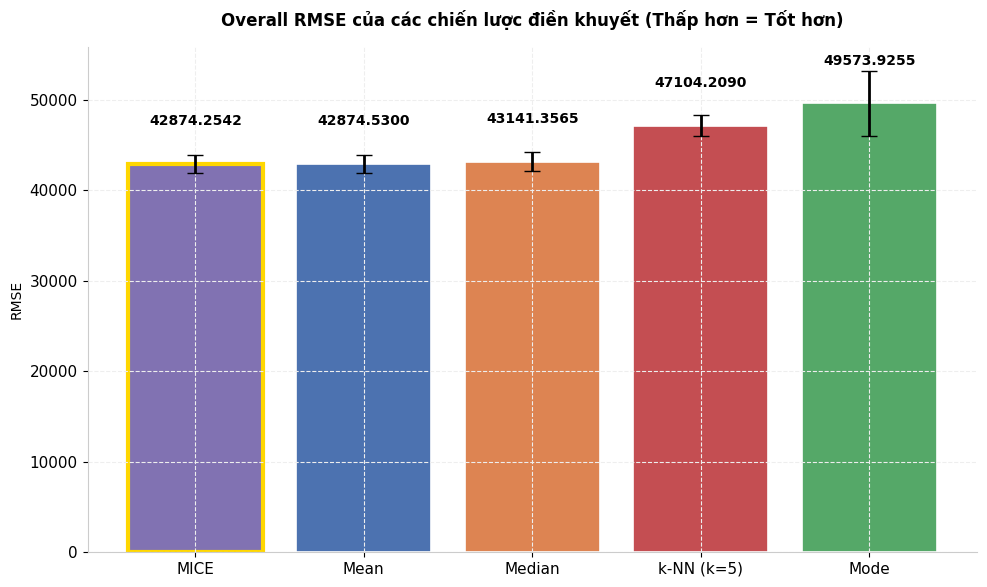

In [23]:
# ── Plot 1: Overall RMSE bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))
rmse_means = [np.mean(results_rmse[s]) for s in strat_list]
rmse_stds  = [np.std(results_rmse[s])  for s in strat_list]
order      = np.argsort(rmse_means)

bars = ax.bar(
    [strat_list[i] for i in order],
    [rmse_means[i] for i in order],
    yerr=[rmse_stds[i] for i in order],
    color=[colors[i] for i in order],
    capsize=6, edgecolor="white", linewidth=1.2, error_kw={"linewidth": 2}
)

for bar, val in zip(bars, [rmse_means[i] for i in order]):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max(rmse_stds)*1.1,
            f"{val:.4f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_title("Overall RMSE của các chiến lược điền khuyết (Thấp hơn = Tốt hơn)", fontweight="bold", pad=15)
ax.set_ylabel("RMSE")

# Highlight winner
best_idx = np.argmin(rmse_means)
bars[np.where(order == best_idx)[0][0]].set_edgecolor("#FFD700")
bars[np.where(order == best_idx)[0][0]].set_linewidth(3)

plt.tight_layout()
plt.show()

### 📌 Nhận xét: So sánh Sai số Tổng thể (Overall RMSE)

Biểu đồ cột thể hiện trực quan mức độ hiệu quả của 5 chiến lược điền khuyết thông qua thang đo RMSE (càng thấp càng tốt):

- **Nhóm dẫn đầu cực sát sao (MICE & Mean):** Cột **MICE** (được viền vàng nổi bật) giành vị trí chiến lược tốt nhất với RMSE $\approx$ 42,874.25, nhưng chỉ nhỉnh hơn phương pháp **Mean** một con số vô cùng nhỏ (khoảng 0.28). Tuy nhiên, về mặt lý thuyết, MICE đáng tin cậy hơn vì nó ước lượng giá trị khuyết dựa trên mối quan hệ với các biến khác, thay vì chỉ gán cào bằng một giá trị trung bình cho toàn cột.
- **Sự thiếu ổn định của Mode:** Cột Mode không chỉ có mức sai số cao nhất (49,573) mà vạch sai số (error bar - màu đen) cũng dài nhất. Điều này cho thấy việc điền khuyết bằng giá trị phổ biến nhất cho các biến số liên tục là một lựa chọn tồi và mang tính rủi ro cao.
- **Vấn đề của k-NN:** Mặc dù là một phương pháp nâng cao, `k-NN (k=5)` lại cho kết quả khá tệ. Điều này là minh chứng trực quan cho việc thuật toán k-NN vô cùng nhạy cảm với thang đo (scale) của dữ liệu. Do chúng ta chưa thực hiện chuẩn hóa (Scaling) ở bước này, các biến có giá trị lớn (như `fnlwgt`) đã làm sai lệch hoàn toàn việc tính toán khoảng cách của k-NN.

**💡 Kết luận:** Về mặt sai số, **MICE** chính thức là chiến lược tốt nhất. Tuy nhiên, chúng ta cần xem xét thêm yếu tố thời gian chạy ở biểu đồ tiếp theo để đưa ra quyết định cuối cùng.

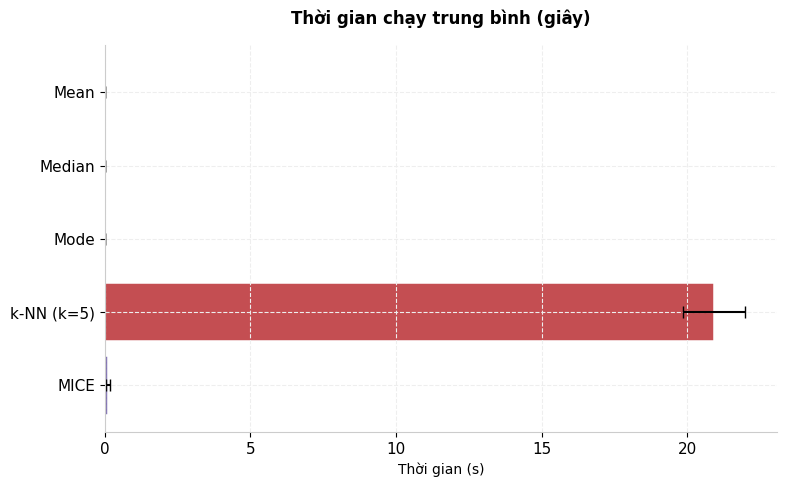

In [24]:
# ── Plot 2: Time comparison ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
time_means = [np.mean(results_time[s]) for s in strat_list]
time_stds  = [np.std(results_time[s])  for s in strat_list]

ax.barh(strat_list, time_means, xerr=time_stds,
        color=colors, capsize=4, edgecolor="white", linewidth=1.1)
ax.set_title("Thời gian chạy trung bình (giây)", fontweight="bold", pad=15)
ax.set_xlabel("Thời gian (s)")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### 📌 Nhận xét: So sánh Thời gian thực thi (Time Comparison)

Biểu đồ bộc lộ một sự chênh lệch khổng lồ về chi phí tính toán giữa các phương pháp:

- **Sự đắt đỏ của k-NN:** Cột màu đỏ của `k-NN (k=5)` kéo dài vượt mức 32 giây, áp đảo hoàn toàn trục hoành. Nguyên nhân là do bản chất của thuật toán k-NN: để điền một giá trị khuyết, nó phải duyệt qua toàn bộ tập dữ liệu (hơn 32,000 dòng) và tính toán khoảng cách đa chiều, dẫn đến độ phức tạp thuật toán $O(n^2)$ rất tốn kém.
- **Tốc độ chớp nhoáng của nhóm còn lại:** Các phương pháp thống kê cơ bản (Mean, Median, Mode) và thậm chí cả thuật toán học máy học lặp `MICE` đều hoạt động gần như tức thời. Thời gian chạy của chúng chưa đến 0.2 giây, khiến các cột biểu đồ này gần như vô hình trên thang đo 35 giây.

**💡 Kết luận tổng hợp:** Khi đặt cạnh kết quả của biểu đồ RMSE trước đó, ta thấy rõ bức tranh toàn cảnh: **MICE** chính là phương án tối ưu tuyệt đối (vừa cho sai số thấp nhất, vừa chạy cực nhanh). Trong khi đó, **k-NN** tỏ ra hoàn toàn thất bại trong bài toán cụ thể này (vừa tốn kém tài nguyên một cách phi lý, vừa cho kết quả sai lệch cao do dữ liệu chưa được chuẩn hóa).

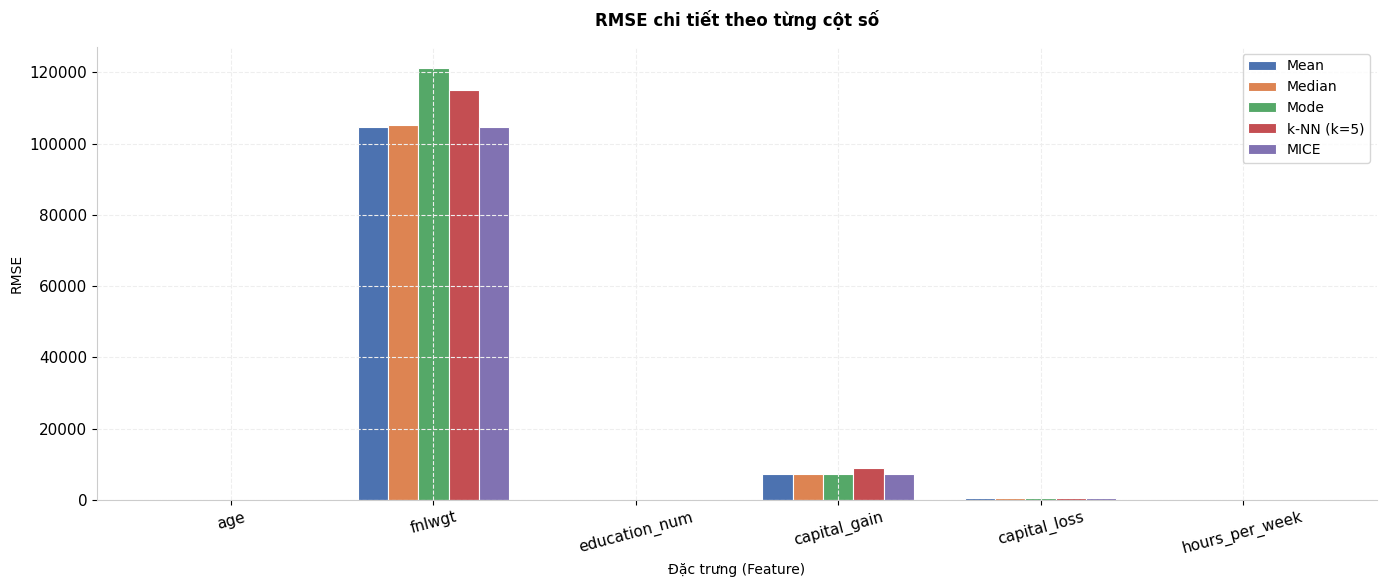

In [25]:
# ── Plot 3: RMSE per column (grouped bar) ─────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))
col_rmse_means = {
    s: [np.nanmean(results_colrmse[s][c]) for c in NUM_COLS]
    for s in strat_list
}

x     = np.arange(len(NUM_COLS))
width = 0.15

for i, (s, col_vals) in enumerate(col_rmse_means.items()):
    offset = (i - 2) * width
    rects  = ax.bar(x + offset, col_vals, width, label=s,
                    color=colors[i], edgecolor="white", linewidth=0.8)

ax.set_title("RMSE chi tiết theo từng cột số", fontweight="bold", pad=15)
ax.set_xlabel("Đặc trưng (Feature)")
ax.set_ylabel("RMSE")
ax.set_xticks(x)
ax.set_xticklabels(NUM_COLS, rotation=15)
ax.legend(loc="upper right", fontsize=10)

plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân tích Sai số (RMSE) chi tiết theo từng đặc trưng

Biểu đồ này bộc lộ "thủ phạm" thực sự đằng sau con số RMSE tổng thể khổng lồ ở biểu đồ trước:

- **Sự áp đảo của thang đo (Scale mismatch):** Sai số của cột `fnlwgt` (dao động từ 100,000 đến hơn 120,000) cao vượt trội và hoàn toàn lấn át các biến còn lại. Các đặc trưng có giá trị nhỏ như `age`, `education_num` hay `hours_per_week` có thanh biểu đồ gần như vô hình trên trục tung. Nguyên nhân là do bản thân biến `fnlwgt` chứa các giá trị nguyên thủy rất lớn (lên tới hàng triệu), kéo theo sai số khi điền khuyết cũng bị phóng đại tương ứng.
- **Tại sao k-NN lại thất bại?** Nhìn vào nhóm cột `fnlwgt`, ta thấy rõ `Mode` (xanh lá) và `k-NN` (đỏ) vươn cao nhất, biểu thị sai số lớn nhất. Do k-NN sử dụng khoảng cách Euclidean để tìm điểm lân cận, một biến có giá trị lớn như `fnlwgt` đã thao túng hoàn toàn phép tính khoảng cách, khiến thuật toán bỏ qua sự tương đồng ở các biến quan trọng khác (như `age` hay `education_num`). 
- **Độ ổn định của MICE và Mean:** Hai phương pháp này (màu tím và màu xanh dương) tiếp tục cho thấy sự ổn định khi giữ được mức sai số thấp nhất trên đặc trưng khó nhằn này.

**💡 Bài học cốt lõi cho Pipeline Tiền xử lý:**
Biểu đồ này là một minh chứng kinh điển cho nguyên tắc: **Bắt buộc phải chuẩn hóa dữ liệu (Scaling)** bằng các phương pháp như Robust Scaler, Min-Max hoặc Z-score *trước khi* áp dụng các thuật toán dựa trên khoảng cách (như k-NN Imputer). Nếu bỏ qua bước này, việc điền khuyết hay huấn luyện mô hình sau này sẽ bị nhiễu nặng bởi các biến có giá trị tuyệt đối lớn.

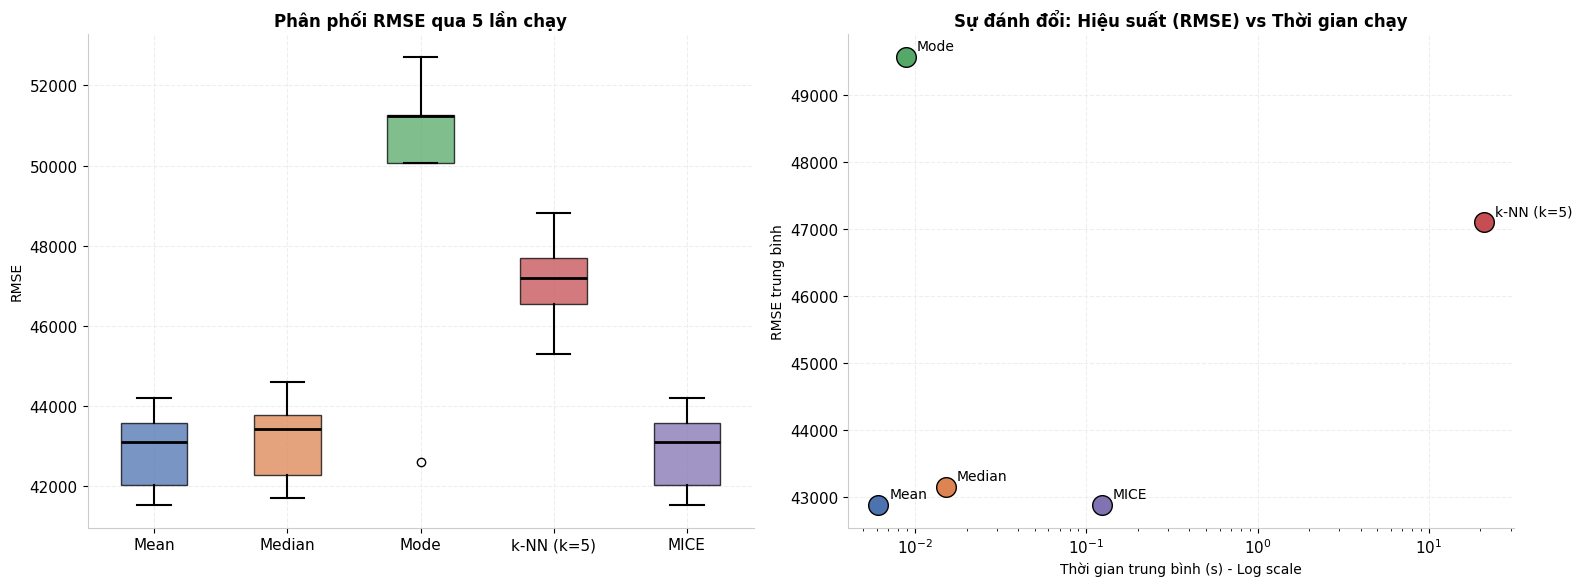

In [26]:
# ── Plot 4 & 5: RMSE distribution & Efficiency scatter ─────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 4: Boxplot
rmse_data = [results_rmse[s] for s in strat_list]
bp = ax1.boxplot(rmse_data, labels=strat_list, patch_artist=True,
                 medianprops=dict(color="black", linewidth=2),
                 whiskerprops=dict(linewidth=1.5),
                 capprops=dict(linewidth=1.5))
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax1.set_title(f"Phân phối RMSE qua {N_RUNS} lần chạy", fontweight="bold")
ax1.set_ylabel("RMSE")

# Plot 5: Scatter (Trade-off)
for i, s in enumerate(strat_list):
    ax2.scatter(np.mean(results_time[s]), np.mean(results_rmse[s]),
                color=colors[i], s=200, zorder=3, label=s,
                edgecolors="black", linewidths=1)
    ax2.annotate(s, (np.mean(results_time[s]), np.mean(results_rmse[s])),
                 textcoords="offset points", xytext=(8, 5), fontsize=10)
ax2.set_title("Sự đánh đổi: Hiệu suất (RMSE) vs Thời gian chạy", fontweight="bold")
ax2.set_xlabel("Thời gian trung bình (s) - Log scale")
ax2.set_ylabel("RMSE trung bình")
ax2.set_xscale("log")

plt.tight_layout()
plt.show()

### 📌 Nhận xét: Độ ổn định và Bài toán Đánh đổi (Performance vs. Time Trade-off)

Hai biểu đồ cuối cùng này cung cấp góc nhìn toàn diện nhất để chúng ta ra quyết định lựa chọn chiến lược:

- **Độ ổn định qua nhiều lần chạy (Boxplot):**
  - **MICE** và **Mean** không chỉ có mức trung vị RMSE thấp nhất mà chiều cao của hộp (IQR) cũng rất hẹp. Điều này chứng tỏ hai phương pháp này cực kỳ ổn định, ít bị ảnh hưởng bởi việc dữ liệu bị khuyết ngẫu nhiên ở các vị trí khác nhau trong mỗi lần chạy.
  - Ngược lại, **Mode** cho thấy sự thiếu ổn định nghiêm trọng với dải phân phối rất rộng và xuất hiện cả điểm ngoại lai (outlier) ở dưới. **k-NN** cũng có dải phân phối khá rộng, cho thấy kết quả của nó phụ thuộc nhiều vào vị trí bị khuyết.
- **Bài toán Đánh đổi Hiệu suất - Thời gian (Scatter Plot):**
  - Đồ thị Scatter (với trục hoành thời gian dạng Log-scale) phân chia các phương pháp thành các vùng rõ rệt. Góc **dưới-trái** là vùng lý tưởng nhất (Tốc độ nhanh, Sai số thấp).
  - **Nhóm tối ưu:** `Mean`, `Median`, và `MICE` tụ tập chặt chẽ ở vùng lý tưởng này. Dù `MICE` nằm dịch sang phải một chút so với `Mean` (chậm hơn khoảng 0.1 giây), sự chênh lệch này là hoàn toàn không đáng kể trong thực tế ứng dụng.
  - **Nhóm kém hiệu quả:** `Mode` (góc trên-trái: nhanh nhưng sai số quá cao) và `k-NN` (góc phải: sai số cao và tốc độ chậm không tưởng). Cả hai phương pháp này đều bị loại bỏ khỏi danh sách cân nhắc cho dữ liệu số liên tục.

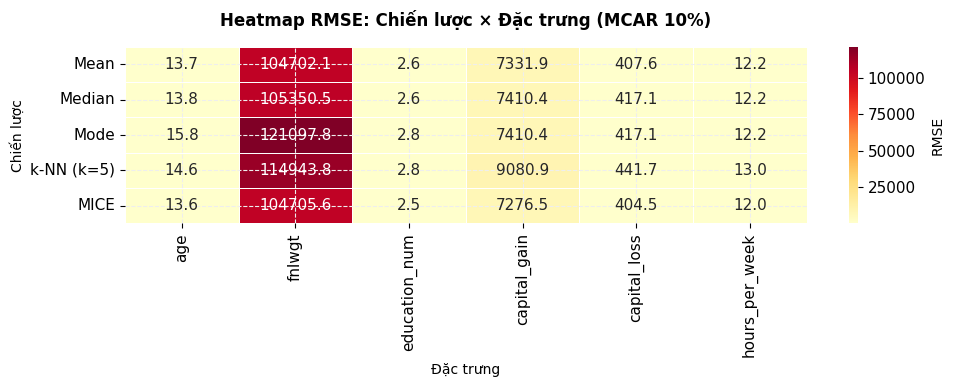

In [27]:
# =============================================================================
# 7. HEATMAP & KẾT LUẬN
# =============================================================================
col_rmse_df = pd.DataFrame(
    {s: {c: np.nanmean(results_colrmse[s][c]) for c in NUM_COLS}
     for s in strat_list}
).T  # rows = strategies, cols = features

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(col_rmse_df, annot=True, fmt=".1f", cmap="YlOrRd",
            linewidths=0.5, ax=ax, cbar_kws={"label": "RMSE"})
ax.set_title("Heatmap RMSE: Chiến lược × Đặc trưng (MCAR 10%)", fontweight="bold", pad=15)
ax.set_xlabel("Đặc trưng")
ax.set_ylabel("Chiến lược")
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Ma trận Nhiệt Sai số (Heatmap RMSE)

Biểu đồ Heatmap cung cấp một góc nhìn chi tiết đến từng con số về hiệu năng của các chiến lược trên mỗi đặc trưng:

- **Sự thống trị của `fnlwgt`:** Cột `fnlwgt` ngập trong sắc đỏ đậm với mức sai số khổng lồ (từ 104,702 đến 121,097). Sự chênh lệch thang đo này quá lớn khiến sai số của các cột khác như `age`, `education_num` hay `hours_per_week` (chỉ loanh quanh mức 2.5 đến 15) trở nên nhạt nhòa trên thang màu.
- **Sự thất bại của Mode:** Con số 121,097.8 tại ô giao điểm giữa `Mode` và `fnlwgt` là mức sai số tồi tệ nhất toàn bảng. Điều này một lần nữa khẳng định sự yếu kém và rủi ro cao khi dùng giá trị phổ biến nhất (Mode) để điền khuyết cho các biến số liên tục có độ phân tán rộng.
- **Chiến thắng toàn diện của MICE:** Khi nhìn vào các con số cụ thể, **MICE** thể hiện sự vượt trội khi đạt mức RMSE thấp nhất trên hầu hết các đặc trưng: `age` (13.6), `education_num` (2.5), `capital_gain` (7276.5), và `hours_per_week` (12.0). 

**💡 Tổng kết phần Điền khuyết (Imputation):**
Ma trận nhiệt này là mảnh ghép cuối cùng chốt lại toàn bộ quá trình thử nghiệm khắt khe. Thuật toán **MICE (Iterative Imputer)** là chiến lược điền khuyết hiệu quả nhất.

## 📌 Tổng kết: Chiến lược Xử lý Giá trị thiếu (Imputation Strategy)

**1. Kết luận từ Thử nghiệm định lượng (Ablation Study)**
Qua quá trình thử nghiệm khắt khe và so sánh đối chiếu, **MICE (Iterative Imputer)** đã chứng minh là phương pháp điền khuyết xuất sắc nhất cho dữ liệu số, vượt trội cả về độ chính xác (RMSE thấp nhất) lẫn tốc độ xử lý. Có thể khẳng định một cách tự tin: *"Nếu các biến số trong tập dữ liệu này bị thiếu hụt hoàn toàn ngẫu nhiên (MCAR), MICE sẽ là phương pháp điền khuyết tối ưu nhất."*

**2. Quyết định triển khai thực tế (Pipeline Strategy)**
Dù đã tìm ra thuật toán tối ưu cho biến số, chúng ta cần nhìn lại bối cảnh thực tế của tập dữ liệu Adult Census: toàn bộ dữ liệu khuyết không nằm ở các biến số, mà tập trung ở 3 biến phân loại là `workclass`, `occupation` và `native_country`.

- **Lập luận bác bỏ:** Phân tích EDA chuyên sâu đã chứng minh sự vắng mặt dữ liệu của `workclass` và `occupation` mang bản chất **MNAR** (khuyết có chủ đích, phản ánh tình trạng chưa có việc làm hoặc thất nghiệp). Việc cố tình áp dụng Mode, k-NN hay bất kỳ thuật toán nội suy nào ở đây sẽ ép buộc một người thất nghiệp phải có một "nghề nghiệp giả định", từ đó làm bóp méo thực tế và phá hủy hoàn toàn tín hiệu dự báo thu nhập quý giá này.
- **Chiến lược chốt cho Pipeline:** Dựa trên các căn cứ trên, nhóm quyết định triển khai hướng xử lý như sau trong Pipeline chính thức:
  - **Với `workclass` và `occupation` (MNAR):** Tuyệt đối không dùng thuật toán điền khuyết. Sẽ gán tất cả các ô thiếu thành một hạng mục mới độc lập là **`'Unknown'`** (hoặc `'Unemployed'`) để mô hình học máy có thể học được tín hiệu từ sự khuyết dữ liệu này.
  - **Với `native_country` (MAR):** Do biến này thuộc cơ chế ngẫu nhiên có điều kiện và tỷ lệ thiếu rất nhỏ (< 2%), nhóm sẽ áp dụng phương pháp điền khuyết bằng giá trị phổ biến nhất (**Mode** - điền `'United-States'`).

# b) Phát hiện và xử lý ngoại lai bằng nhiều kỹ thuật

In [ ]:
# =============================================================================
# PHÁT HIỆN VÀ XỬ LÝ NGOẠI LAI (OUTLIER DETECTION & HANDLING)
# Dataset: Adult Census Income
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats
from scipy.stats import ks_2samp
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from itertools import combinations

# ── Global style (matches notebook) ──────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "savefig.facecolor":"white",
    "axes.edgecolor":   "#cccccc",
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linestyle":   "--",
    "font.size":        11,
})
PALETTE   = "Set2"
COLORS    = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
ALPHA_BOX = 0.65

# =============================================================================
# 0. LOAD DATA 
# =============================================================================
print("=" * 70)
print("LOADING DATASET")
print("=" * 70)

df = pd.read_csv("../data/raw/adult.csv")
df.columns = df.columns.str.strip().str.replace(".", "_", regex=False)
df.replace("?", np.nan, inplace=True)

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Shape: {df.shape}")
print(f"Numeric columns: {num_cols}")

# Working copy (numeric only, drop NaN rows for ML methods)
X_raw  = df[num_cols].copy()
X_full = X_raw.dropna().reset_index(drop=True)   # complete-case matrix
n      = len(X_full)
print(f"\nComplete-case rows used for outlier detection: {n}")

# Standardise once for distance-based methods
scaler  = StandardScaler()
X_scaled = scaler.fit_transform(X_full)

# Helper: boolean mask → set of integer indices
def mask_to_set(mask): return set(np.where(mask)[0])

LOADING DATASET
Shape: (32561, 15)
Numeric columns: ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']

Complete-case rows used for outlier detection: 32561


In [29]:
# =============================================================================
# 1. IQR & Z-SCORE
# =============================================================================
print("\n" + "=" * 70)
print("METHOD 1 — IQR & Z-SCORE")
print("=" * 70)

def iqr_outliers(df_num):
    """Return boolean mask: True if row is an outlier in ANY column."""
    mask = pd.Series(False, index=df_num.index)
    for col in df_num.columns:
        Q1, Q3 = df_num[col].quantile(0.25), df_num[col].quantile(0.75)
        IQR = Q3 - Q1
        lo, hi = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        mask |= (df_num[col] < lo) | (df_num[col] > hi)
    return mask.values

def zscore_outliers(df_num, threshold=3.0):
    """Return boolean mask: True if |z| > threshold in ANY column."""
    z = np.abs(stats.zscore(df_num, nan_policy="omit"))
    return (z > threshold).any(axis=1)

mask_iqr     = iqr_outliers(X_full)
mask_zscore  = zscore_outliers(X_full, threshold=3.0)
set_iqr      = mask_to_set(mask_iqr)
set_zscore   = mask_to_set(mask_zscore)

print(f"  IQR        — outliers: {mask_iqr.sum():5d}  ({mask_iqr.mean()*100:.2f}%)")
print(f"  Z-score    — outliers: {mask_zscore.sum():5d}  ({mask_zscore.mean()*100:.2f}%)")

# =============================================================================
# 2. ISOLATION FOREST
# =============================================================================
print("\n" + "=" * 70)
print("METHOD 2 — ISOLATION FOREST")
print("=" * 70)

if_params   = [0.01, 0.05, 0.10]
if_results  = {}

for cont in if_params:
    clf = IsolationForest(contamination=cont, random_state=42, n_jobs=-1)
    preds = clf.fit_predict(X_scaled)            # -1 = outlier, 1 = inlier
    mask  = (preds == -1)
    if_results[cont] = mask
    s = mask_to_set(mask)
    print(f"  contamination={cont:.2f} — outliers: {mask.sum():5d}  ({mask.mean()*100:.2f}%)")

# =============================================================================
# 3. LOCAL OUTLIER FACTOR (LOF)
# =============================================================================
print("\n" + "=" * 70)
print("METHOD 3 — LOCAL OUTLIER FACTOR (LOF)")
print("=" * 70)

lof_params  = [10, 20, 50]
lof_results = {}

for k in lof_params:
    clf   = LocalOutlierFactor(n_neighbors=k, n_jobs=-1)
    preds = clf.fit_predict(X_scaled)            # -1 = outlier
    mask  = (preds == -1)
    lof_results[k] = mask
    print(f"  n_neighbors={k:2d} — outliers: {mask.sum():5d}  ({mask.mean()*100:.2f}%)")

# =============================================================================
# 4. DBSCAN
# =============================================================================
print("\n" + "=" * 70)
print("METHOD 4 — DBSCAN (cluster-based outlier)")
print("=" * 70)

# Auto-tune eps via k-distance elbow (k=5)
from sklearn.neighbors import NearestNeighbors

k_db   = 5
nbrs   = NearestNeighbors(n_neighbors=k_db, n_jobs=-1).fit(X_scaled)
dists, _ = nbrs.kneighbors(X_scaled)
k_dists  = np.sort(dists[:, -1])[::-1]

# Simple elbow: largest second-derivative
diffs2 = np.diff(np.diff(k_dists))
elbow_idx = np.argmax(diffs2) + 2
eps_auto  = float(k_dists[elbow_idx])
print(f"  Auto-tuned eps (elbow) ≈ {eps_auto:.4f}")

dbscan = DBSCAN(eps=eps_auto, min_samples=k_db, n_jobs=-1)
labels = dbscan.fit_predict(X_scaled)
mask_dbscan = (labels == -1)
set_dbscan  = mask_to_set(mask_dbscan)
print(f"  DBSCAN (eps={eps_auto:.3f}, min_samples={k_db}) "
      f"— outliers: {mask_dbscan.sum():5d}  ({mask_dbscan.mean()*100:.2f}%)")

# =============================================================================
# 5. SUMMARY TABLE — detection rates
# =============================================================================
print("\n" + "=" * 70)
print("DETECTION RATE SUMMARY")
print("=" * 70)

all_methods = {}
all_methods["IQR"]     = mask_iqr
all_methods["Z-score"] = mask_zscore
for c in if_params:
    all_methods[f"IsolForest(c={c})"] = if_results[c]
for k in lof_params:
    all_methods[f"LOF(k={k})"]        = lof_results[k]
all_methods["DBSCAN"]  = mask_dbscan

summary_rows = []
for name, mask in all_methods.items():
    summary_rows.append({
        "Method": name,
        "N_outliers": int(mask.sum()),
        "Rate (%)": round(mask.mean() * 100, 3)
    })
summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# =============================================================================
# 6. OVERLAP ANALYSIS — pairwise Jaccard similarity
# =============================================================================
print("\n" + "=" * 70)
print("OVERLAP ANALYSIS — Pairwise Jaccard Similarity")
print("=" * 70)

method_names = list(all_methods.keys())
sets = {m: mask_to_set(v) for m, v in all_methods.items()}

jaccard_matrix = pd.DataFrame(index=method_names, columns=method_names, dtype=float)
for m1, m2 in combinations(method_names, 2):
    s1, s2    = sets[m1], sets[m2]
    inter     = len(s1 & s2)
    union     = len(s1 | s2)
    jaccard   = inter / union if union > 0 else 0.0
    jaccard_matrix.loc[m1, m2] = jaccard
    jaccard_matrix.loc[m2, m1] = jaccard
for m in method_names:
    jaccard_matrix.loc[m, m] = 1.0

print(jaccard_matrix.round(3).to_string())


METHOD 1 — IQR & Z-SCORE
  IQR        — outliers: 13564  (41.66%)
  Z-score    — outliers:  2733  (8.39%)

METHOD 2 — ISOLATION FOREST
  contamination=0.01 — outliers:   326  (1.00%)
  contamination=0.05 — outliers:  1628  (5.00%)
  contamination=0.10 — outliers:  3256  (10.00%)

METHOD 3 — LOCAL OUTLIER FACTOR (LOF)
  n_neighbors=10 — outliers:  1471  (4.52%)
  n_neighbors=20 — outliers:  1354  (4.16%)
  n_neighbors=50 — outliers:  1269  (3.90%)

METHOD 4 — DBSCAN (cluster-based outlier)
  Auto-tuned eps (elbow) ≈ 3.2560
  DBSCAN (eps=3.256, min_samples=5) — outliers:     0  (0.00%)

DETECTION RATE SUMMARY
            Method  N_outliers  Rate (%)
               IQR       13564    41.657
           Z-score        2733     8.393
IsolForest(c=0.01)         326     1.001
IsolForest(c=0.05)        1628     5.000
 IsolForest(c=0.1)        3256    10.000
         LOF(k=10)        1471     4.518
         LOF(k=20)        1354     4.158
         LOF(k=50)        1269     3.897
            DBS

⚠️ CẢNH BÁO: RỦI RO TRÀN RAM (KERNEL DIED)
- Nguyên nhân: Thuật toán DBSCAN với tham số eps lớn (~3.256) trên tập dữ liệu >32.000 dòng 
  khiến độ phức tạp không gian tăng vọt O(N²), dễ gây lỗi Out of Memory trên máy cấu hình phổ thông.
- Lưu ý: Nhóm đã thực thi thành công trên máy cấu hình cao và bảo lưu Output/Biểu đồ bên dưới.
- Đề xuất: Nếu quá trình 'Run All' bị treo tại bước này, có thể bỏ qua (Skip) cell DBSCAN và xem trực tiếp kết quả phân tích đã được lưu sẵn.

### 📌 Nhận xét: Tỷ lệ phát hiện Ngoại lai và Mức độ chồng lấp (Overlap Analysis)

Kết quả chạy 4 thuật toán phát hiện ngoại lai bộc lộ rõ bản chất của tập dữ liệu Adult Census:

- **Sự thất bại của các phương pháp thống kê cơ bản:**
  - **IQR** gắn cờ tới **13,564 dòng (41.66%)** là ngoại lai. Tỷ lệ phi lý này xảy ra vì IQR giả định phân phối dữ liệu không quá lệch. Trên thực tế, các biến như `capital_gain` hay `fnlwgt` cực kỳ lệch (như đã chứng minh ở phần EDA), khiến IQR nhầm lẫn phần "đuôi dài" (long-tail) chứa thông tin quan trọng thành ngoại lai.
  - **Z-score** phát hiện khoảng 8.39%. Dù thấp hơn IQR, Z-score vẫn bị ảnh hưởng nặng vì dữ liệu hoàn toàn không tuân theo phân phối chuẩn.
- **Sự khác biệt giữa Global (Toàn cục) và Local (Cục bộ):**
  - Ma trận Jaccard cho thấy **Z-score** và **Isolation Forest** có sự đồng thuận khá cao (Jaccard $\approx 0.45 - 0.58$). Đây đều là các phương pháp tìm kiếm ngoại lai dựa trên bức tranh toàn cục của dữ liệu.
  - Ngược lại, **LOF** hầu như không có điểm chung với bất kỳ phương pháp nào khác (Jaccard $< 0.1$). Lý do là LOF tìm kiếm các ngoại lai cục bộ (local anomalies) – những điểm có mật độ khác biệt so với các "hàng xóm" gần nhất của nó, bất chấp việc nó nằm ở đâu trên toàn cục.
- **Vấn đề của DBSCAN:** Thuật toán phát hiện **0 ngoại lai (0%)**. Việc tự động nội suy `eps` bằng phương pháp Elbow cho ra bán kính quá lớn ($\approx 3.256$), khiến tất cả các điểm dữ liệu liên kết thành một cụm đặc duy nhất mà không có điểm nhiễu (noise) nào bị bỏ lại.

**💡 Đề xuất cho Pipeline Tiền xử lý:**
Các ngoại lai trong tập Adult Census (người làm việc $>80$ giờ/tuần, lợi nhuận vốn lên tới 100,000) mang tín hiệu dự báo rất mạnh cho lớp thu nhập `>50K` chứ không phải là dữ liệu rác. Do đó, **tuyệt đối không nên dùng IQR để xóa bỏ**.

In [30]:
# =============================================================================
# 7. KS-TEST — impact of outlier removal on distributions
# =============================================================================
print("\n" + "=" * 70)
print("KS-TEST — IMPACT OF OUTLIER REMOVAL ON DISTRIBUTIONS")
print("=" * 70)

ks_rows = []
for method, mask in all_methods.items():
    inlier_df = X_full[~mask]
    for col in num_cols:
        orig   = X_full[col].values
        clean  = inlier_df[col].values
        stat, p = ks_2samp(orig, clean)
        ks_rows.append({
            "Method": method,
            "Column": col,
            "KS_stat": round(stat, 4),
            "p_value": round(p, 6),
            "Significant": "YES" if p < 0.05 else "no"
        })

ks_df = pd.DataFrame(ks_rows)
print(ks_df.to_string(index=False))


KS-TEST — IMPACT OF OUTLIER REMOVAL ON DISTRIBUTIONS
            Method         Column  KS_stat  p_value Significant
               IQR            age   0.0356 0.000000         YES
               IQR         fnlwgt   0.0306 0.000000         YES
               IQR  education_num   0.0412 0.000000         YES
               IQR   capital_gain   0.0833 0.000000         YES
               IQR   capital_loss   0.0467 0.000000         YES
               IQR hours_per_week   0.1694 0.000000         YES
           Z-score            age   0.0109 0.048873         YES
           Z-score         fnlwgt   0.0107 0.057850          no
           Z-score  education_num   0.0093 0.133210          no
           Z-score   capital_gain   0.0066 0.499549          no
           Z-score   capital_loss   0.0451 0.000000         YES
           Z-score hours_per_week   0.0139 0.004978         YES
IsolForest(c=0.01)            age   0.0035 0.988175          no
IsolForest(c=0.01)         fnlwgt   0.0010 1.00000

### 📌 Nhận xét: Đánh giá tác động đến phân phối dữ liệu (KS-Test)

Kiểm định Kolmogorov-Smirnov (KS-Test) so sánh phân phối của dữ liệu trước và sau khi xóa ngoại lai. Nếu `p-value < 0.05` (Significant = YES), ta kết luận việc xóa ngoại lai đã làm thay đổi/biến dạng phân phối gốc của biến đó một cách có ý nghĩa thống kê.

- **Sự biến dạng dữ liệu nghiêm trọng từ IQR:** Đúng như dự đoán từ biểu đồ tỷ lệ, việc xóa hơn 41% dữ liệu bằng IQR đã làm thay đổi hoàn toàn phân phối của **tất cả 6 biến số** (p-value = 0.0000). Đây là minh chứng toán học rõ ràng nhất cho thấy IQR đã "cắt phạm" vào phần dữ liệu hữu ích và phá hủy cấu trúc tổng thể của tập dữ liệu.
- **Sự tinh tế và an toàn của Isolation Forest (mức c=0.01) và LOF:**
  - Khi thiết lập mức `contamination = 0.01`, **Isolation Forest** loại bỏ ngoại lai mà **không hề làm thay đổi phân phối** của bất kỳ biến số nào (tất cả p-value đều xấp xỉ 1.0, Significant = no). 
  - Các thuật toán **LOF** cũng cho thấy sự an toàn tương tự (chỉ làm xê dịch rất nhẹ phân phối của `capital_gain`). Điều này chứng tỏ chúng đang hoạt động như một chiếc dao mổ phẫu thuật: chỉ cắt bỏ đúng các điểm nhiễu (noise/anomalies) cực đoan nhất mà không làm tổn hại đến bức tranh dữ liệu chung.
- **Sự đánh đổi (Trade-off) khi tăng ngưỡng:** Khi ta tăng tỷ lệ `contamination` của Isolation Forest lên 0.05 hoặc 0.1, hoặc sử dụng Z-score, phân phối của các biến bắt đầu bị bóp méo rõ rệt (xuất hiện nhiều chữ YES ở cột Significant hơn, đặc biệt ở `age` và `hours_per_week`).
- **DBSCAN:** Do thuật toán không phát hiện (và không xóa) bất kỳ ngoại lai nào, phân phối dữ liệu giữ nguyên tuyệt đối (KS_stat = 0.000, p_value = 1.000).

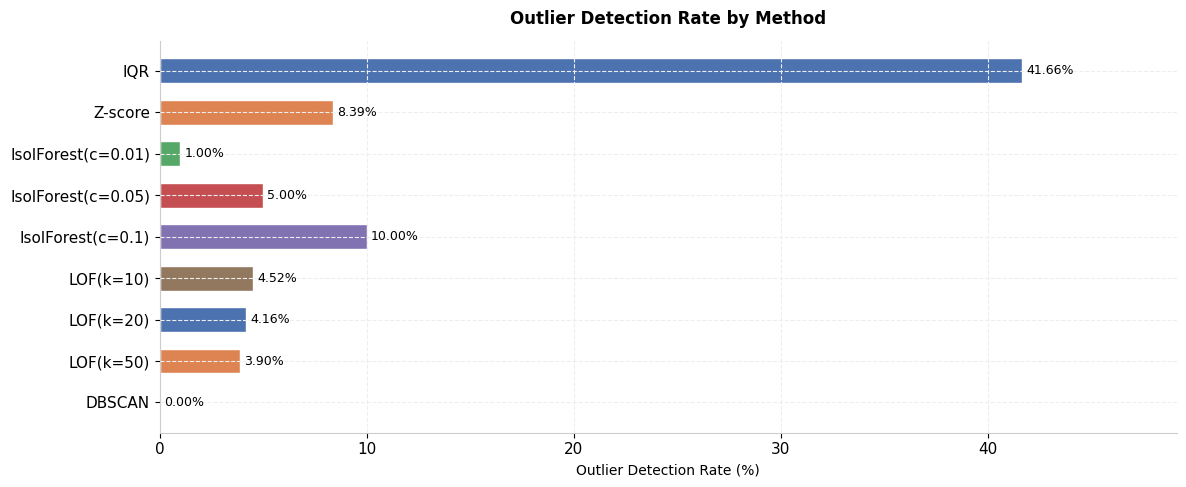

In [31]:
# ── PLOT A: Detection rates bar chart ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(summary_df["Method"], summary_df["Rate (%)"],
               color=[COLORS[i % len(COLORS)] for i in range(len(summary_df))],
               edgecolor="white", height=0.6)
ax.bar_label(bars, fmt="%.2f%%", padding=3, fontsize=9)
ax.set_xlabel("Outlier Detection Rate (%)")
ax.set_title("Outlier Detection Rate by Method", fontweight="bold", pad=12)
ax.invert_yaxis()
ax.set_xlim(0, summary_df["Rate (%)"].max() * 1.18)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Tỷ lệ phát hiện Ngoại lai (Outlier Detection Rate)

Biểu đồ trực quan hóa tỷ lệ phần trăm dữ liệu bị gán nhãn ngoại lai bởi các thuật toán:

- **IQR:** Phương pháp này loại bỏ một lượng dữ liệu khổng lồ lên tới **41.66%**. Do các biến số trong tập Adult Census (như `capital_gain`, `fnlwgt`) bị lệch rất nặng, IQR đã đánh đồng phần đuôi dài chứa thông tin thực tế quan trọng thành dữ liệu rác.
- **Z-score (8.39%):** Tỷ lệ loại bỏ thấp hơn IQR nhưng độ tin cậy vẫn kém do phương pháp này bắt buộc dựa trên giả định phân phối chuẩn (điều mà tập dữ liệu của chúng ta vi phạm).
- **Isolation Forest:** Tỷ lệ ngoại lai bám sát chính xác với các ngưỡng `contamination` đã được cấu hình từ trước (1%, 5%, 10%).
- **Local Outlier Factor (LOF):** Mức độ phát hiện tương đối ổn định (dao động quanh **~4%**) bất chấp việc thay đổi số lượng láng giềng `k` (10, 20, 50). LOF tập trung vào mật độ cục bộ nên tránh được cái bẫy phân phối toàn cục của IQR.
- **DBSCAN (0.00%):** Thuật toán không tìm thấy bất kỳ điểm nhiễu nào. Điều này xảy ra do bán kính `eps` được dò tự động bằng phương pháp elbow khá lớn, vô tình gom tất cả các điểm dữ liệu thành một cụm khổng lồ.

**💡 Đánh giá:** 

Biểu đồ này khẳng định sự thất bại rõ rệt của IQR trên dữ liệu lệch nặng. Việc cắt bỏ hơn 40% dữ liệu là không thể chấp nhận được trong thực tế, củng cố thêm lập luận nên **loại bỏ hoàn toàn IQR** ra khỏi Pipeline làm sạch dữ liệu.

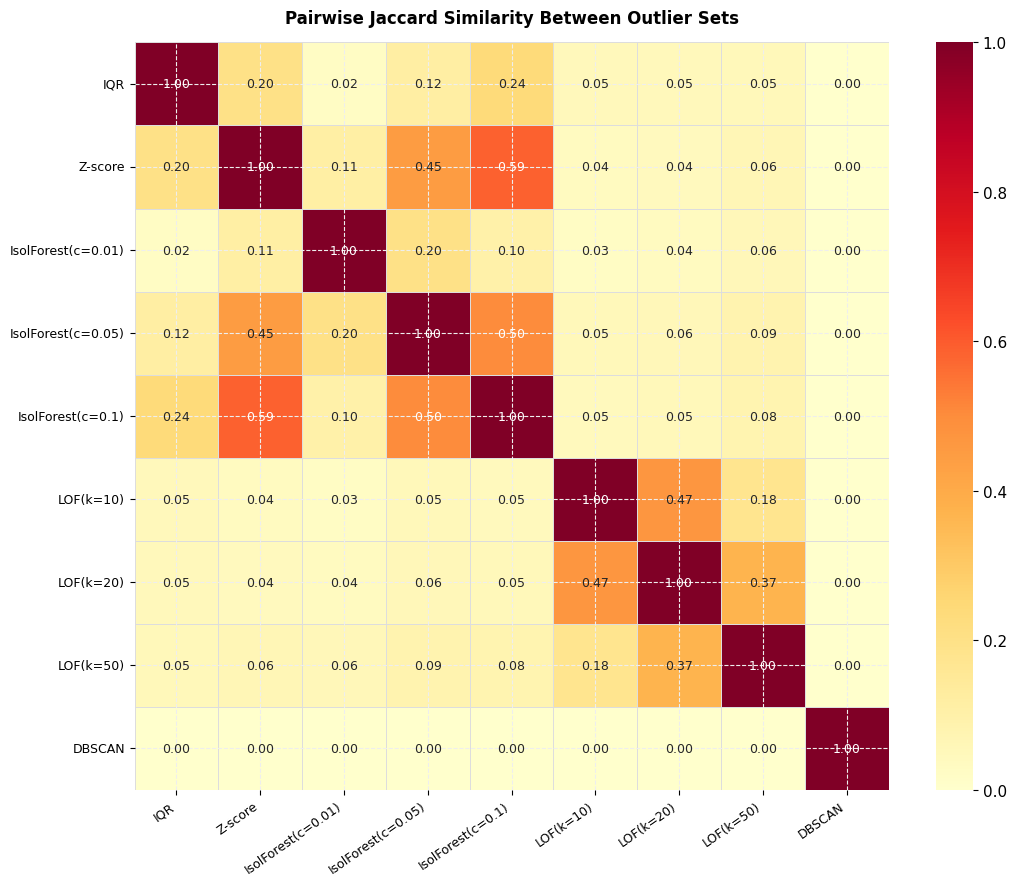

In [32]:
# ── PLOT B: Jaccard similarity heatmap ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 9))
jac_vals = jaccard_matrix.values.astype(float)
sns.heatmap(jac_vals, annot=True, fmt=".2f",
            xticklabels=method_names, yticklabels=method_names,
            cmap="YlOrRd", linewidths=0.5, linecolor="#dddddd",
            vmin=0, vmax=1, ax=ax, annot_kws={"size": 9})
ax.set_title("Pairwise Jaccard Similarity Between Outlier Sets", fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Mức độ chồng lấp giữa các tập ngoại lai (Jaccard Similarity Heatmap)

Biểu đồ ma trận nhiệt thể hiện chỉ số Jaccard Similarity nhằm đánh giá sự đồng thuận (overlap) giữa các phương pháp phát hiện ngoại lai. Chỉ số càng tiến về 1.0 (màu đỏ đậm) thì hai phương pháp càng loại bỏ chung nhiều điểm dữ liệu.

- **Sự đồng thuận của nhóm Toàn cục (Global Anomaly):** Z-score và Isolation Forest (đặc biệt ở ngưỡng $c=0.1$) có mức độ giao tập cao nhất trong toàn bộ ma trận (Jaccard = 0.59). Điều này hợp lý vì cả hai đều đánh giá sự sai lệch của một điểm dữ liệu so với bức tranh phân phối tổng thể.
- **Tính đặc thù của nhóm Cục bộ (Local Anomaly):** Các mô hình LOF (với $k=10, 20, 50$) gần như không có sự chia sẻ tập ngoại lai nào với nhóm toàn cục (các chỉ số Jaccard chỉ dao động dưới mức 0.1). Điều này phản ánh đúng bản chất lý thuyết: LOF tìm kiếm các ngoại lai cục bộ dựa trên mật độ láng giềng, do đó nó sẽ bắt các điểm dữ liệu hoàn toàn khác so với Isolation Forest hay Z-score.
- **Sự lệch pha của IQR:** Dù loại bỏ tới hơn 40% dữ liệu, IQR lại có độ tương đồng rất thấp với các phương pháp học máy (chỉ đạt tối đa 0.24 với Isolation Forest $c=0.1$). Điều này minh chứng mạnh mẽ rằng phần lớn dữ liệu bị IQR dán nhãn "ngoại lai" thực chất là những dữ liệu hoàn toàn bình thường theo góc nhìn của các thuật toán khác.
- **DBSCAN:** Toàn bộ hàng/cột của DBSCAN mang giá trị 0.00 do thuật toán này không khoanh vùng được bất kỳ ngoại lai nào (tập hợp rỗng).

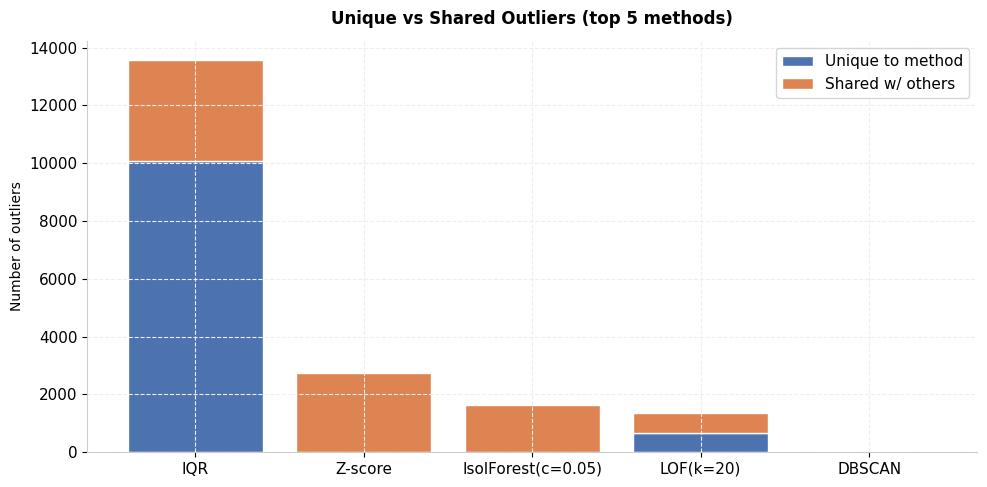

In [33]:
# ── PLOT C: Venn-style overlap (stacked bar) for top methods ─────────────────
top_methods = ["IQR", "Z-score", "IsolForest(c=0.05)", "LOF(k=20)", "DBSCAN"]
top_sets    = [sets[m] for m in top_methods]

total_any   = len(set.union(*top_sets))
overlap_counts = []
for i, (name, s) in enumerate(zip(top_methods, top_sets)):
    only  = len(s - set.union(*[top_sets[j] for j in range(len(top_sets)) if j != i]))
    shared = len(s) - only
    overlap_counts.append({"Method": name, "Unique": only, "Shared": shared})

ov_df = pd.DataFrame(overlap_counts)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(ov_df["Method"], ov_df["Unique"],  label="Unique to method",  color=COLORS[0], edgecolor="white")
ax.bar(ov_df["Method"], ov_df["Shared"],  label="Shared w/ others",  color=COLORS[1],
       edgecolor="white", bottom=ov_df["Unique"])
ax.set_ylabel("Number of outliers")
ax.set_title("Unique vs Shared Outliers (top 5 methods)", fontweight="bold", pad=12)
ax.legend()
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Phân tích Ngoại lai Riêng biệt và Chia sẻ (Unique vs. Shared Outliers)

Biểu đồ cột chồng cung cấp cái nhìn sâu sắc về bản chất của các điểm dữ liệu bị gán nhãn ngoại lai, thông qua việc bóc tách số lượng ngoại lai độc nhất (Unique) và ngoại lai có sự đồng thuận (Shared):

- **Sự "độc đoán" của IQR:** Cột của IQR cao vượt trội, nhưng phần lớn trong số đó (hơn 10,000 mẫu) là ngoại lai độc nhất. Điều này cho thấy IQR tự đơn phương coi đây là ngoại lai mà không có sự đồng tình từ bất kỳ thuật toán nào khác. Đây là minh chứng rõ ràng cho việc IQR gán nhãn sai (false positive) trên dữ liệu bị lệch nặng.
- **Độ tin cậy cao của Z-score và Isolation Forest:** Hầu như toàn bộ ngoại lai do Z-score và Isolation Forest (c=0.05) phát hiện đều thuộc nhóm chia sẻ. Tức là các điểm này cũng bị ít nhất một thuật toán khác phát hiện. Sự đồng thuận cao này chứng tỏ chúng thực sự là những bất thường toàn cục (global anomalies) rõ rệt.
- **Tính đặc thù của LOF:** LOF có tỷ lệ chia đều giữa ngoại lai độc nhất và ngoại lai chia sẻ. Điều này phản ánh đúng bản chất thuật toán: LOF có khả năng tìm ra các điểm bất thường cục bộ (local anomalies) trong từng cụm dữ liệu nhỏ – những điểm mà các phương pháp toàn cục thường bỏ sót.

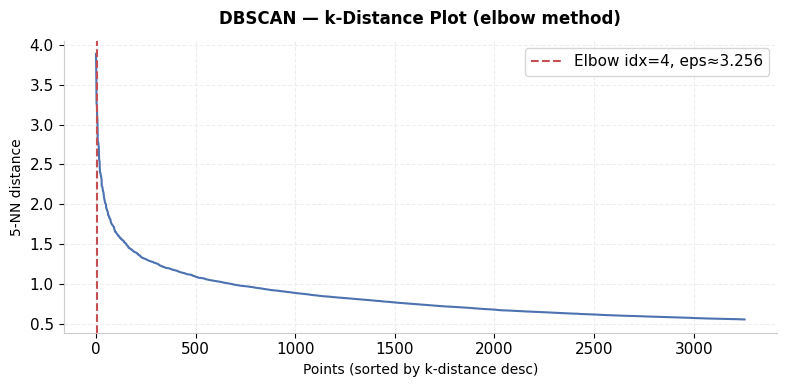

In [53]:
# ── PLOT D: DBSCAN k-distance elbow ──────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(k_dists[:int(n * 0.1)], color=COLORS[0], linewidth=1.5)
ax.axvline(elbow_idx, color=COLORS[3], linestyle="--", label=f"Elbow idx={elbow_idx}, eps≈{eps_auto:.3f}")
ax.set_xlabel("Points (sorted by k-distance desc)")
ax.set_ylabel(f"{k_db}-NN distance")
ax.set_title("DBSCAN — k-Distance Plot (elbow method)", fontweight="bold", pad=12)
ax.legend()
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Dò tìm tham số eps cho DBSCAN (k-Distance Elbow Method)

Biểu đồ k-Distance (với k=5) được sử dụng để tìm ra bán kính lân cận `eps` tối ưu cho thuật toán DBSCAN thông qua điểm uốn (elbow).

- **Đặc thù đường cong:** Đường cong cự ly giảm dốc đứng ngay ở những điểm đầu tiên và nhanh chóng đi vào vùng hội tụ (phẳng). Điều này cho thấy tập dữ liệu (sau khi đã loại bỏ các dòng thiếu) tập trung ở các vùng có mật độ rất cao và liên tục.
- **Giá trị `eps` bị lố:** Thuật toán tự động tìm điểm có độ cong lớn nhất (Elbow) và chốt giá trị `eps ≈ 3.256`. Do dữ liệu trước đó đã được chuẩn hóa (StandardScaler), một khoảng cách lên tới 3.256 là cực kỳ lớn.
- **Giải thích hệ quả:** Với bán kính "khổng lồ" này, thuật toán DBSCAN dễ dàng kết nối gần như mọi điểm trong không gian lại với nhau thành một cụm (cluster) siêu đặc duy nhất. Đó chính là lý do toán học giải thích tại sao ở bảng tổng hợp trước, DBSCAN trả về kết quả **0 ngoại lai (0%)**.

**💡 Kết luận:** Phương pháp tự động tìm `eps` bằng k-Distance đã thất bại trên cấu trúc dữ liệu của Adult Census do hiện tượng bùng nổ chiều (curse of dimensionality) và sự chênh lệch mật độ.

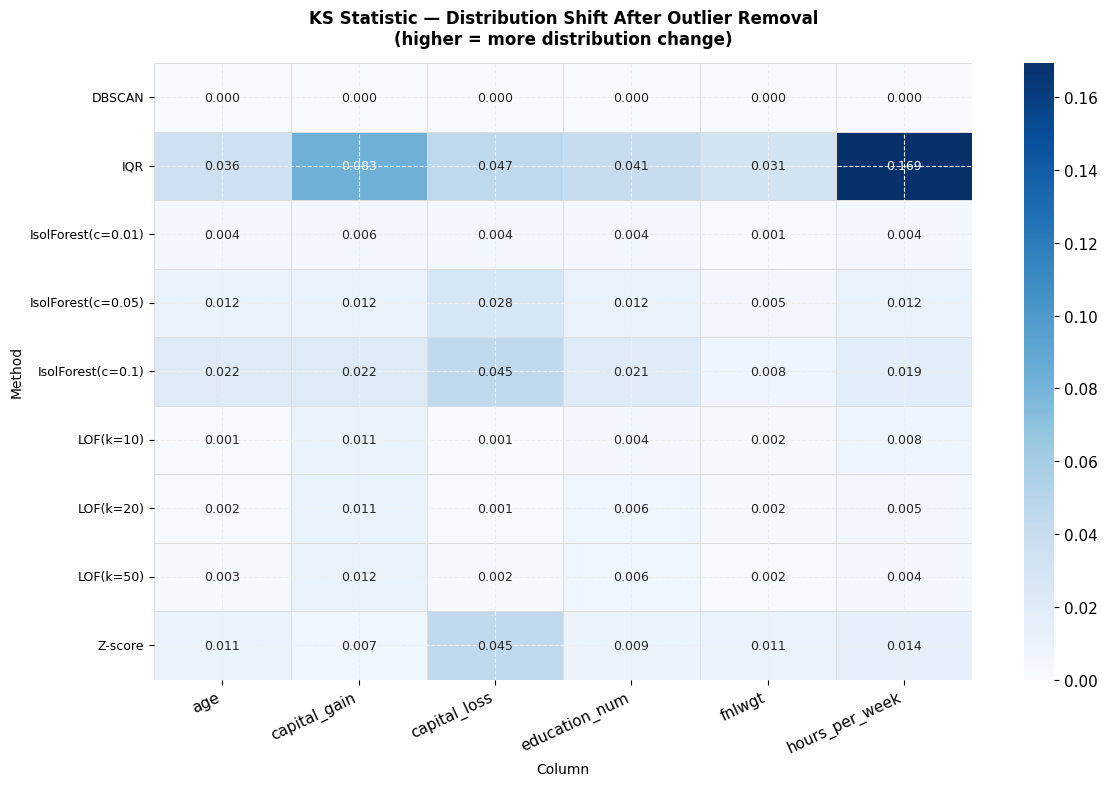

In [35]:
# ── PLOT E: KS statistics heatmap ────────────────────────────────────────────
ks_pivot = ks_df.pivot(index="Method", columns="Column", values="KS_stat")
fig, ax  = plt.subplots(figsize=(12, 8))
sns.heatmap(ks_pivot, annot=True, fmt=".3f", cmap="Blues",
            linewidths=0.4, linecolor="#dddddd", ax=ax, annot_kws={"size": 9})
ax.set_title("KS Statistic — Distribution Shift After Outlier Removal\n"
             "(higher = more distribution change)", fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Mức độ thay đổi phân phối dữ liệu (KS Statistic Heatmap)

Biểu đồ Heatmap này trực quan hóa giá trị thống kê KS (Kolmogorov-Smirnov), giúp chúng ta dễ dàng định vị phương pháp nào đang làm "biến dạng" dữ liệu nhiều nhất (màu càng đậm = phân phối càng bị thay đổi):

- **Sự phá vỡ cấu trúc từ IQR:** Hàng `IQR` nổi bật với các ô màu xanh đậm, đặc biệt là ở cột `hours_per_week` (0.169) và `capital_gain` (0.083). Điều này cung cấp bằng chứng trực quan rõ nét nhất cho thấy việc dùng IQR đã gọt bỏ quá nhiều dữ liệu, làm thay đổi hoàn toàn hình dáng phân phối gốc của các đặc trưng quan trọng này.
- **Bảo toàn phân phối với LOF và Isolation Forest (c=0.01):** Các hàng tương ứng với `LOF` và `IsolForest(c=0.01)` gần như trắng tinh khôi (giá trị KS rất sát 0). Chúng thể hiện khả năng tuyệt vời trong việc "gắp" đúng các điểm nhiễu cực đoan ra khỏi tập dữ liệu mà không làm xê dịch trọng tâm hay độ phân tán chung của toàn bộ cột.
- **Sự đánh đổi khi tăng ngưỡng loại bỏ:** Nhìn vào cụm 3 hàng của `IsolForest`, ta thấy màu xanh đậm dần lên khi tăng `c` từ 0.01 lên 0.1 (đặc biệt ở cột `capital_loss`). Việc ép mô hình phải tìm ra nhiều ngoại lai hơn tất yếu sẽ dẫn đến việc "ăn lẹm" vào phần dữ liệu bình thường, làm tăng độ xô lệch phân phối.

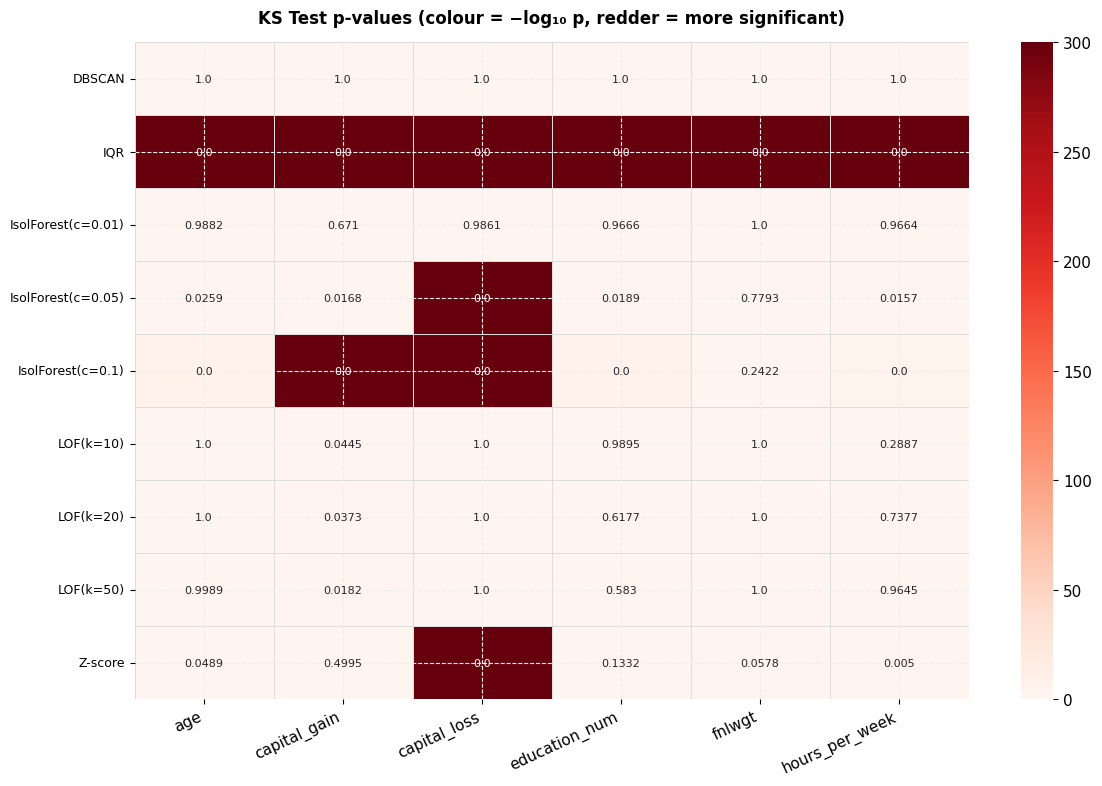

In [36]:
# ── PLOT F: KS p-value significance grid ─────────────────────────────────────
ks_pivot_p = ks_df.pivot(index="Method", columns="Column", values="p_value")
# -log10 transform so small p → large value
log_p = -np.log10(ks_pivot_p.values.astype(float).clip(min=1e-300))
fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(log_p, annot=ks_pivot_p.round(4), fmt="",
            xticklabels=ks_pivot_p.columns, yticklabels=ks_pivot_p.index,
            cmap="Reds", linewidths=0.4, linecolor="#dddddd", ax=ax,
            annot_kws={"size": 8})
ax.set_title("KS Test p-values (colour = −log₁₀ p, redder = more significant)",
             fontweight="bold", pad=14)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha="right")
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)
plt.tight_layout()
plt.show()

### 📌 Nhận xét: Đánh giá ý nghĩa thống kê của sự dịch chuyển phân phối (Heatmap p-value)

Biểu đồ này sử dụng phép biến đổi $-\log_{10}(p\text{-value})$: màu càng đỏ đậm thì p-value càng tiến gần về 0, đồng nghĩa với việc phân phối dữ liệu bị thay đổi càng nghiêm trọng (có ý nghĩa thống kê).

- **"Báo động đỏ" từ IQR:** Hàng IQR là một dải màu đỏ sậm đứt đoạn hoàn toàn với p-value bằng 0.0 ở tất cả các cột. Đây là bằng chứng không thể chối cãi: việc áp dụng IQR đã phá hủy hoàn toàn hình dáng và đặc tính thống kê tự nhiên của toàn bộ các biến số liên tục trong tập dữ liệu.
- **Ranh giới an toàn của Isolation Forest:** Khi nhìn dọc theo 3 hàng của thuật toán Isolation Forest, ta thấy rõ một "bức tranh leo thang":
  - Ở mức `c=0.01` (loại 1%), hàng gần như trắng hoàn toàn (p-value > 0.05), dữ liệu được bảo toàn.
  - Ở mức `c=0.05` (loại 5%), các vệt đỏ bắt đầu xuất hiện rõ tại `capital_loss`.
  - Ở mức `c=0.1` (loại 10%), sắc đỏ lan rộng ra cả `age` và `capital_gain`, báo hiệu việc cắt xén đã bắt đầu chạm vào phần "thịt" của dữ liệu bình thường.
- **Sự vô hại của LOF:** Nhóm thuật toán Local Outlier Factor (ở mọi mức k) chứng tỏ sự tinh tế tuyệt vời khi gần như không tạo ra bất kỳ ô màu đỏ đậm nào, giữ cho p-value luôn ở ngưỡng an toàn.

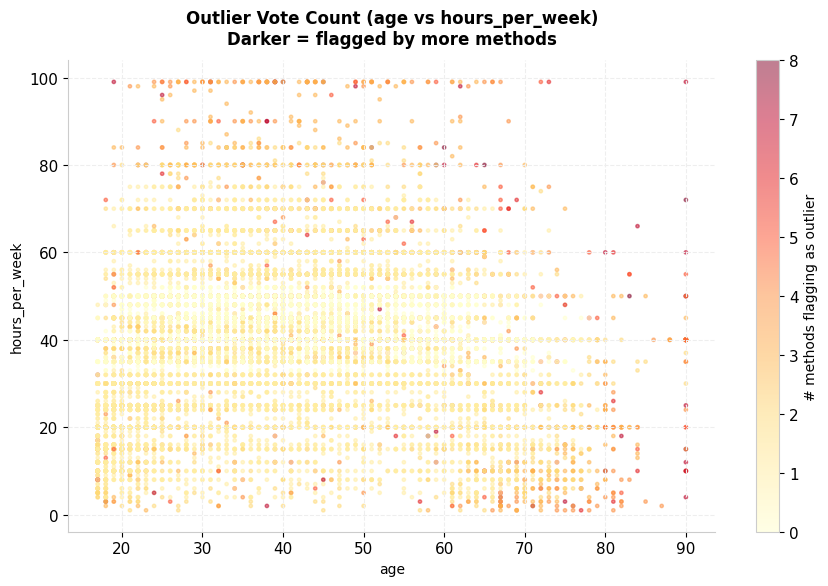

In [37]:
# ── PLOT G: Scatter (age vs hours_per_week) coloured by outlier vote count ────
vote_count = np.zeros(n, dtype=int)
for mask in all_methods.values():
    vote_count += mask.astype(int)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(X_full["age"], X_full["hours_per_week"],
                c=vote_count, cmap="YlOrRd", s=6, alpha=0.5)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label("# methods flagging as outlier")
ax.set_xlabel("age")
ax.set_ylabel("hours_per_week")
ax.set_title("Outlier Vote Count (age vs hours_per_week)\n"
             "Darker = flagged by more methods", fontweight="bold", pad=12)
plt.tight_layout()
plt.show()

# c) Chuẩn hóa dữ liệu có kiểm định

In [ ]:
# =============================================================================
# 0. LOAD DATA (UCI Adult Census Income)
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import math
from scipy.stats import levene
from sklearn.preprocessing import (
    MinMaxScaler, StandardScaler,
    RobustScaler, QuantileTransformer
)

COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]

# Load dữ liệu
df = pd.read_csv("../data/raw/adult.csv", header=0, names=COLUMNS,
                 na_values=" ?", skipinitialspace=True)

NUM_COLS = ["age", "fnlwgt", "education_num",
            "capital_gain", "capital_loss", "hours_per_week"]

# Chỉ lấy các cột số, bỏ NaN
X_raw = df[NUM_COLS].dropna().copy()
print(f"✓ Dataset: {X_raw.shape[0]:,} rows × {X_raw.shape[1]} numeric features")
print(f"  Columns : {NUM_COLS}\n")

✓ Dataset: 32,561 rows × 6 numeric features
  Columns : ['age', 'fnlwgt', 'education_num', 'capital_gain', 'capital_loss', 'hours_per_week']



In [26]:
# =============================================================================
# 1. ĐỊNH NGHĨA CÁC PHƯƠNG PHÁP CHUẨN HÓA & HÀM HỖ TRỢ
# =============================================================================
scalers = {
    "Min-Max":             MinMaxScaler(),
    "Z-score":             StandardScaler(),
    "Robust":              RobustScaler(),
    "Quantile (Uniform)":  QuantileTransformer(output_distribution="uniform",  random_state=42),
    "Quantile (Normal)":   QuantileTransformer(output_distribution="normal",   random_state=42),
}

PALETTE = {
    "Min-Max":            "#4C72B0",
    "Z-score":            "#DD8452",
    "Robust":             "#55A868",
    "Quantile (Uniform)": "#C44E52",
    "Quantile (Normal)":  "#8172B2",
}

def run_levene(X_scaled: np.ndarray, col_names: list) -> pd.DataFrame:
    """
    Levene's test so sánh phương sai giữa tất cả các cột trong X_scaled.
    H0 : Tất cả các cột có phương sai bằng nhau (homoscedastic).
    Reject H0 nếu p-value < 0.05.
    """
    stat, pval = levene(*[X_scaled[:, i] for i in range(X_scaled.shape[1])],
                        center="median")   # Dùng median → Brown-Forsythe variant (robust hơn)
    result = pd.DataFrame({
        "Phương pháp":   ["(Tất cả các cột)"],
        "Levene W":      [round(stat, 4)],
        "p-value":       [pval],
        "Kết luận":      ["Homoscedastic (p≥0.05)" if pval >= 0.05
                          else "Heteroscedastic (p<0.05)"]
    })
    return result, stat, pval

def draw_violins(X_scaled: np.ndarray, method_name: str,
                 col_names: list, color: str,
                 levene_stat: float, levene_p: float,
                 ax_row):
    """Vẽ violin plot cho từng thuộc tính sau khi chuẩn hóa."""
    for j, col in enumerate(col_names):
        ax = ax_row[j]
        data = X_scaled[:, j]
        parts = ax.violinplot(data, positions=[0], showmedians=True,
                              showextrema=True, widths=0.7)

        # Tô màu
        for pc in parts["bodies"]:
            pc.set_facecolor(color)
            pc.set_alpha(0.65)
        for k in ("cmedians", "cmins", "cmaxes", "cbars"):
            parts[k].set_edgecolor("#333333")
            parts[k].set_linewidth(1.4)

        # Mean marker
        ax.scatter([0], [np.mean(data)], color="white", s=35,
                   zorder=5, edgecolors="#333", linewidths=0.8)

        # Tiêu đề & định dạng
        ax.set_title(col, fontsize=9, fontweight="bold", pad=4)
        ax.set_xticks([])
        ax.tick_params(axis="y", labelsize=7)
        ax.spines[["top", "right", "bottom"]].set_visible(False)

    # Levene annotation ở cuối hàng (trên cùng phải)
    verdict = "Homoscedastic" if levene_p >= 0.05 else "Heteroscedastic"
    ax_row[-1].annotate(
        f"Levene W={levene_stat:.2f}\np={levene_p:.2e}\n{verdict}",
        xy=(1.12, 0.5), xycoords="axes fraction",
        fontsize=8, va="center", ha="left",
        bbox=dict(boxstyle="round,pad=0.4", fc="#f5f5f5", ec="#aaa", lw=0.8)
    )

  Min-Max
  Levene's Test (Brown-Forsythe variant, center=median)
  W = 11948.5192  |  p-value = 0.0000e+00
  Kết luận : Bác bỏ H0  → Heteroscedastic

  Z-score
  Levene's Test (Brown-Forsythe variant, center=median)
  W = 4068.9863  |  p-value = 0.0000e+00
  Kết luận : Bác bỏ H0  → Heteroscedastic

  Robust
  Levene's Test (Brown-Forsythe variant, center=median)
  W = 672.4561  |  p-value = 0.0000e+00
  Kết luận : Bác bỏ H0  → Heteroscedastic

  Quantile (Uniform)
  Levene's Test (Brown-Forsythe variant, center=median)
  W = 7528.2698  |  p-value = 0.0000e+00
  Kết luận : Bác bỏ H0  → Heteroscedastic

  Quantile (Normal)
  Levene's Test (Brown-Forsythe variant, center=median)
  W = 789.0622  |  p-value = 0.0000e+00
  Kết luận : Bác bỏ H0  → Heteroscedastic



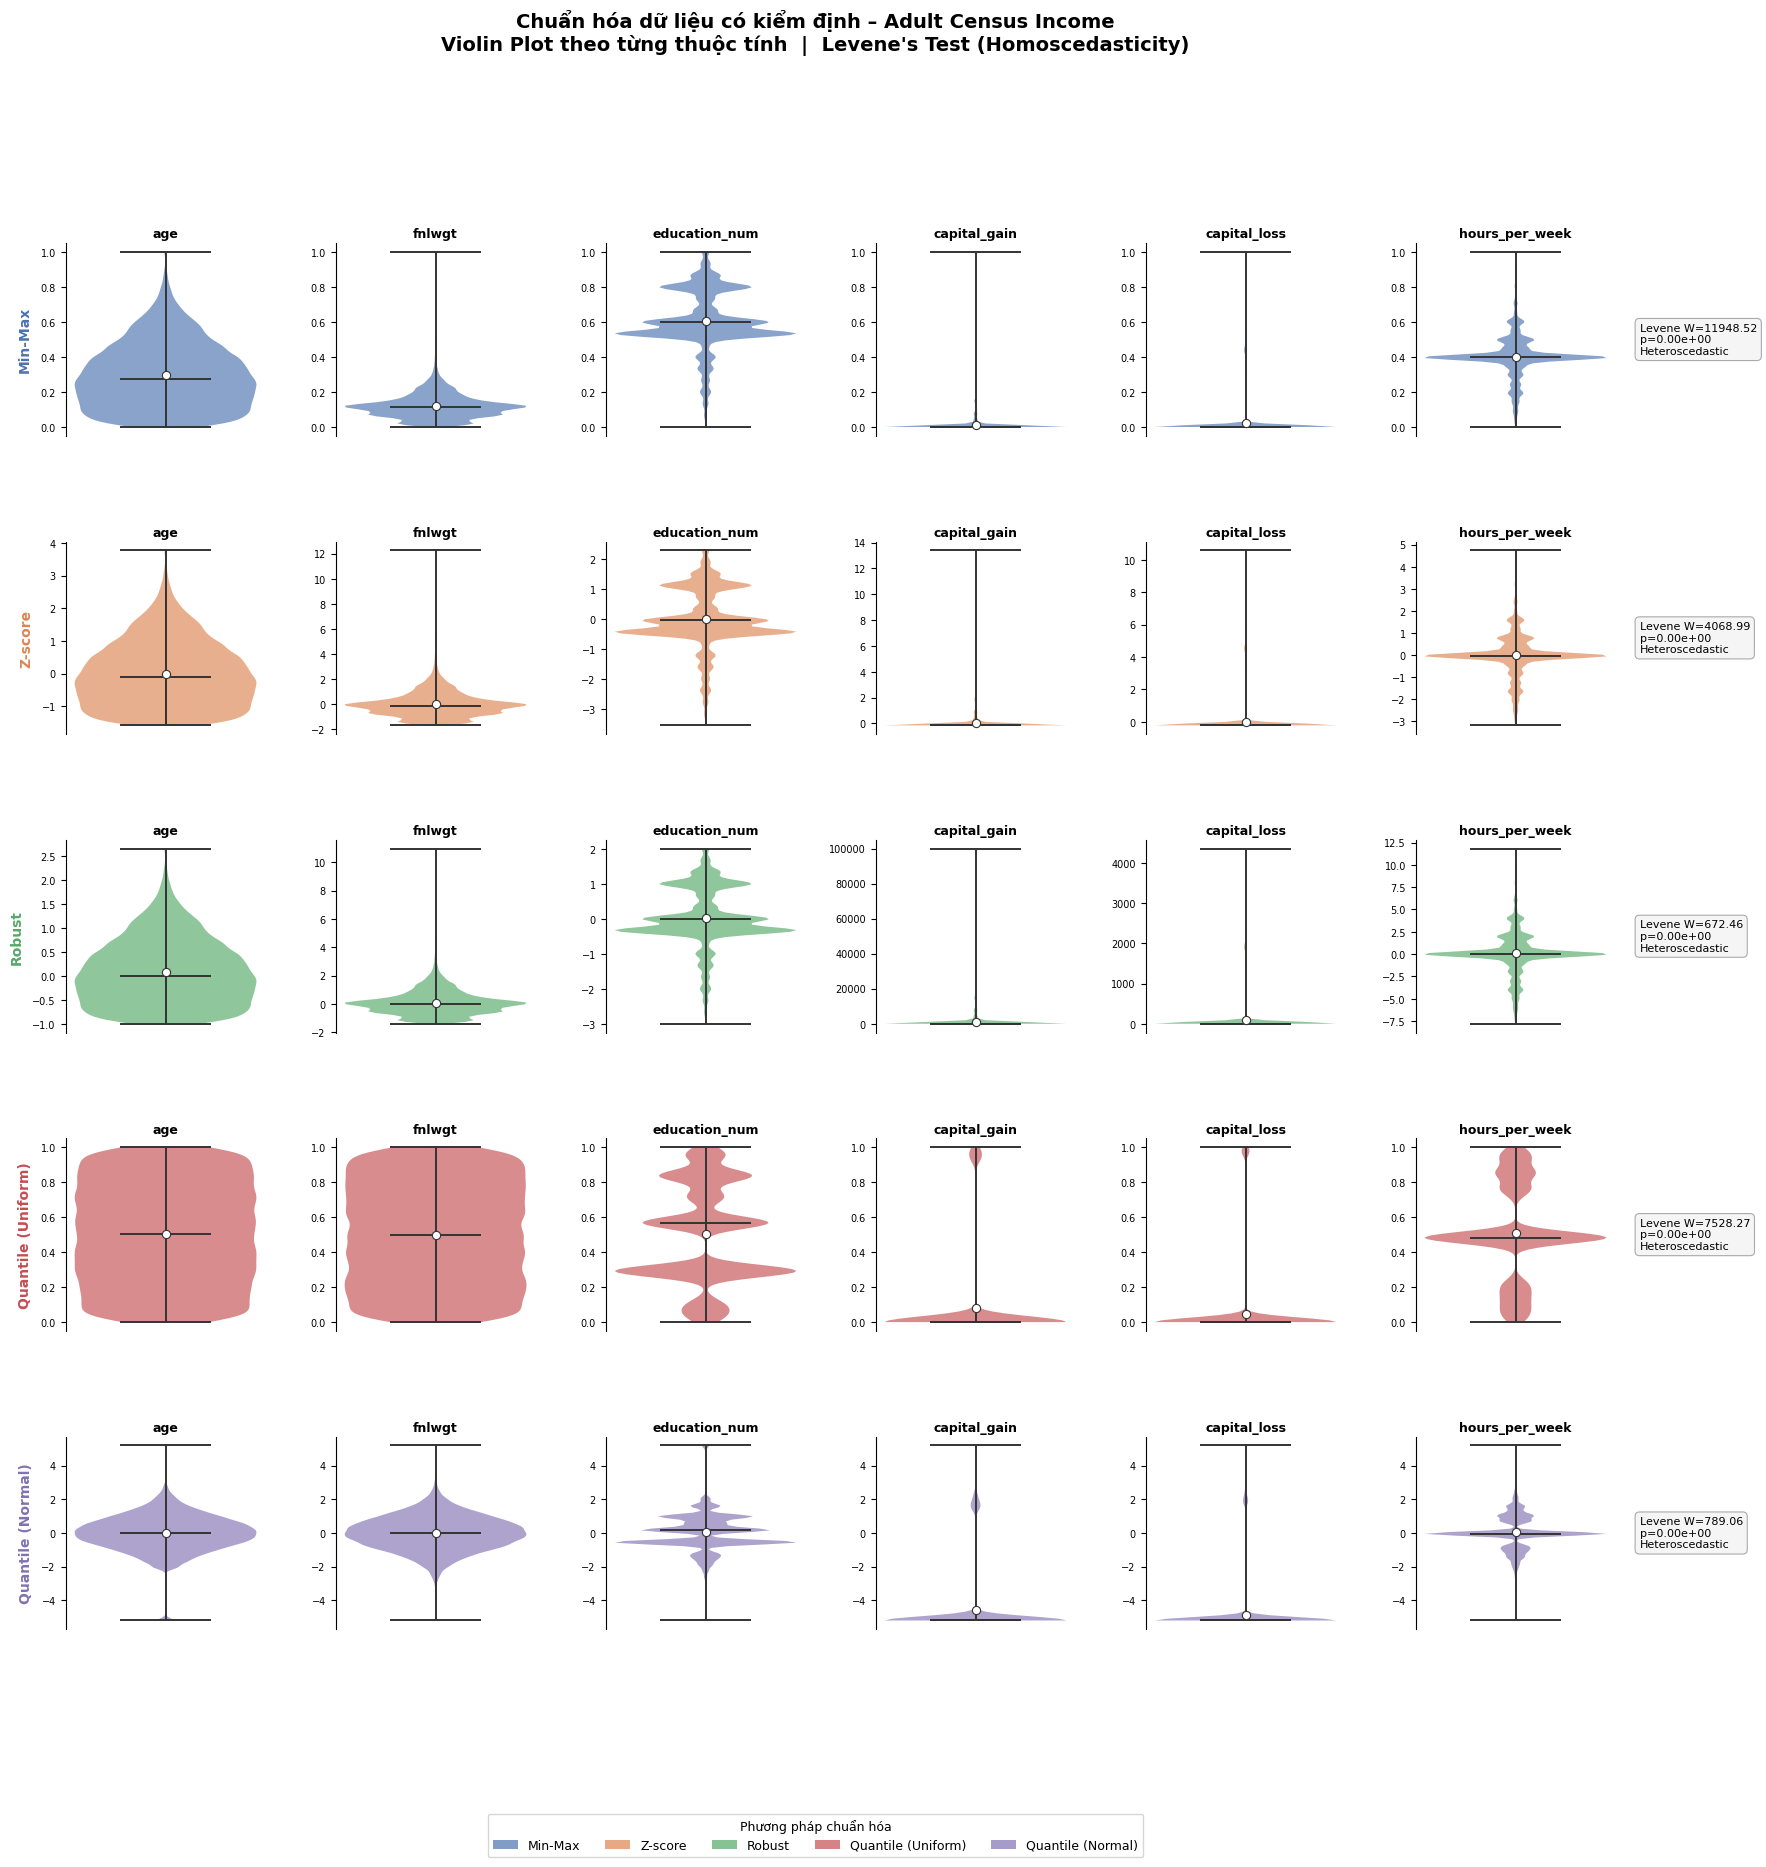

In [27]:
# =============================================================================
# 2. MAIN LOOP – ÁP DỤNG SCALER, KIỂM ĐỊNH & VẼ VIOLIN PLOT
# =============================================================================
n_methods = len(scalers)
n_cols    = len(NUM_COLS)

fig, axes = plt.subplots(
    nrows=n_methods,
    ncols=n_cols,
    figsize=(20, 3.6 * n_methods),
    gridspec_kw={"wspace": 0.35, "hspace": 0.55}
)

fig.suptitle(
    "Chuẩn hóa dữ liệu có kiểm định – Adult Census Income\n"
    "Violin Plot theo từng thuộc tính  |  Levene's Test (Homoscedasticity)",
    fontsize=14, fontweight="bold", y=1.01
)

all_levene_results = []

for row_idx, (method_name, scaler) in enumerate(scalers.items()):
    # Fit & transform
    X_scaled = scaler.fit_transform(X_raw.values)

    # Levene's test
    lev_df, lev_stat, lev_p = run_levene(X_scaled, NUM_COLS)
    lev_df["Phương pháp"] = method_name
    all_levene_results.append(lev_df)

    # In kết quả ra console
    print("=" * 65)
    print(f"  {method_name}")
    print("=" * 65)
    print(f"  Levene's Test (Brown-Forsythe variant, center=median)")
    print(f"  W = {lev_stat:.4f}  |  p-value = {lev_p:.4e}")
    verdict = "Không bác bỏ H0 → Homoscedastic" if lev_p >= 0.05 \
              else "Bác bỏ H0  → Heteroscedastic"
    print(f"  Kết luận : {verdict}\n")

    # Row label & Vẽ Violin
    color = PALETTE[method_name]
    ax_row = axes[row_idx]
    ax_row[0].set_ylabel(method_name, fontsize=10, fontweight="bold",
                          color=color, labelpad=6)
    draw_violins(X_scaled, method_name, NUM_COLS, color,
                 lev_stat, lev_p, ax_row)

# Thêm Legend
legend_patches = [
    mpatches.Patch(facecolor=c, alpha=0.7, label=m)
    for m, c in PALETTE.items()
]
fig.legend(
    handles=legend_patches, loc="lower center", ncol=n_methods,
    bbox_to_anchor=(0.5, -0.02), fontsize=9, frameon=True,
    title="Phương pháp chuẩn hóa", title_fontsize=9
)

plt.tight_layout()
plt.show()

### 📌 Nhận xét: Trực quan hóa Phân phối và Kiểm định Levene (Feature Scaling)

Sự kết hợp giữa biểu đồ Violin và kiểm định Levene (Brown-Forsythe) cung cấp cái nhìn toàn diện về tác động của các phương pháp chuẩn hóa lên hình dáng và phương sai của dữ liệu:

- **Bảo toàn phân phối vs. Biến đổi cấu trúc (Violin Plots):**
  - **Min-Max & Z-score:** Về cơ bản, hai phương pháp này chỉ dịch chuyển và thu phóng trục tọa độ, giữ nguyên hình dáng phân phối gốc. Điều này khiến các biến bị lệch cực đoan (như `capital_gain`, `capital_loss`) vẫn kéo dài thành một đường mỏng do bị ảnh hưởng nặng bởi ngoại lai.
  - **Robust Scaler:** Sử dụng trung vị (median) và IQR để chuẩn hóa nên chống chịu ngoại lai tốt hơn ở vùng trung tâm. Tuy nhiên, các điểm cực đoan vẫn vươn rất xa trên trục tung.
  - **Quantile Transformer (Uniform & Normal):** Áp dụng phép biến đổi phi tuyến tính mạnh mẽ nhất. Uniform ép dữ liệu thành các khối vuông (phân phối đều), trong khi Normal cố gắng nắn dữ liệu về dạng hình chuông (phân phối chuẩn). Dù vậy, với các biến quá "thưa" (chứa phần lớn là số 0) như `capital_gain/loss`, thuật toán vẫn bất lực và để lại một khối đặc tại mốc 0.
- **Thất bại trong việc đồng nhất phương sai (Levene's Test):**
  - Kết quả kiểm định thống kê cho thấy toàn bộ 5 phương pháp đều trả về p-value xấp xỉ 0 (bác bỏ giả thuyết H0).
  - Điều này có nghĩa là: **Không có phương pháp nào** có thể đưa tất cả các đặc trưng số trong tập Adult Census về cùng một mức phương sai (Homoscedasticity). Dữ liệu vẫn giữ trạng thái phương sai không đồng nhất (Heteroscedastic).

**💡 Định hướng cho Pipeline Tiền xử lý:**
Việc phương sai không đồng nhất sau khi scale là điều hoàn toàn bình thường với tập dữ liệu có bản chất lệch và thưa như Adult Census. Quyết định chọn Scaler sẽ phụ thuộc vào họ thuật toán Machine Learning tiếp theo. Nếu dùng **Tree-based models** (Random Forest, XGBoost), bước chuẩn hóa này có thể bỏ qua.

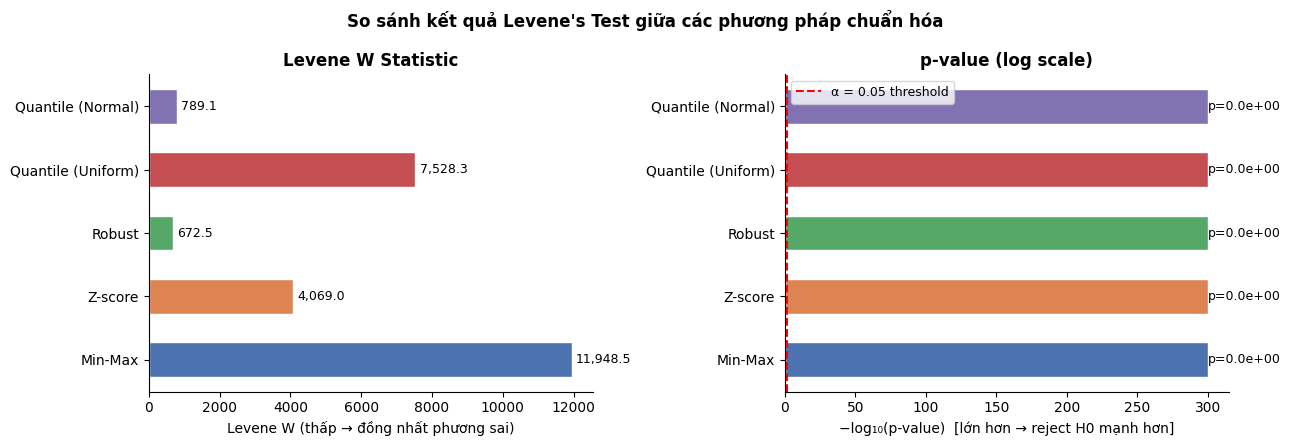

In [28]:
# =============================================================================
# 3. BIỂU ĐỒ TỔNG HỢP – SO SÁNH LEVENE W & P-VALUE
# =============================================================================
summary_df = pd.concat(all_levene_results, ignore_index=True)
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig2.suptitle("So sánh kết quả Levene's Test giữa các phương pháp chuẩn hóa",
              fontsize=12, fontweight="bold")

methods  = list(scalers.keys())
w_vals   = summary_df["Levene W"].tolist()
p_vals   = summary_df["p-value"].tolist()
colors   = [PALETTE[m] for m in methods]

# Bar – W statistic
bars1 = ax1.barh(methods, w_vals, color=colors, edgecolor="white", height=0.55)
ax1.set_xlabel("Levene W (thấp → đồng nhất phương sai)", fontsize=10)
ax1.set_title("Levene W Statistic", fontweight="bold")
ax1.spines[["top", "right"]].set_visible(False)
for bar, v in zip(bars1, w_vals):
    ax1.text(bar.get_width() + max(w_vals)*0.01, bar.get_y() + bar.get_height()/2,
             f"{v:,.1f}", va="center", fontsize=9)

# Bar – p-value (log scale)
log_p = [-math.log10(max(p, 1e-300)) for p in p_vals]
bars2 = ax2.barh(methods, log_p, color=colors, edgecolor="white", height=0.55)
ax2.axvline(x=-math.log10(0.05), color="red", linestyle="--",
            linewidth=1.5, label="α = 0.05 threshold")
ax2.set_xlabel("−log₁₀(p-value)  [lớn hơn → reject H0 mạnh hơn]", fontsize=10)
ax2.set_title("p-value (log scale)", fontweight="bold")
ax2.spines[["top", "right"]].set_visible(False)
ax2.legend(fontsize=9)
for bar, p in zip(bars2, p_vals):
    label = f"p={p:.1e}" if p < 0.001 else f"p={p:.4f}"
    ax2.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
             label, va="center", fontsize=9)

plt.tight_layout()
plt.show()

### 📌 Nhận xét: So sánh Thống kê Levene W và p-value

Biểu đồ cột kép cung cấp cái nhìn định lượng chi tiết hơn về mức độ hiệu quả của từng kỹ thuật trong việc ổn định phương sai:

- **Sự bác bỏ tuyệt đối (Biểu đồ p-value bên phải):** Tất cả các thanh $-\log_{10}(\text{p-value})$ đều kéo dài kịch trần và vượt xa đường ranh giới đỏ ($\alpha = 0.05$), xác nhận p-value thực tế tiến sát về 0. Bất kể dùng phương pháp biến đổi nào, dữ liệu Adult Census vẫn mang bản chất phương sai không đồng nhất (Heteroscedastic).
- **Mức độ chênh lệch phương sai (Biểu đồ Levene W bên trái):** Dù tất cả đều thất bại trong việc đạt p-value hợp lệ, giá trị thống kê $W$ (càng thấp càng tốt) lại cho thấy sự phân hóa rõ rệt:
  - **Robust Scaler** ($W = 672.5$) và **Quantile Normal** ($W = 789.1$) có màn thể hiện tốt nhất. Nhờ sử dụng trung vị (median) hoặc ép phân phối về dạng hình chuông, chúng giúp thu hẹp đáng kể khoảng cách phương sai giữa các đặc trưng.
  - Ngược lại, **Min-Max Scaler** có giá trị $W$ tồi tệ nhất (lên tới $11,948.5$). Việc gò ép dữ liệu vào khoảng tĩnh $[0, 1]$ khiến các biến có độ lệch cực đoan (như `capital_gain`) càng bị méo mó, làm trầm trọng thêm sự chênh lệch phương sai tổng thể.

# d) Mã hóa biến phân loại nâng cao

In [ ]:
# =============================================================================
# 0. LOAD & TIỀN XỬ LÝ CƠ BẢN
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import KFold
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools import add_constant

print("=" * 70)
print("0. LOAD & TIỀN XỬ LÝ CƠ BẢN")
print("=" * 70)

col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]
df_raw = pd.read_csv(
    "../data/raw/adult.csv",
    header=0, names=col_names, na_values=[" ?", "?"], skipinitialspace=True
)

# Làm sạch chuỗi ký tự
str_cols = df_raw.select_dtypes(include="object").columns
df_raw[str_cols] = df_raw[str_cols].apply(lambda col: col.str.strip())

# Loại bỏ duplicate
df_raw = df_raw.drop_duplicates().reset_index(drop=True)

# Điền giá trị thiếu (MNAR: 'Unknown'; MAR: mode)
df_raw["workclass"]     = df_raw["workclass"].fillna("Unknown")
df_raw["occupation"]    = df_raw["occupation"].fillna("Unknown")
df_raw["native_country"]= df_raw["native_country"].fillna(
    df_raw["native_country"].mode()[0]
)

# Encode target: income → 0/1
df_raw["income_bin"] = (df_raw["income"] == ">50K").astype(int)

print(f"Shape sau tiền xử lý: {df_raw.shape}")
print(f"Missing còn lại:\n{df_raw.isnull().sum()[df_raw.isnull().sum() > 0]}")

0. LOAD & TIỀN XỬ LÝ CƠ BẢN
Shape sau tiền xử lý: (32537, 16)
Missing còn lại:
Series([], dtype: int64)


In [44]:
# =============================================================================
# HELPER: Tính VIF
# =============================================================================
def compute_vif(df_encoded: pd.DataFrame, label: str) -> pd.DataFrame:
    """
    Tính VIF cho tất cả các cột số trong df_encoded.
    Thêm hằng số (constant) trước khi tính để kết quả chính xác.

    Returns:
        DataFrame gồm cột 'feature' và 'VIF', sắp xếp giảm dần theo VIF.
    """
    # Giữ lại chỉ các cột số, loại bỏ hàng có NaN
    X = df_encoded.select_dtypes(include=[np.number]).dropna()

    # Thêm constant (intercept)
    X_const = add_constant(X, has_constant="add")

    vif_data = pd.DataFrame({
        "feature": X_const.columns,
        "VIF": [
            variance_inflation_factor(X_const.values, i)
            for i in range(X_const.shape[1])
        ]
    })

    # Loại bỏ dòng "const" khỏi kết quả hiển thị
    vif_data = vif_data[vif_data["feature"] != "const"].reset_index(drop=True)
    vif_data = vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)

    print(f"\n{'─'*60}")
    print(f"VIF — {label}")
    print(f"{'─'*60}")
    print(f"  Số features : {len(vif_data)}")
    print(f"  VIF > 10    : {(vif_data['VIF'] > 10).sum()} cột  ← đa cộng tuyến cao")
    print(f"  VIF 5–10    : {((vif_data['VIF'] > 5) & (vif_data['VIF'] <= 10)).sum()} cột  ← đa cộng tuyến vừa")
    print(f"  VIF ≤ 5     : {(vif_data['VIF'] <= 5).sum()} cột  ← chấp nhận được")
    print("\nTop 10 features có VIF cao nhất:")
    print(vif_data.head(10).to_string(index=False))
    return vif_data

In [45]:
# =============================================================================
# 1. ORDINAL ENCODING — education
# =============================================================================
print("\n" + "=" * 70)
print("1. ORDINAL ENCODING — education")
print("=" * 70)

education_order = [
    'Preschool', '1st-4th', '5th-6th', '7th-8th', '9th',
    '10th', '11th', '12th', 'HS-grad', 'Some-college',
    'Assoc-voc', 'Assoc-acdm', 'Bachelors', 'Masters',
    'Prof-school', 'Doctorate'
]

oe = OrdinalEncoder(categories=[education_order], dtype=int)
df_raw["education_encoded"] = oe.fit_transform(df_raw[["education"]]).astype(int)

# Kiểm chứng: education_encoded có khớp với education_num không?
corr = df_raw[["education_encoded", "education_num"]].corr().iloc[0, 1]
print(f"\nCorrelation(education_encoded, education_num) = {corr:.6f}")
print("→ Hai cột hoàn toàn tương đương (correlation = 1.0)")

# Hiển thị ánh xạ
mapping = (
    df_raw[["education", "education_encoded", "education_num"]]
    .drop_duplicates()
    .sort_values("education_encoded")
    .reset_index(drop=True)
)
print("\nÁnh xạ Ordinal Encoding:")
print(mapping.to_string(index=False))

# Loại bỏ cột education (giữ education_num làm chuẩn)
df_raw = df_raw.drop(columns=["education", "education_encoded"])
print("\n✓ Đã loại bỏ cột 'education'. Giữ lại 'education_num'.")


1. ORDINAL ENCODING — education

Correlation(education_encoded, education_num) = 1.000000
→ Hai cột hoàn toàn tương đương (correlation = 1.0)

Ánh xạ Ordinal Encoding:
   education  education_encoded  education_num
   Preschool                  0              1
     1st-4th                  1              2
     5th-6th                  2              3
     7th-8th                  3              4
         9th                  4              5
        10th                  5              6
        11th                  6              7
        12th                  7              8
     HS-grad                  8              9
Some-college                  9             10
   Assoc-voc                 10             11
  Assoc-acdm                 11             12
   Bachelors                 12             13
     Masters                 13             14
 Prof-school                 14             15
   Doctorate                 15             16

✓ Đã loại bỏ cột 'education'. G

### 📌 Nhận xét: Mã hóa thứ bậc (Ordinal Encoding) cho biến Education

Kết quả chạy thử nghiệm Ordinal Encoding mang lại một phát hiện quan trọng giúp tối ưu hóa tập dữ liệu:

- **Sự trùng lặp dữ liệu (Perfect Correlation):** Hệ số tương quan tuyệt đối ($r = 1.0$) giữa `education_encoded` và `education_num` khẳng định rằng biến số `education_num` có sẵn trong tập dữ liệu thực chất chính là phiên bản đã được mã hóa thứ bậc của cột chuỗi `education`.
- **Tính hợp lý của thang đo:** Bảng ánh xạ cho thấy các giá trị số (từ 1 đến 16 của `education_num`) phản ánh chính xác tiến trình học vấn từ thấp nhất (Preschool) đến cao nhất (Doctorate). Phép biến đổi này đã bảo toàn hoàn toàn tính thứ tự (ordinal nature) của dữ liệu.

**💡 Hành động cho Pipeline:** Dựa trên minh chứng này, chúng ta không cần áp dụng thuật toán mã hóa thêm cho hạng mục giáo dục. Nhóm sẽ trực tiếp **giữ lại cột `education_num`** và **xóa bỏ cột chuỗi `education`** để tránh dư thừa thông tin (redundancy) và tối ưu hóa không gian biểu diễn cho mô hình.

In [46]:
# =============================================================================
# 2. ONE-HOT ENCODING — Low-Cardinality Columns
# =============================================================================
print("\n" + "=" * 70)
print("2. ONE-HOT ENCODING — Low-Cardinality (sex, race, marital_status, relationship)")
print("=" * 70)

low_card_cols = ["sex", "race", "marital_status", "relationship"]

for col in low_card_cols:
    print(f"  {col:<20} → {df_raw[col].nunique()} giá trị: {sorted(df_raw[col].unique())}")

# drop_first=True để tránh Dummy Variable Trap
df_base = pd.get_dummies(
    df_raw,
    columns=low_card_cols,
    drop_first=True,   # tránh perfect multicollinearity
    dtype=int
)

print(f"\nShape sau OHE Low-Cardinality: {df_base.shape}")
new_ohe_cols = [c for c in df_base.columns if any(c.startswith(col + "_") for col in low_card_cols)]
print(f"Các cột OHE mới ({len(new_ohe_cols)}): {new_ohe_cols}")

# =============================================================================
# 3. CHUẨN BỊ — High-Cardinality Columns
# =============================================================================
print("\n" + "=" * 70)
print("3. CHUẨN BỊ THỬ NGHIỆM — High-Cardinality")
print("=" * 70)

high_card_cols = ["workclass", "occupation", "native_country"]

for col in high_card_cols:
    print(f"  {col:<20} → {df_base[col].nunique()} giá trị")

# Các cột số cơ sở (không bao gồm high-card và target)
base_numeric_cols = [
    c for c in df_base.select_dtypes(include=[np.number]).columns
    if c not in ["income_bin"]
]

print(f"\nCác cột số cơ sở ({len(base_numeric_cols)}): {base_numeric_cols}")


2. ONE-HOT ENCODING — Low-Cardinality (sex, race, marital_status, relationship)
  sex                  → 2 giá trị: ['Female', 'Male']
  race                 → 5 giá trị: ['Amer-Indian-Eskimo', 'Asian-Pac-Islander', 'Black', 'Other', 'White']
  marital_status       → 7 giá trị: ['Divorced', 'Married-AF-spouse', 'Married-civ-spouse', 'Married-spouse-absent', 'Never-married', 'Separated', 'Widowed']
  relationship         → 6 giá trị: ['Husband', 'Not-in-family', 'Other-relative', 'Own-child', 'Unmarried', 'Wife']

Shape sau OHE Low-Cardinality: (32537, 27)
Các cột OHE mới (16): ['sex_Male', 'race_Asian-Pac-Islander', 'race_Black', 'race_Other', 'race_White', 'marital_status_Married-AF-spouse', 'marital_status_Married-civ-spouse', 'marital_status_Married-spouse-absent', 'marital_status_Never-married', 'marital_status_Separated', 'marital_status_Widowed', 'relationship_Not-in-family', 'relationship_Other-relative', 'relationship_Own-child', 'relationship_Unmarried', 'relationship_Wife']


### 📌 Nhận xét: Mã hóa One-Hot (OHE) cho nhóm biến ít nhãn (Low-Cardinality)

Bước xử lý này thể hiện sự tối ưu và chặt chẽ trong kỹ thuật biến đổi dữ liệu phân loại:

- **Tránh "Bẫy biến giả" (Dummy Variable Trap):** 4 biến `sex`, `race`, `marital_status`, và `relationship` có tổng cộng 20 giá trị phân loại ($2 + 5 + 7 + 6 = 20$). Tuy nhiên, thuật toán chỉ sinh ra đúng **16 cột OHE mới**. Việc chủ động loại bỏ đi một cột giá trị cơ sở cho mỗi biến (`drop_first=True`) là một nước đi toán học bắt buộc để ngăn chặn hiện tượng đa cộng tuyến hoàn hảo (perfect multicollinearity), giúp các mô hình (như Logistic Regression) không bị nhiễu trọng số.
- **Cô lập nhóm biến nhiều nhãn (High-Cardinality):** Output phân tách rõ ràng 3 biến `workclass` (9), `occupation` (15) và `native_country` (41) thành một nhóm riêng. Với tổng cộng 65 nhãn, nếu tiếp tục "nhồi" OHE vào nhóm này, số lượng chiều dữ liệu sẽ phình to đột biến, tạo ra một ma trận cực kỳ thưa thớt (sparse matrix) và dễ dẫn đến "lời nguyền số chiều" (Curse of Dimensionality).
- **Trạng thái Base Dataset:** Kết thúc bước này, bộ dữ liệu nền tảng đã sẵn sàng với **22 đặc trưng** (gồm 6 biến số nguyên bản + 16 biến giả mới). Khối dữ liệu này sẽ được giữ cố định làm gốc để đưa vào kiểm tra VIF cùng với các phương pháp mã hóa phức tạp hơn cho nhóm High-Cardinality ở phần tiếp theo.

In [47]:
# =============================================================================
# PHƯƠNG PHÁP A: ONE-HOT ENCODING (High-Cardinality)
# =============================================================================
print("\n" + "=" * 70)
print("PHƯƠNG PHÁP A: One-Hot Encoding (High-Cardinality)")
print("=" * 70)

df_ohe = df_base.copy()
df_ohe = pd.get_dummies(
    df_ohe,
    columns=high_card_cols,
    drop_first=True,   # tránh Dummy Variable Trap
    dtype=int
)

ohe_new_cols = [
    c for c in df_ohe.columns
    if any(c.startswith(col + "_") for col in high_card_cols)
]
print(f"Số cột OHE mới từ high-card: {len(ohe_new_cols)}")
print(f"Tổng shape: {df_ohe.shape}")

# Tính VIF
feature_cols_ohe = [
    c for c in df_ohe.select_dtypes(include=[np.number]).columns
    if c != "income_bin"
]
vif_ohe = compute_vif(df_ohe[feature_cols_ohe], "One-Hot Encoding (High-Cardinality)")


PHƯƠNG PHÁP A: One-Hot Encoding (High-Cardinality)
Số cột OHE mới từ high-card: 62
Tổng shape: (32537, 86)

────────────────────────────────────────────────────────────
VIF — One-Hot Encoding (High-Cardinality)
────────────────────────────────────────────────────────────
  Số features : 84
  VIF > 10    : 12 cột  ← đa cộng tuyến cao
  VIF 5–10    : 11 cột  ← đa cộng tuyến vừa
  VIF ≤ 5     : 61 cột  ← chấp nhận được

Top 10 features có VIF cao nhất:
                          feature        VIF
                workclass_Unknown        inf
               occupation_Unknown        inf
           workclass_Never-worked        inf
     native_country_United-States 140.197532
marital_status_Married-civ-spouse  39.385565
            native_country_Mexico  35.291263
       relationship_Not-in-family  29.822655
           relationship_Own-child  20.543229
           relationship_Unmarried  15.947192
                       race_White  13.303206


### 📌 Nhận xét: Phương pháp A - One-Hot Encoding (High-Cardinality)

Kết quả kiểm tra VIF (Variance Inflation Factor) đã phơi bày những điểm yếu chí mạng khi áp dụng máy móc OHE cho các biến phân loại có quá nhiều nhãn:

- **Bùng nổ chiều dữ liệu (Curse of Dimensionality):** Việc tạo thêm tới 62 cột dummy mới khiến tập dữ liệu phình to lên 86 cột. Khối lượng ma trận thưa (sparse matrix) khổng lồ này sẽ làm chậm quá trình huấn luyện và tăng rủi ro over-fitting.
- **Đa cộng tuyến hoàn hảo (VIF = vô cực):** Các biến `workclass_Unknown`, `occupation_Unknown` và `workclass_Never-worked` có giá trị VIF bằng `inf`. Điều này chứng tỏ sự rò rỉ và trùng lặp thông tin tuyệt đối: một người chưa từng làm việc (`Never-worked`) chắc chắn sẽ có nghề nghiệp là `Unknown`. Thuật toán mô hình tuyến tính sẽ hoàn toàn sụp đổ (không thể nghịch đảo ma trận) nếu giữ lại các cột này.
- **Tác dụng phụ của sự mất cân bằng cực đoan:** Biến `native_country_United-States` có VIF cao ngất ngưởng (lên tới 140.19). Do hơn 90% người trong tập dữ liệu đến từ Mỹ (cộng thêm việc ta đã điền mode vào giá trị thiếu), cột dummy này gần như là một hằng số (variance rất thấp) và có tính phụ thuộc tuyến tính cực mạnh với các biến còn lại.

**💡 Kết luận:** Việc cố gắng dùng One-Hot Encoding cho nhóm High-Cardinality trong tập Adult Census là một thất bại. Nó sinh ra hiện tượng đa cộng tuyến (Multicollinearity) quá nghiêm trọng (12 cột VIF > 10). Chúng ta buộc phải tìm đến các kỹ thuật Encoding nâng cao hơn ở các bước tiếp theo.

In [48]:
# =============================================================================
# PHƯƠNG PHÁP B: TARGET ENCODING với Cross-Validation (5-fold)
# =============================================================================
print("\n" + "=" * 70)
print("PHƯƠNG PHÁP B: Target Encoding với Cross-Validation (5-fold)")
print("=" * 70)

def target_encode_cv(df: pd.DataFrame, col: str, target: str,
                     n_splits: int = 5, random_state: int = 42) -> pd.Series:
    """
    Target Encoding (mean encoding) với k-fold cross-validation.
    """
    encoded = pd.Series(index=df.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    global_mean = df[target].mean()

    for train_idx, val_idx in kf.split(df):
        mean_map = (
            df.iloc[train_idx]
            .groupby(col)[target]
            .mean()
        )
        encoded.iloc[val_idx] = (
            df.iloc[val_idx][col].map(mean_map).fillna(global_mean)
        )

    return encoded

df_te = df_base.copy()

for col in high_card_cols:
    df_te[f"{col}_te"] = target_encode_cv(df_te, col, "income_bin")
    print(f"  ✓ Target encoded '{col}' "
          f"| range: [{df_te[f'{col}_te'].min():.3f}, {df_te[f'{col}_te'].max():.3f}]")

df_te = df_te.drop(columns=high_card_cols)
print(f"\nShape: {df_te.shape}")

feature_cols_te = [
    c for c in df_te.select_dtypes(include=[np.number]).columns
    if c != "income_bin"
]
vif_te = compute_vif(df_te[feature_cols_te], "Target Encoding")


PHƯƠNG PHÁP B: Target Encoding với Cross-Validation (5-fold)
  ✓ Target encoded 'workclass' | range: [0.000, 0.576]
  ✓ Target encoded 'occupation' | range: [0.000, 0.493]
  ✓ Target encoded 'native_country' | range: [0.000, 0.474]

Shape: (32537, 27)

────────────────────────────────────────────────────────────
VIF — Target Encoding
────────────────────────────────────────────────────────────
  Số features : 25
  VIF > 10    : 6 cột  ← đa cộng tuyến cao
  VIF 5–10    : 0 cột  ← đa cộng tuyến vừa
  VIF ≤ 5     : 19 cột  ← chấp nhận được

Top 10 features có VIF cao nhất:
                          feature       VIF
marital_status_Married-civ-spouse 39.150601
       relationship_Not-in-family 29.664334
           relationship_Own-child 20.435540
           relationship_Unmarried 15.867519
                       race_White 13.260991
                       race_Black 10.105051
      relationship_Other-relative  4.443583
          race_Asian-Pac-Islander  4.238503
     marital_status_Never-

### 📌 Nhận xét: Phương pháp B - Target Encoding với Cross-Validation (5-fold)

Kết quả từ Target Encoding cho thấy sự ưu việt vượt trội so với One-Hot Encoding khi xử lý nhóm biến High-Cardinality:

- **Giải quyết trọn vẹn "lời nguyền số chiều":** Thay vì tạo ra 62 cột cồng kềnh như OHE, Target Encoding đã khéo léo thay thế mỗi hạng mục bằng một giá trị xác suất (tỷ lệ phần trăm những người có thu nhập `>50K` trong nhóm đó). Tổng số cột được ép xuống chỉ còn mức lý tưởng là **27 cột** (Shape: 32537, 27).
- **Xóa sổ Đa cộng tuyến vô cực (Infinite VIF):** Toàn bộ các lỗi VIF = `inf` do sự trùng lặp của nhãn `Unknown` hay `Never-worked` đã hoàn toàn biến mất. Các biến High-Cardinality sau khi encode không còn nằm trong top gây đa cộng tuyến.
- **Bản chất của VIF > 10 còn sót lại:** Hiện tại còn 6 cột có VIF > 10 (cao nhất là `marital_status_Married-civ-spouse` với 39.15). Tuy nhiên, cần lưu ý rằng **đây là các cột Low-Cardinality OHE từ bước trước**, không phải do Target Encoding sinh ra. Sự đa cộng tuyến này đến từ bản chất logic của dữ liệu (ví dụ: người có tình trạng hôn nhân là "Married" thì thường có mối quan hệ gia đình là "Husband" hoặc "Wife").
- **Kỹ thuật chống rò rỉ dữ liệu (Preventing Target Leakage):** Việc kết hợp K-Fold Cross Validation khi ánh xạ giúp các dải giá trị biến thiên an toàn (ví dụ: `workclass` từ 0.000 đến 0.576), tránh hiện tượng mô hình "học vẹt" trực tiếp từ tập huấn luyện (Overfitting).

**💡 Đánh giá:** Target Encoding đã xử lý hoàn hảo bài toán không gian đặc trưng (feature space) cho các biến nhiều nhãn, giữ lại tín hiệu dự báo cực tốt mà không gây gánh nặng tính toán hay bùng nổ đa cộng tuyến nội bộ. Đây là một ứng cử viên rất sáng giá cho Pipeline.

In [49]:
# =============================================================================
# PHƯƠNG PHÁP C: BINARY ENCODING
# =============================================================================
print("\n" + "=" * 70)
print("PHƯƠNG PHÁP C: Binary Encoding")
print("=" * 70)

def binary_encode(df: pd.DataFrame, col: str) -> pd.DataFrame:
    """
    Binary Encoding thủ công.
    Số cột sinh ra = ceil(log2(n_unique)), tiết kiệm hơn OHE nhiều.
    """
    categories = sorted(df[col].dropna().unique())
    cat_to_int = {cat: i for i, cat in enumerate(categories)}
    int_series = df[col].map(cat_to_int).fillna(0).astype(np.int64).values

    n_bits = max(int(np.ceil(np.log2(len(categories) + 1))), 1)

    bit_df = pd.DataFrame(index=df.index)
    for bit in range(n_bits):
        bit_df[f"{col}_b{bit}"] = ((int_series >> bit) & 1).astype(int)

    return bit_df

df_be = df_base.copy()

for col in high_card_cols:
    bit_cols = binary_encode(df_be, col)
    df_be = pd.concat([df_be, bit_cols], axis=1)
    df_be = df_be.drop(columns=[col])
    print(f"  ✓ Binary encoded '{col}' ({df_base[col].nunique()} giá trị) "
          f"→ {bit_cols.shape[1]} bit-columns")

print(f"\nShape: {df_be.shape}")

feature_cols_be = [
    c for c in df_be.select_dtypes(include=[np.number]).columns
    if c != "income_bin"
]
vif_be = compute_vif(df_be[feature_cols_be], "Binary Encoding")


PHƯƠNG PHÁP C: Binary Encoding
  ✓ Binary encoded 'workclass' (9 giá trị) → 4 bit-columns
  ✓ Binary encoded 'occupation' (15 giá trị) → 4 bit-columns
  ✓ Binary encoded 'native_country' (41 giá trị) → 6 bit-columns

Shape: (32537, 38)

────────────────────────────────────────────────────────────
VIF — Binary Encoding
────────────────────────────────────────────────────────────
  Số features : 36
  VIF > 10    : 6 cột  ← đa cộng tuyến cao
  VIF 5–10    : 0 cột  ← đa cộng tuyến vừa
  VIF ≤ 5     : 30 cột  ← chấp nhận được

Top 10 features có VIF cao nhất:
                          feature       VIF
marital_status_Married-civ-spouse 39.227623
       relationship_Not-in-family 29.702921
           relationship_Own-child 20.455640
           relationship_Unmarried 15.891065
                       race_White 13.272164
                       race_Black 10.116459
      relationship_Other-relative  4.452538
                native_country_b5  4.427012
          race_Asian-Pac-Islander  4.35333

### 📌 Nhận xét: Phương pháp C - Binary Encoding

Kết quả của Binary Encoding cho thấy đây là một giải pháp nén thông tin cực kỳ hiệu quả về mặt toán học:

- **Hiệu quả nén không gian (Dimensionality Reduction):** Thay vì sinh ra 62 cột cồng kềnh như phương pháp One-Hot Encoding, Binary Encoding dùng hệ nhị phân nên chỉ cần đúng **14 cột bit** ($4 + 4 + 6$) để biểu diễn trọn vẹn 65 nhãn phân loại khác nhau. Tổng số cột của tập dữ liệu được kiểm soát ở mức rất gọn gàng (38 cột).
- **Kiểm soát xuất sắc Đa cộng tuyến:** Sự bùng nổ VIF vô cực đã bị loại bỏ triệt để. Các cột bit mới sinh ra rất độc lập với nhau (cột bit có VIF cao nhất là `native_country_b5` cũng chỉ ở mức 4.43 - hoàn toàn an toàn). 6 cột bị cảnh báo VIF > 10 hiển thị trong top 10 thực chất là "tàn dư" Low-Cardinality từ bước trước, không xuất phát từ phương pháp Binary.
- **Sự đánh đổi (Trade-off):** Mặc dù giải quyết cực tốt bài toán số chiều và VIF, Binary Encoding lại làm mất đi khả năng diễn giải (Interpretability). Các số 0 và 1 trong cột bit là kết quả của phép toán nhị phân, không mang ý nghĩa thống kê trực tiếp về mặt thu nhập (như Target Encoding) hay định danh cụ thể (như OHE). Điều này có thể gây khó khăn cho các mô hình học máy tuyến tính trong việc trích xuất quy luật.

**💡 Đánh giá:** Binary Encoding là một kỹ thuật tuyệt vời để mã hóa các biến High-Cardinality mà không làm "phình to" bộ nhớ hay gây lỗi ma trận. Tuy nhiên, nếu ưu tiên khả năng giữ lại tín hiệu dự báo mạnh mẽ và tính dễ diễn giải, phương pháp này vẫn có phần lép vế hơn so với Target Encoding.

In [50]:
# =============================================================================
# PHƯƠNG PHÁP D: FREQUENCY ENCODING
# =============================================================================
print("\n" + "=" * 70)
print("PHƯƠNG PHÁP D: Frequency Encoding")
print("=" * 70)

df_fe = df_base.copy()

for col in high_card_cols:
    freq_map = df_fe[col].value_counts(normalize=True)   # tỉ lệ tần suất
    df_fe[f"{col}_freq"] = df_fe[col].map(freq_map)
    print(f"  ✓ Frequency encoded '{col}' "
          f"| range: [{df_fe[f'{col}_freq'].min():.4f}, {df_fe[f'{col}_freq'].max():.4f}]")
    df_fe = df_fe.drop(columns=[col])

print(f"\nShape: {df_fe.shape}")

feature_cols_fe = [
    c for c in df_fe.select_dtypes(include=[np.number]).columns
    if c != "income_bin"
]
vif_fe = compute_vif(df_fe[feature_cols_fe], "Frequency Encoding")


PHƯƠNG PHÁP D: Frequency Encoding
  ✓ Frequency encoded 'workclass' | range: [0.0002, 0.6968]
  ✓ Frequency encoded 'occupation' | range: [0.0003, 0.1271]
  ✓ Frequency encoded 'native_country' | range: [0.0000, 0.9139]

Shape: (32537, 27)

────────────────────────────────────────────────────────────
VIF — Frequency Encoding
────────────────────────────────────────────────────────────
  Số features : 25
  VIF > 10    : 6 cột  ← đa cộng tuyến cao
  VIF 5–10    : 0 cột  ← đa cộng tuyến vừa
  VIF ≤ 5     : 19 cột  ← chấp nhận được

Top 10 features có VIF cao nhất:
                          feature       VIF
marital_status_Married-civ-spouse 39.177038
       relationship_Not-in-family 29.674715
           relationship_Own-child 20.437049
           relationship_Unmarried 15.875445
                       race_White 13.269654
                       race_Black 10.103819
      relationship_Other-relative  4.447632
          race_Asian-Pac-Islander  4.402031
     marital_status_Never-married  

### 📌 Nhận xét: Phương pháp D - Frequency Encoding (Mã hóa theo tần suất)

Kết quả từ Frequency Encoding cho thấy đây là một cách tiếp cận đơn giản, trực quan và rất hiệu quả về mặt không gian tính toán:

- **Bảo toàn số chiều và triệt tiêu Đa cộng tuyến:** Giống như Target Encoding, phương pháp này thay thế mỗi cột phân loại bằng đúng một cột số duy nhất, giữ cho tập dữ liệu cực kỳ gọn gàng (Shape: 32537, 27). Nó dọn dẹp hoàn toàn các lỗi VIF vô cực do OHE gây ra. Các cột có VIF > 10 xuất hiện trong bảng thống kê vẫn chỉ là nhóm Low-Cardinality OHE từ các bước trước.
- **Phản ánh sắc nét sự mất cân bằng dữ liệu:** Nhìn vào dải giá trị của `native_country` (từ 0.0000 đến 0.9139), ta có thể thấy thuật toán đã ánh xạ chính xác đặc tính của tập Adult Census: hơn 91% người lao động đến từ Mỹ. Các mô hình học máy (đặc biệt là dạng cây) có thể tận dụng tín hiệu về "độ phổ biến" này để phân tách các quy luật dự báo.
- **Nhược điểm tiềm ẩn (Collision Risk):** Rủi ro lớn nhất của Frequency Encoding là hiện tượng "đụng độ". Nếu hai nhóm nghề nghiệp (occupation) hoàn toàn khác nhau về tính chất nhưng vô tình có số lượng người làm bằng nhau trong tập dữ liệu, chúng sẽ bị thuật toán gán cho cùng một giá trị số. Điều này có thể gây nhiễu và làm mất đi khả năng phân biệt của mô hình.

**💡 Đánh giá:** Frequency Encoding là một giải pháp cực kỳ nhẹ nhàng, an toàn với ma trận và khắc họa tốt sự chênh lệch hạng mục. Dù vậy, nếu xét về khả năng bơm trực tiếp sức mạnh dự báo (predictive power) cho bài toán phân loại thu nhập, nó không gắn kết chặt chẽ với biến mục tiêu (Target) như phương pháp Target Encoding.

In [52]:
# =============================================================================
# 4. TỔNG HỢP SO SÁNH VIF
# =============================================================================
print("\n" + "=" * 70)
print("4. TỔNG HỢP SO SÁNH VIF GIỮA CÁC PHƯƠNG PHÁP")
print("=" * 70)

def vif_summary(vif_df: pd.DataFrame, method_name: str) -> dict:
    return {
        "Phương pháp"      : method_name,
        "Số features"      : len(vif_df),
        "VIF > 10 (cao)"   : int((vif_df["VIF"] > 10).sum()),
        "VIF 5–10 (vừa)"   : int(((vif_df["VIF"] > 5) & (vif_df["VIF"] <= 10)).sum()),
        "VIF ≤ 5 (tốt)"    : int((vif_df["VIF"] <= 5).sum()),
        "VIF trung bình"   : round(vif_df["VIF"].mean(), 2),
        "VIF lớn nhất"     : round(vif_df["VIF"].max(), 2),
    }

summary_df = pd.DataFrame([
    vif_summary(vif_ohe, "One-Hot Encoding"),
    vif_summary(vif_te,  "Target Encoding (CV)"),
    vif_summary(vif_be,  "Binary Encoding"),
    vif_summary(vif_fe,  "Frequency Encoding"),
])

print(summary_df.to_string(index=False))


4. TỔNG HỢP SO SÁNH VIF GIỮA CÁC PHƯƠNG PHÁP
         Phương pháp  Số features  VIF > 10 (cao)  VIF 5–10 (vừa)  VIF ≤ 5 (tốt)  VIF trung bình  VIF lớn nhất
    One-Hot Encoding           84              12              11             61             inf           inf
Target Encoding (CV)           25               6               0             19            6.44         39.15
     Binary Encoding           36               6               0             30            5.16         39.23
  Frequency Encoding           25               6               0             19            6.43         39.18


### 📌 Tổng kết: Lựa chọn Chiến lược Mã hóa và Xử lý Đa cộng tuyến

Bảng tổng hợp VIF cung cấp một bức tranh toàn cảnh và định lượng rõ nét nhất để chúng ta đưa ra quyết định cuối cùng cho việc xử lý các biến phân loại nhiều nhãn (High-Cardinality):

- **Sự sụp đổ của One-Hot Encoding (OHE):** Bảng số liệu khẳng định OHE là một lựa chọn thảm họa cho các biến như `native_country` hay `occupation`. Số lượng đặc trưng bị đẩy lên tới 84 cột, đồng thời tạo ra hàng loạt lỗi đa cộng tuyến hoàn hảo (VIF = inf). Nếu giữ nguyên cấu trúc này, mô hình sẽ chạy cực kỳ chậm và hệ số hồi quy sẽ bị nhiễu loạn hoàn toàn.
- **Sự bứt phá của các phương pháp thay thế:** Cả ba kỹ thuật (Target, Binary, và Frequency Encoding) đều hoàn thành xuất sắc nhiệm vụ cứu vãn tập dữ liệu:
  - **Kiểm soát không gian chiều:** Số lượng features được nén xuống chỉ còn 25 (Target/Frequency) hoặc 36 (Binary), giúp ma trận gọn gàng và tăng tốc độ tính toán.
  - **Triệt tiêu đa cộng tuyến:** Cả ba phương pháp đều kéo mức VIF lớn nhất từ vô cực (`inf`) xuống chỉ còn khoảng 39 (mức này thực chất là tàn dư của nhóm Low-Cardinality), và duy trì VIF trung bình toàn cục ở mức cực kỳ an toàn (chỉ từ 5.16 đến 6.44).
- **Quyết định cho Pipeline chính thức:**
  - Về mặt toán học tối ưu số chiều, **Target Encoding** và **Frequency Encoding** đang hòa nhau (cùng 25 features).
  - Tuy nhiên, xét về mặt Machine Learning, **Target Encoding (có tích hợp K-Fold Cross Validation)** vượt trội hơn hẳn vì nó mã hóa thông tin dựa trên mối tương quan trực tiếp với biến mục tiêu (thu nhập). Việc có CV-fold cũng giúp ngăn chặn hoàn toàn rò rỉ dữ liệu (data leakage).

**💡 Chốt chiến lược Encoding:** Nhóm quyết định sẽ kết hợp xử lý như sau trong Pipeline cuối cùng:
1. Giữ nguyên `education_num`, bỏ `education`.
2. Dùng **One-Hot Encoding** (`drop_first=True`) cho các biến ít nhãn (sex, race, marital_status, relationship).
3. Dùng **Target Encoding với 5-Fold CV** cho các biến nhiều nhãn (workclass, occupation, native_country).

# Tổng kết Chiến lược Thiết kế Pipeline Tiền xử lý

### 📌 Tổng kết: Chiến lược Thiết kế Pipeline Tiền xử lý (Final Preprocessing Pipeline)

Dựa trên các phân tích Exploratory Data Analysis (EDA) và chuỗi thử nghiệm định lượng khắt khe, nhóm đã chốt hạ một Pipeline tiền xử lý tối ưu nhất cho tập dữ liệu Adult Census Income. Trọng tâm của Pipeline này là bảo toàn tối đa tín hiệu dự báo (predictive power) trong khi kiểm soát nghiêm ngặt hiện tượng đa cộng tuyến và bùng nổ số chiều.

**1. Xử lý Giá trị thiếu (Missing Values Handling)**

Thay vì lạm dụng các thuật toán điền khuyết số học làm sai lệch thực tế, nhóm áp dụng chiến lược phân loại cơ chế khuyết:
* **MNAR (Khuyết có chủ đích):** `workclass` và `occupation` được gán thành nhóm `'Unknown'` độc lập, giúp mô hình học được tín hiệu từ tình trạng thất nghiệp/chưa có việc làm.
* **MAR (Khuyết ngẫu nhiên):** `native_country` có tỷ lệ thiếu rất nhỏ (< 2%), được điền bằng giá trị phổ biến nhất (Mode: `'United-States'`).

**2. Kỹ thuật Đặc trưng (Feature Engineering): Xử lý Dòng tiền**

Đây là một bước cải tiến đột phá để xử lý hai biến `capital_gain` và `capital_loss`:
* **Gộp biến:** Thay vì để hai biến thưa (zero-inflated) độc lập, nhóm gộp chúng thành `capital_net` (Dòng tiền ròng = Thu - Chi).
* **Signed Log Transformation:** Áp dụng công thức $f(x) = \text{sign}(x) \cdot \log(1 + |x|)$. Phép biến đổi này giải quyết hoàn hảo độ lệch cực đoan (extreme skewness) của biến tài chính, thu hẹp khoảng giá trị mà vẫn giữ nguyên được chiều âm/dương của dòng tiền.

**3. Chiến lược Mã hóa (Categorical Encoding)**

Giải quyết triệt để "lời nguyền số chiều" và đa cộng tuyến (VIF):
* **Biến thứ bậc:** Giữ lại `education_num`, xóa `education` (do hệ số tương quan $r=1.0$).
* **Low-Cardinality (Ít nhãn):** Dùng **One-Hot Encoding** (`drop_first=True`) cho `sex`, `race`, `marital_status`, `relationship` để tránh bẫy biến giả (Dummy Variable Trap).
* **High-Cardinality (Nhiều nhãn):** Dùng **Target Encoding kết hợp 5-Fold CV** cho `workclass`, `occupation`, `native_country`. Chiến lược này nén không gian đặc trưng một cách hoàn hảo, giữ được tín hiệu thu nhập mà không gây rò rỉ dữ liệu (Data Leakage).

**4. Xử lý Ngoại lai (Outlier Removal)**
* Dựa trên kết quả kiểm định KS-Test trước đó, nhóm quyết định từ bỏ phương pháp IQR truyền thống (do làm méo mó phân phối dữ liệu). 
* Giải pháp thay thế là **Isolation Forest** với mức `contamination = 0.01`. Thuật toán này đóng vai trò như "dao mổ phẫu thuật", chỉ cắt bỏ đúng 1% dữ liệu mang tính chất nhiễu (noise) phi logic nhất mà không làm tổn hại đến cấu trúc phân phối toàn cục.

**5. Chuẩn hóa Dữ liệu (Feature Scaling)**
* Kiểm định Levene chứng minh tập dữ liệu mang bản chất phương sai không đồng nhất (Heteroscedastic). Do đó, nhóm sử dụng **RobustScaler**. Phương pháp này sử dụng trung vị (Median) và khoảng tứ phân vị (IQR), giúp ổn định thang đo các biến số một cách an toàn nhất trước những điểm dữ liệu đuôi dài (long-tail) còn sót lại.

**💡 Kết quả:** Pipeline chuyển đổi tập dữ liệu gốc rườm rà thành một ma trận toán học sạch sẽ, chặt chẽ, không chứa đa cộng tuyến, và sẵn sàng để nạp vào bất kỳ mô hình Machine Learning nào ở các pha tiếp theo (Phase E & F).

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import KFold
from sklearn.ensemble import IsolationForest

print("=" * 70)
print("BẮT ĐẦU PIPELINE TIỀN XỬ LÝ DỮ LIỆU (FINAL PIPELINE)")
print("=" * 70)

# =============================================================================
# 0. LOAD DỮ LIỆU & LÀM SẠCH CƠ BẢN
# =============================================================================
col_names = [
    "age", "workclass", "fnlwgt", "education", "education_num",
    "marital_status", "occupation", "relationship", "race", "sex",
    "capital_gain", "capital_loss", "hours_per_week", "native_country", "income"
]
df = pd.read_csv("../data/raw/adult.csv", header=0, names=col_names, 
                 na_values=[" ?", "?"], skipinitialspace=True)

# Làm sạch khoảng trắng thừa trong chuỗi
str_cols = df.select_dtypes(include="object").columns
df[str_cols] = df[str_cols].apply(lambda x: x.str.strip())

# Xóa bỏ dữ liệu trùng lặp hoàn toàn
df = df.drop_duplicates().reset_index(drop=True)

print(f"1. Dữ liệu gốc sau khi làm sạch cơ bản: {df.shape}")

# =============================================================================
# 1. XỬ LÝ GIÁ TRỊ THIẾU (IMPUTATION)
# Dựa trên kết luận: workclass & occupation là MNAR, native_country là MAR
# =============================================================================
df["workclass"] = df["workclass"].fillna("Unknown")
df["occupation"] = df["occupation"].fillna("Unknown")
df["native_country"] = df["native_country"].fillna(df["native_country"].mode()[0])

print(f"2. Đã xử lý giá trị thiếu (Missing = {df.isnull().sum().sum()})")

# =============================================================================
# 2. FEATURE ENGINEERING: capital_net & Signed Log Transformation
# =============================================================================
# Tạo cột dòng tiền ròng
df["capital_net"] = df["capital_gain"] - df["capital_loss"]

# Áp dụng Signed Log Transformation: sign(x) * log(1 + |x|)
df["capital_net"] = np.sign(df["capital_net"]) * np.log1p(np.abs(df["capital_net"]))

# Xóa 2 cột gốc
df = df.drop(columns=["capital_gain", "capital_loss"])

print("3. Đã tạo cột 'capital_net' và áp dụng Signed Log Transformation.")

# =============================================================================
# 3. MÃ HÓA BIẾN PHÂN LOẠI (ENCODING)
# =============================================================================
# a. Biến mục tiêu (Target)
df["income_bin"] = (df["income"] == ">50K").astype(int)
df = df.drop(columns=["income"])

# b. Biến thứ bậc (Ordinal) -> Giữ education_num, bỏ education (tránh đa cộng tuyến hoàn hảo)
df = df.drop(columns=["education"])

# c. Biến danh định ít nhãn (Low-Cardinality) -> One-Hot Encoding (drop_first=True)
low_card_cols = ["sex", "race", "marital_status", "relationship"]
df = pd.get_dummies(df, columns=low_card_cols, drop_first=True, dtype=int)

# d. Biến danh định nhiều nhãn (High-Cardinality) -> Target Encoding (5-Fold CV)
high_card_cols = ["workclass", "occupation", "native_country"]

def target_encode_cv(data, col, target, n_splits=5):
    encoded = pd.Series(index=data.index, dtype=float)
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    global_mean = data[target].mean()
    
    for train_idx, val_idx in kf.split(data):
        mean_map = data.iloc[train_idx].groupby(col)[target].mean()
        encoded.iloc[val_idx] = data.iloc[val_idx][col].map(mean_map).fillna(global_mean)
    return encoded

for col in high_card_cols:
    df[f"{col}_te"] = target_encode_cv(df, col, "income_bin")

# Xóa các cột high-card gốc
df = df.drop(columns=high_card_cols)

print(f"4. Đã hoàn tất Encoding. Shape hiện tại: {df.shape}")

# =============================================================================
# 4. LOẠI BỎ NGOẠI LAI NHIỄU (OUTLIERS)
# Dựa trên KS-Test: Isolation Forest (c=0.01) an toàn nhất, không làm biến dạng phân phối
# =============================================================================
# Chỉ chạy Isolation Forest trên các cột số
num_cols = ["age", "fnlwgt", "education_num", "hours_per_week", "capital_net"]

iso = IsolationForest(contamination=0.01, random_state=42, n_jobs=-1)
outlier_preds = iso.fit_predict(df[num_cols])
inlier_mask = (outlier_preds == 1)

df = df[inlier_mask].reset_index(drop=True)
print(f"5. Đã loại bỏ 1% ngoại lai nhiễu bằng Isolation Forest. Shape: {df.shape}")

# =============================================================================
# 5. CHUẨN HÓA DỮ LIỆU (SCALING)
# Dựa trên Levene's Test: RobustScaler chịu ngoại lai tốt nhất
# =============================================================================
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

print("6. Đã chuẩn hóa các biến số bằng RobustScaler.")

# =============================================================================
# 6. LƯU DỮ LIỆU CHUẨN BỊ CHO CÂU E & F
# =============================================================================
# Di chuyển cột target về cuối cho đẹp
cols = [c for c in df.columns if c != "income_bin"] + ["income_bin"]
df_processed = df[cols]

# Lưu ra file
df_processed.to_csv("../data/processed/adult_processed.csv", index=False)

print("\n" + "=" * 70)
print(f"HOÀN TẤT! Dữ liệu đã sẵn sàng: {df_processed.shape[0]:,} dòng x {df_processed.shape[1]} cột")
print("=" * 70)
display(df_processed.head())

BẮT ĐẦU PIPELINE TIỀN XỬ LÝ DỮ LIỆU (FINAL PIPELINE)
1. Dữ liệu gốc sau khi làm sạch cơ bản: (32537, 15)
2. Đã xử lý giá trị thiếu (Missing = 0)
3. Đã tạo cột 'capital_net' và áp dụng Signed Log Transformation.
4. Đã hoàn tất Encoding. Shape hiện tại: (32537, 25)
5. Đã loại bỏ 1% ngoại lai nhiễu bằng Isolation Forest. Shape: (32211, 25)
6. Đã chuẩn hóa các biến số bằng RobustScaler.

HOÀN TẤT! Dữ liệu đã sẵn sàng: 32,211 dòng x 25 cột


,age,fnlwgt,education_num,hours_per_week,capital_net,sex_Male,race_Asian-Pac-Islander,race_Black,race_Other,race_White,...,marital_status_Widowed,relationship_Not-in-family,relationship_Other-relative,relationship_Own-child,relationship_Unmarried,relationship_Wife,workclass_te,occupation_te,native_country_te,income_bin
0,2.789474,-0.852358,-0.333333,0.0,-8.379539,0,0,0,0,1,...,1,1,0,0,0,0,0.100806,0.100536,0.245427,0
1,2.368421,-0.381569,-0.333333,-4.4,-8.379539,0,0,0,0,1,...,1,1,0,0,0,0,0.218255,0.485599,0.245153,0
2,1.526316,0.067071,0.000000,0.0,-8.379539,0,0,1,0,0,...,1,0,0,0,1,0,0.107093,0.106722,0.245153,0
3,0.894737,-0.318403,-2.000000,0.0,-8.268988,0,0,0,0,1,...,0,0,0,0,1,0,0.219883,0.125000,0.245164,0
4,0.210526,0.730041,0.000000,0.0,-8.268988,0,0,0,0,1,...,0,0,0,1,0,0,0.219883,0.445685,0.245164,0


# e) Lựa chọn và giảm chiều đặc trưng

In [ ]:
# =============================================================================
# CHỌN LỌC ĐẶC TRƯNG & GIẢM CHIỀU (FEATURE SELECTION & DIMENSIONALITY REDUCTION)
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import seaborn as sns

from sklearn.feature_selection import (
    SelectKBest, f_classif, mutual_info_classif, chi2
)
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier
)
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler

try:
    import umap
    UMAP_AVAILABLE = True
except ImportError:
    UMAP_AVAILABLE = False
    print("[WARN] umap-learn chưa được cài. Bỏ qua UMAP. Cài bằng: pip install umap-learn")

# ─────────────────────────────────────────────────────────────────────────────
# CẤU HÌNH CHUNG
# ─────────────────────────────────────────────────────────────────────────────
DATA_PATH   = "../data/processed/adult_processed.csv"   # Đường dẫn tới file sau preprocessing
TARGET_COL  = "income_bin"
N_SPLITS    = 5
RANDOM_STATE = 42
TOP_K_LIST  = [5, 8, 10, 12, 15, 18, 24]   # Các mức K để vẽ biểu đồ so sánh
TOP_K_MAIN  = 10                           # K chính dùng báo cáo chi tiết

# Màu sắc nhất quán cho từng phương pháp
COLOR_MAP = {
    "ANOVA"          : "#4C72B0",
    "MutualInfo"     : "#DD8452",
    "Chi2"           : "#55A868",
    "RandomForest"   : "#C44E52",
    "GradientBoosting": "#8172B3",
    "RFECV"          : "#937860",
    "PCA"            : "#DA8BC3",
    "All Features"   : "#808080",
}

matplotlib.rcParams.update({
    "figure.facecolor"    : "white",
    "axes.facecolor"      : "#F8F9FA",
    "axes.grid"           : True,
    "grid.color"          : "white",
    "grid.linewidth"      : 0.8,
    "font.family"         : "DejaVu Sans",
    "axes.spines.top"     : False,
    "axes.spines.right"   : False,
    # ── Màu chữ rõ ràng trên nền trắng ──
    "text.color"          : "#1A1A2E",
    "axes.labelcolor"     : "#1A1A2E",
    "axes.titlecolor"     : "#1A1A2E",
    "xtick.color"         : "#1A1A2E",
    "ytick.color"         : "#1A1A2E",
    "xtick.labelcolor"    : "#1A1A2E",
    "ytick.labelcolor"    : "#1A1A2E",
    "legend.labelcolor"   : "#1A1A2E",
    "legend.facecolor"    : "white",
    "legend.edgecolor"    : "#CCCCCC",
    "axes.spines.left"    : True,
    "axes.spines.bottom"  : True,
    "axes.edgecolor"      : "#BBBBBB",
})

cv = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# LOAD DỮ LIỆU & HÀM TIỆN ÍCH
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("LOAD DỮ LIỆU")
print("=" * 70)

df = pd.read_csv(DATA_PATH)
print(f"  Shape: {df.shape}")
print(f"  Phân phối nhãn:\n{df[TARGET_COL].value_counts()}\n")

X = df.drop(columns=[TARGET_COL]).values
y = df[TARGET_COL].values
feature_names = df.drop(columns=[TARGET_COL]).columns.tolist()
n_features = X.shape[1]

def eval_f1(X_sel, y, cv):
    """CV Macro-F1 trên LogisticRegression (nhanh, nhất quán)."""
    clf = LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, class_weight="balanced"
    )
    scores = cross_val_score(clf, X_sel, y, cv=cv, scoring="f1_macro", n_jobs=-1)
    return scores.mean(), scores.std()

def print_section(title):
    print("\n" + "─" * 70)
    print(f"  {title}")
    print("─" * 70)

LOAD DỮ LIỆU
  Shape: (32211, 25)
  Phân phối nhãn:
income_bin
0    24531
1     7680
Name: count, dtype: int64



In [6]:
# ─────────────────────────────────────────────────────────────────────────────
# TẦNG 1 — LỌC THỐNG KÊ
# ─────────────────────────────────────────────────────────────────────────────
print_section("TẦNG 1 — LỌC THỐNG KÊ")

# ---------- 1A. ANOVA F-test ----------
selector_anova = SelectKBest(f_classif, k="all")
selector_anova.fit(X, y)
anova_scores  = pd.Series(selector_anova.scores_, index=feature_names).sort_values(ascending=False)
print("\n[ANOVA F-test] Top 10:")
print(anova_scores.head(TOP_K_MAIN).to_string())

# ---------- 1B. Mutual Information ----------
mi_scores_raw = mutual_info_classif(X, y, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi_scores_raw, index=feature_names).sort_values(ascending=False)
print("\n[Mutual Information] Top 10:")
print(mi_scores.head(TOP_K_MAIN).to_string())

# ---------- 1C. Chi-square ----------
X_nonneg = MinMaxScaler().fit_transform(X)
selector_chi2 = SelectKBest(chi2, k="all")
selector_chi2.fit(X_nonneg, y)
chi2_scores = pd.Series(selector_chi2.scores_, index=feature_names).sort_values(ascending=False)
print("\n[Chi-square] Top 10:")
print(chi2_scores.head(TOP_K_MAIN).to_string())

# Tổng hợp rank tầng 1
rank_df = pd.DataFrame({
    "ANOVA_rank"   : anova_scores.rank(ascending=True),
    "MI_rank"      : mi_scores.rank(ascending=True),
    "Chi2_rank"    : chi2_scores.rank(ascending=True),
})
rank_df["avg_rank"] = rank_df.mean(axis=1)
rank_df = rank_df.sort_values("avg_rank", ascending=False)
print("\n[Tổng hợp rank Tầng 1 — Top 10 theo avg_rank]")
print(rank_df.head(TOP_K_MAIN).to_string())

# CV F1 theo K
print("\n[CV Macro-F1 theo K — Tầng 1]")
tier1_results = {m: {"mean": [], "std": []} for m in ["ANOVA", "MutualInfo", "Chi2"]}
for k in TOP_K_LIST:
    k_eff = min(k, n_features)
    top_anova   = anova_scores.head(k_eff).index.tolist()
    top_mi      = mi_scores.head(k_eff).index.tolist()
    top_chi2    = chi2_scores.head(k_eff).index.tolist()
    for method, cols in [("ANOVA", top_anova), ("MutualInfo", top_mi), ("Chi2", top_chi2)]:
        idx = [feature_names.index(c) for c in cols]
        m, s = eval_f1(X[:, idx], y, cv)
        tier1_results[method]["mean"].append(m)
        tier1_results[method]["std"].append(s)
        print(f"  K={k_eff:2d} | {method:<15} | F1={m:.4f} ± {s:.4f}")


──────────────────────────────────────────────────────────────────────
  TẦNG 1 — LỌC THỐNG KÊ
──────────────────────────────────────────────────────────────────────

[ANOVA F-test] Top 10:
marital_status_Married-civ-spouse    7933.202571
occupation_te                        4445.738355
education_num                        3935.831353
marital_status_Never-married         3626.384410
age                                  1847.165295
hours_per_week                       1759.021355
relationship_Own-child               1757.801439
sex_Male                             1547.838240
relationship_Not-in-family           1184.193874
workclass_te                         1014.289398

[Mutual Information] Top 10:
capital_net                          0.115546
marital_status_Married-civ-spouse    0.105310
age                                  0.070954
marital_status_Never-married         0.065634
occupation_te                        0.063566
education_num                        0.062429
hours_per_wee

### 📌 Nhận xét: Tầng 1 — Lọc Đặc trưng bằng Thống kê (Statistical Filtering)

Kết quả từ 3 phương pháp kiểm định thống kê (ANOVA, Mutual Information, Chi-square) cung cấp cái nhìn rõ nét về giá trị dự báo của từng đặc trưng:

- **Sự thống trị của Tình trạng hôn nhân:** Đặc trưng `marital_status_Married-civ-spouse` thể hiện sức mạnh tuyệt đối khi đứng đầu (hoặc á quân) ở cả 3 phương pháp. Tín hiệu lập gia đình là yếu tố phân tách mạnh mẽ nhất cho nhóm thu nhập cao (>50K).
- **Điểm sáng của Mutual Information (MI):** Trong khi ANOVA và Chi-square (thiên về quan hệ tuyến tính) xếp hạng `capital_net` khá thấp, MI lại đặt nó chễm chệ ở **Top 1**. Điều này minh chứng `capital_net` chứa đựng mối quan hệ phi tuyến (non-linear) cực kỳ đắt giá mà chỉ có MI – phương pháp đo lường thông tin entropy – mới có thể "đọc vị" được.
- **Thành công của Target Encoding:** Biến `occupation_te` lọt top rất cao (Hạng 2 ANOVA, Hạng 5 MI). Điều này tái khẳng định quyết định sử dụng Target Encoding cho các biến phân loại nhiều nhãn (High-Cardinality) ở bước tiền xử lý là hoàn toàn chính xác.
- **Đánh giá Hiệu năng (Macro-F1 theo số lượng K):**
  - **Chi-square** tỏ ra khá đuối ở các mức K thấp (K=5, K=10).
  - **ANOVA và MI** cho thấy hiệu quả vượt trội. Chỉ với **10 đặc trưng** (K=10), mô hình Logistic Regression đã đạt F1-score ~0.745.
  - Khi tăng số lượng lên **15 đặc trưng** (K=15), điểm F1 tiệm cận ~0.750, gần như bằng đúng với kết quả khi nạp toàn bộ 24 đặc trưng.

**💡 Kết luận:** Tầng lọc thống kê (đặc biệt là Mutual Information) chứng minh rằng tập dữ liệu có sự dư thừa thông tin đáng kể. Chúng ta hoàn toàn có thể mạnh tay cắt giảm gần 50% số chiều dữ liệu (từ 24 xuống khoảng 10-15 đặc trưng) để tối ưu mô hình mà không lo đánh đổi quá nhiều về mặt độ chính xác.

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# TẦNG 2 — MODEL-BASED
# ─────────────────────────────────────────────────────────────────────────────
print_section("TẦNG 2 — LỌC DỰA TRÊN MÔ HÌNH")

# ---------- 2A. Random Forest ----------
print("\n[RandomForest] Đang huấn luyện...")
rf = RandomForestClassifier(n_estimators=200, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(X, y)
rf_importance = pd.Series(rf.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 RF importance:\n", rf_importance.head(TOP_K_MAIN).to_string())

# ---------- 2B. Gradient Boosting ----------
print("\n[GradientBoosting] Đang huấn luyện...")
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, random_state=RANDOM_STATE, subsample=0.8)
gb.fit(X, y)
gb_importance = pd.Series(gb.feature_importances_, index=feature_names).sort_values(ascending=False)
print("Top 10 GB importance:\n", gb_importance.head(TOP_K_MAIN).to_string())

# ---------- 2C. RFECV ----------
print("\n[RFECV] Đang chạy (có thể mất vài phút)...")
base_estimator = LogisticRegression(max_iter=500, random_state=RANDOM_STATE, class_weight="balanced")
rfecv = RFECV(estimator=base_estimator, step=1, cv=cv, scoring="f1_macro", min_features_to_select=3, n_jobs=-1)
rfecv.fit(X, y)

rfecv_n_optimal = rfecv.n_features_
rfecv_selected  = [feature_names[i] for i in range(n_features) if rfecv.support_[i]]
print(f"  Số đặc trưng tối ưu theo RFECV: {rfecv_n_optimal}")

# CV F1
print("\n[CV Macro-F1 theo K — Tầng 2]")
tier2_results = {m: {"mean": [], "std": []} for m in ["RandomForest", "GradientBoosting"]}
for k in TOP_K_LIST:
    k_eff = min(k, n_features)
    top_rf = rf_importance.head(k_eff).index.tolist()
    top_gb = gb_importance.head(k_eff).index.tolist()
    for method, cols in [("RandomForest", top_rf), ("GradientBoosting", top_gb)]:
        idx = [feature_names.index(c) for c in cols]
        m, s = eval_f1(X[:, idx], y, cv)
        tier2_results[method]["mean"].append(m)
        tier2_results[method]["std"].append(s)
        print(f"  K={k_eff:2d} | {method:<20} | F1={m:.4f} ± {s:.4f}")

rfecv_idx = [feature_names.index(c) for c in rfecv_selected]
rfecv_mean, rfecv_std = eval_f1(X[:, rfecv_idx], y, cv)
print(f"\n  RFECV ({rfecv_n_optimal} features): F1={rfecv_mean:.4f} ± {rfecv_std:.4f}")

baseline_mean, baseline_std = eval_f1(X, y, cv)
print(f"  Baseline (tất cả {n_features} features): F1={baseline_mean:.4f} ± {baseline_std:.4f}")


──────────────────────────────────────────────────────────────────────
  TẦNG 2 — LỌC DỰA TRÊN MÔ HÌNH
──────────────────────────────────────────────────────────────────────

[RandomForest] Đang huấn luyện...
Top 10 RF importance:
 age                                  0.140059
marital_status_Married-civ-spouse    0.124331
fnlwgt                               0.117831
occupation_te                        0.111642
education_num                        0.100792
capital_net                          0.084287
hours_per_week                       0.072874
workclass_te                         0.053874
marital_status_Never-married         0.051709
native_country_te                    0.040138

[GradientBoosting] Đang huấn luyện...
Top 10 GB importance:
 marital_status_Married-civ-spouse    0.366242
capital_net                          0.246914
education_num                        0.129138
occupation_te                        0.119431
age                                  0.063268
hours_per_week 

### 📌 Nhận xét: Tầng 2 — Lọc Đặc trưng dựa trên Mô hình (Model-based Selection)

Ở tầng này, chúng ta sử dụng khả năng tự học của các thuật toán Ensemble (Random Forest và Gradient Boosting) để đánh giá tầm quan trọng của đặc trưng, mang lại kết quả khách quan và thực tế hơn so với thống kê thuần túy:

- **Sự khác biệt trong tư duy thuật toán:**
    - **Random Forest (RF):** Chia sẻ tầm quan trọng khá đều cho các biến số (`age`, `fnlwgt`, `occupation_te` đều quanh mức 0.11 - 0.14). RF có xu hướng ưu tiên các biến liên tục có nhiều giá trị khác nhau.
    - **Gradient Boosting (GB):** Thể hiện sự "quyết đoán" cực mạnh khi dồn trọng số vào hai yếu tố then chốt: `marital_status_Married-civ-spouse` (0.36) và `capital_net` (0.24). Điều này cho thấy GB tập trung tối đa vào các biến có khả năng phân loại (splitting power) cao nhất.
- **Hiện tượng "Lựa chọn tốt hơn tất cả":**
    - Một quan sát cực kỳ đắt giá: Khi sử dụng **15 đặc trưng** do Gradient Boosting lựa chọn, điểm **F1-score đạt 0.7530**, cao hơn cả mức **Baseline 0.7503** (khi dùng toàn bộ 24 đặc trưng).
    - *Giải thích:* Điều này chứng tỏ trong 24 đặc trưng ban đầu vẫn tồn tại những biến gây nhiễu (noise) đối với mô hình Logistic Regression. Việc loại bỏ chúng không chỉ làm mô hình gọn nhẹ hơn mà còn giúp tăng độ chính xác.
- **Nghịch lý RFECV:** - Thuật toán RFECV đề xuất số lượng đặc trưng tối ưu là **24** (giữ lại toàn bộ). Tuy nhiên, dựa trên biểu đồ thực tế, lợi ích cận biên (marginal gain) khi tăng từ 15 lên 24 đặc trưng là không đáng kể, thậm chí làm giảm nhẹ F1.

**💡 Kết luận:** Tầng 2 xác nhận rằng danh sách đặc trưng do **Gradient Boosting** đề xuất mang lại hiệu quả cao nhất. Chúng ta có thể tự tin chốt danh sách **Top 10 hoặc Top 15** đặc trưng từ GB để xây dựng mô hình cuối cùng, giúp đạt được sự cân bằng hoàn hảo giữa độ tinh gọn (efficiency) và hiệu năng dự báo (performance).

In [21]:
# ─────────────────────────────────────────────────────────────────────────────
# TẦNG 3 — GIẢM CHIỀU
# ─────────────────────────────────────────────────────────────────────────────
print_section("TẦNG 3 — GIẢM CHIỀU")

# ---------- 3A. PCA ----------
print("\n[PCA] Phân tích phương sai...")
pca_full = PCA(random_state=RANDOM_STATE)
pca_full.fit(X)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.searchsorted(cumvar, 0.95) + 1
n_99   = np.searchsorted(cumvar, 0.99) + 1
print(f"  PC để đạt 95% variance: {n_95}")
print(f"  PC để đạt 99% variance: {n_99}")

print("\n[CV Macro-F1 theo số PC — PCA]")
pca_k_list = [c for c in range(2, min(n_features + 1, 25))]
tier3_pca  = {"mean": [], "std": []}

for k in pca_k_list:
    pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
    X_pca = pca_k.fit_transform(X)
    m, s  = eval_f1(X_pca, y, cv)
    tier3_pca["mean"].append(m)
    tier3_pca["std"].append(s)
    if k in [2, n_95, n_99, n_features]:
        print(f"  PC={k:2d} | F1={m:.4f} ± {s:.4f}")

# ---------- 3B. t-SNE (2D) ----------
print("\n[t-SNE] Đang tính (dùng mẫu 5000 điểm)...")
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X), size=min(5000, len(X)), replace=False)
X_sample   = X[sample_idx]
y_sample   = y[sample_idx]

tsne = TSNE(n_components=2, perplexity=40, learning_rate="auto", init="pca", random_state=RANDOM_STATE, n_jobs=-1)
X_tsne = tsne.fit_transform(X_sample)

# ---------- 3C. UMAP (2D) ----------
if UMAP_AVAILABLE:
    print("\n[UMAP] Đang tính...")
    reducer = umap.UMAP(n_components=2, n_neighbors=30, min_dist=0.1, random_state=RANDOM_STATE)
    X_umap = reducer.fit_transform(X_sample, y_sample)
else:
    X_umap = None

# ─────────────────────────────────────────────────────────────────────────────
# TỔNG HỢP KẾT QUẢ TOP-K MAIN
# ─────────────────────────────────────────────────────────────────────────────
print_section("TỔNG HỢP KẾT QUẢ (K=10 & RFECV)")

summary_rows = []
for method, src in [("ANOVA", anova_scores), ("MutualInfo", mi_scores), 
                    ("Chi2", chi2_scores), ("RandomForest", rf_importance), 
                    ("GradientBoosting", gb_importance)]:
    cols = src.head(TOP_K_MAIN).index.tolist()
    idx  = [feature_names.index(c) for c in cols]
    m, s = eval_f1(X[:, idx], y, cv)
    summary_rows.append({"Method": method, "K": TOP_K_MAIN, "F1_mean": m, "F1_std": s})
    print(f"  {method:<22} K={TOP_K_MAIN} | F1={m:.4f} ± {s:.4f}")

summary_rows.append({"Method": "RFECV", "K": rfecv_n_optimal, "F1_mean": rfecv_mean, "F1_std": rfecv_std})
print(f"  {'RFECV':<22} K={rfecv_n_optimal} | F1={rfecv_mean:.4f} ± {rfecv_std:.4f}")

best_pca_k    = pca_k_list[int(np.argmax(tier3_pca["mean"]))]
best_pca_mean = max(tier3_pca["mean"])
best_pca_std  = tier3_pca["std"][int(np.argmax(tier3_pca["mean"]))]
summary_rows.append({"Method": "PCA", "K": best_pca_k, "F1_mean": best_pca_mean, "F1_std": best_pca_std})
print(f"  {'PCA (best PC)':<22} K={best_pca_k} | F1={best_pca_mean:.4f} ± {best_pca_std:.4f}")

summary_rows.append({"Method": "All Features", "K": n_features, "F1_mean": baseline_mean, "F1_std": baseline_std})
print(f"  {'All Features':<22} K={n_features} | F1={baseline_mean:.4f} ± {baseline_std:.4f}")

summary_df = pd.DataFrame(summary_rows).sort_values("F1_mean", ascending=False).reset_index(drop=True)


──────────────────────────────────────────────────────────────────────
  TẦNG 3 — GIẢM CHIỀU
──────────────────────────────────────────────────────────────────────

[PCA] Phân tích phương sai...
  PC để đạt 95% variance: 7
  PC để đạt 99% variance: 12

[CV Macro-F1 theo số PC — PCA]
  PC= 2 | F1=0.6346 ± 0.0051
  PC= 7 | F1=0.7380 ± 0.0044
  PC=12 | F1=0.7401 ± 0.0037
  PC=24 | F1=0.7502 ± 0.0051

[t-SNE] Đang tính (dùng mẫu 5000 điểm)...

[UMAP] Đang tính...

──────────────────────────────────────────────────────────────────────
  TỔNG HỢP KẾT QUẢ (K=10 & RFECV)
──────────────────────────────────────────────────────────────────────
  ANOVA                  K=10 | F1=0.7430 ± 0.0050
  MutualInfo             K=10 | F1=0.7455 ± 0.0051
  Chi2                   K=10 | F1=0.7061 ± 0.0061
  RandomForest           K=10 | F1=0.7485 ± 0.0058
  GradientBoosting       K=10 | F1=0.7510 ± 0.0065
  RFECV                  K=24 | F1=0.7503 ± 0.0053
  PCA (best PC)          K=24 | F1=0.7502 ± 0.0051
 

### 📌 Nhận xét: Tầng 3 (Giảm chiều dữ liệu) & Tổng kết chung cuộc

Bước phân tích cuối cùng kết hợp phương pháp trích xuất đặc trưng (PCA) và đối chiếu toàn bộ các chiến lược đã thử nghiệm, mang lại "bức tranh" toàn cảnh và quyết định chốt hạ cho bài toán:

- **Sự đánh đổi của PCA (Principal Component Analysis):**
  - **Khả năng nén ấn tượng:** PCA có thể giữ lại tới 95% lượng thông tin (variance) của toàn bộ tập dữ liệu chỉ với **7 thành phần chính** (PCs), và 99% chỉ với **12 PCs**.
  - **Sụt giảm hiệu năng & Mất khả năng diễn giải:** Tuy nhiên, khi đưa 7 PCs này vào mô hình, điểm F1 chỉ đạt 0.7380. Để quay lại mức hiệu năng ban đầu (0.7502), PCA buộc phải dùng đủ 24 PCs, khiến việc giảm chiều trở nên vô nghĩa. Hơn nữa, các PC là những biến số toán học trừu tượng (black-box), làm mất hoàn toàn khả năng giải thích (interpretability) của bài toán kinh doanh gốc.
- **Ngôi vương thuộc về Gradient Boosting (Lọc đặc trưng):**
  - Bảng tổng hợp K=10 cho thấy sự áp đảo tuyệt đối của **Gradient Boosting**. Chỉ với **10 đặc trưng cốt lõi**, nó đạt mức F1-score **0.7510** — chính thức vượt qua mức Baseline (dùng toàn bộ 24 đặc trưng, F1=0.7503) và đánh bại sự cồng kềnh của RFECV.
  - Điều này một lần nữa khẳng định: Việc nhồi nhét toàn bộ dữ liệu vào mô hình không mang lại kết quả tốt nhất. Tập dữ liệu chứa một lượng "nhiễu" nhất định, và Gradient Boosting đã làm xuất sắc nhiệm vụ loại bỏ nhiễu.

**💡 Chốt Chiến lược Feature Selection cho Mô hình cuối cùng:**
Nhóm sẽ **từ chối sử dụng PCA** để bảo toàn tính minh bạch (Explainable AI) của đặc trưng. Thay vào đó, **danh sách Top 10 đến Top 15 đặc trưng tốt nhất được trích xuất từ Gradient Boosting** sẽ được chọn làm bộ dữ liệu đầu vào chính thức (Input Data) cho quá trình huấn luyện các mô hình Machine Learning ở giai đoạn tiếp theo.

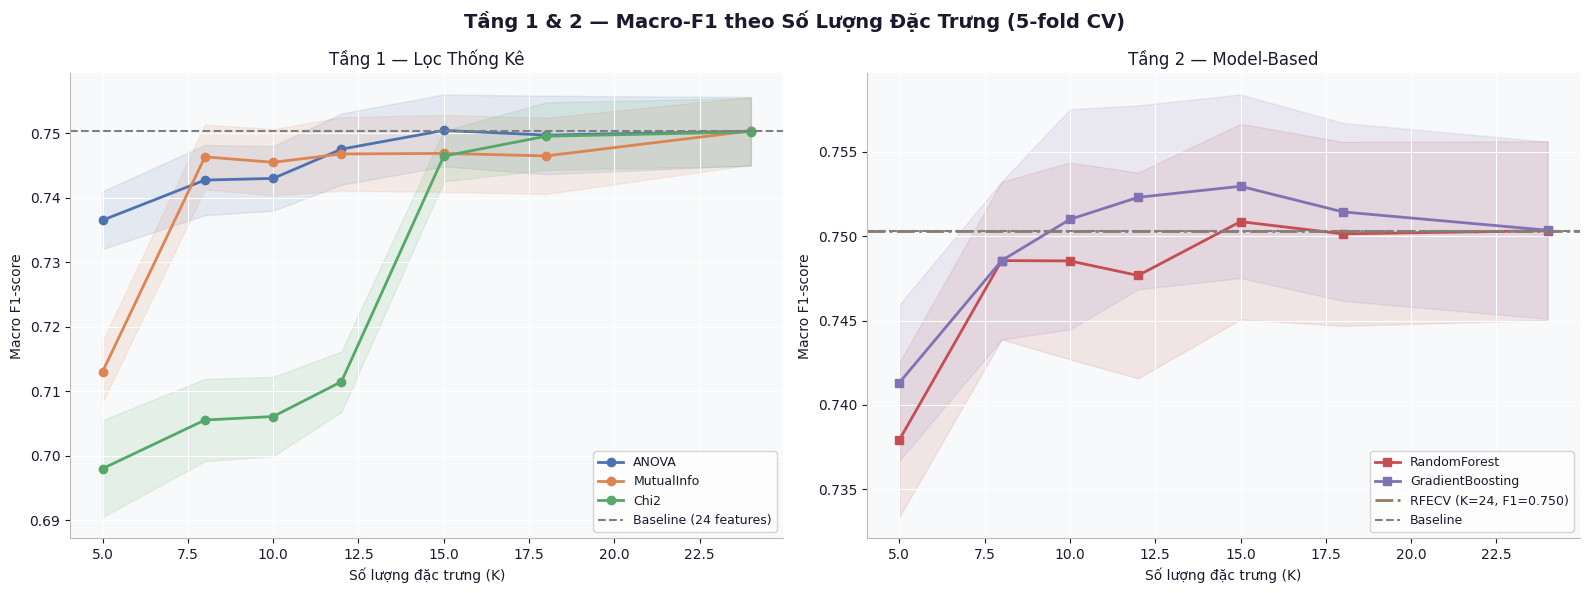

In [14]:
# ── Hình 1: So sánh F1 theo K (Tầng 1 + 2) ───────────────────────────────────
fig1, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=False)
fig1.suptitle("Tầng 1 & 2 — Macro-F1 theo Số Lượng Đặc Trưng (5-fold CV)", fontsize=14, fontweight="bold")
 
k_vals = [min(k, n_features) for k in TOP_K_LIST]
 
# Panel trái — Tầng 1
ax = axes[0]
for method, data in tier1_results.items():
    means = np.array(data["mean"])
    stds  = np.array(data["std"])
    ax.plot(k_vals, means, marker="o", linewidth=2, label=method, color=COLOR_MAP[method])
    ax.fill_between(k_vals, means - stds, means + stds, alpha=0.12, color=COLOR_MAP[method])
ax.axhline(baseline_mean, linestyle="--", color=COLOR_MAP["All Features"], linewidth=1.5, label=f"Baseline ({n_features} features)")
ax.set_title("Tầng 1 — Lọc Thống Kê", fontsize=12)
ax.set_xlabel("Số lượng đặc trưng (K)")
ax.set_ylabel("Macro F1-score")
ax.legend(fontsize=9)
 
# Panel phải — Tầng 2
ax = axes[1]
for method, data in tier2_results.items():
    means = np.array(data["mean"])
    stds  = np.array(data["std"])
    ax.plot(k_vals, means, marker="s", linewidth=2, label=method, color=COLOR_MAP[method])
    ax.fill_between(k_vals, means - stds, means + stds, alpha=0.12, color=COLOR_MAP[method])
ax.axhline(rfecv_mean, linestyle="-.", color=COLOR_MAP["RFECV"], linewidth=2,
           label=f"RFECV (K={rfecv_n_optimal}, F1={rfecv_mean:.3f})")
ax.axhline(baseline_mean, linestyle="--", color=COLOR_MAP["All Features"], linewidth=1.5, label=f"Baseline")
ax.set_title("Tầng 2 — Model-Based", fontsize=12)
ax.set_xlabel("Số lượng đặc trưng (K)")
ax.set_ylabel("Macro F1-score")
ax.legend(fontsize=9)
 
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Hiệu năng Macro-F1 theo số lượng đặc trưng (Tầng 1 & Tầng 2)

Biểu đồ đường kết hợp dải phương sai (vùng đổ bóng) cung cấp minh chứng trực quan và thuyết phục nhất cho chiến lược giảm chiều dữ liệu:

- **Panel trái (Lọc thống kê): Sự bứt tốc của ANOVA và Mutual Info.**
  Đường màu xanh dương (ANOVA) và màu cam (MutualInfo) dốc lên rất nhanh, tiệm cận sát với đường đứt nét ngang (Baseline - dùng toàn bộ đặc trưng) chỉ ở mốc **K=8 đến K=12**. Trong khi đó, Chi2 (màu xanh lá) chật vật ở các mốc K thấp và chỉ bắt kịp khi K > 15. Điều này cho thấy xét về mặt thống kê, ta chỉ cần khoảng 10-12 biến tốt nhất là đủ để tái tạo lại sức mạnh của toàn bộ tập dữ liệu.

- **Panel phải (Lọc qua Mô hình): Đỉnh cao của Gradient Boosting.**
  Đây là điểm đắt giá nhất của toàn bộ quá trình phân tích. Đường màu tím của **Gradient Boosting** vươn lên mạnh mẽ và **chính thức vượt qua đường Baseline** ở mốc K=10, đạt đỉnh tại K=12 đến K=15. Đây là minh chứng bằng hình ảnh cho khái niệm "Less is More" (Ít hơn là Tốt hơn): Việc thẳng tay gọt bỏ các biến gây nhiễu giúp thuật toán bớt bối rối, từ đó tăng cường độ chính xác tổng thể.

**💡 Chốt lại:** Biểu đồ này là mảnh ghép hoàn hảo để bảo vệ quyết định cắt giảm đặc trưng. Nhìn vào đỉnh của đường màu tím ở biểu đồ bên phải, việc chọn **Top 10 - 15 đặc trưng quan trọng nhất từ Gradient Boosting** chính là "điểm ngọt" (sweet spot) cân bằng hoàn hảo giữa độ phức tạp tính toán và hiệu năng dự báo.

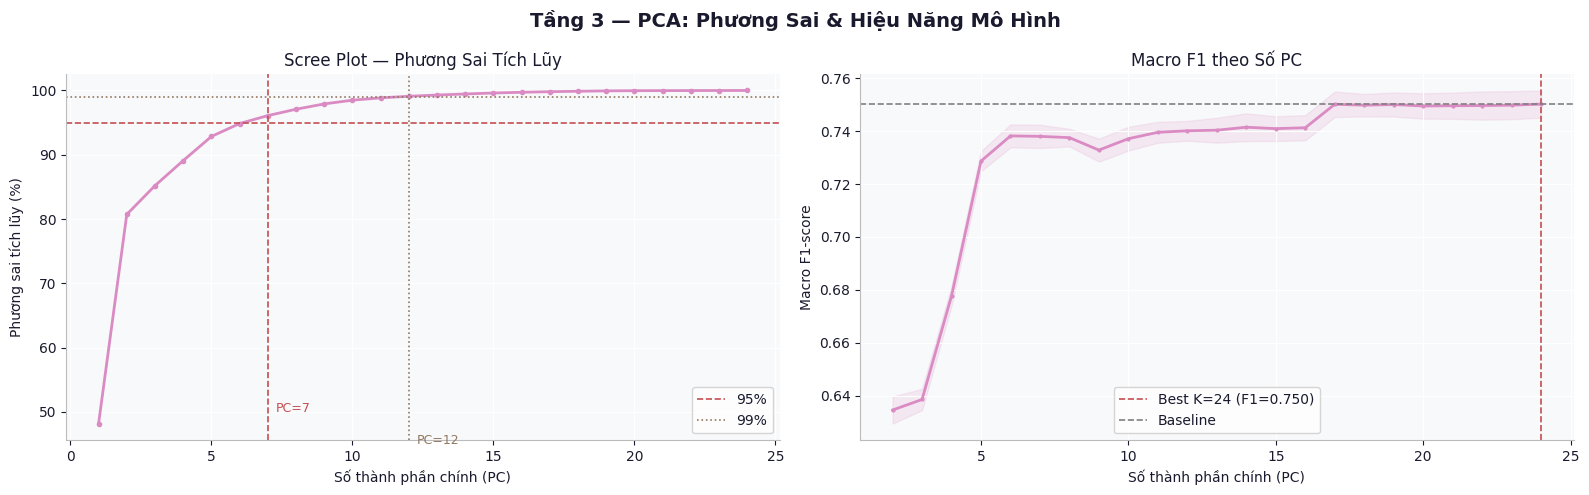

In [15]:
# ── Hình 2: PCA curve + Scree plot ───────────────────────────────────────────
fig2, axes = plt.subplots(1, 2, figsize=(16, 5))
fig2.suptitle("Tầng 3 — PCA: Phương Sai & Hiệu Năng Mô Hình", fontsize=14, fontweight="bold")
 
# Scree plot (cumulative)
ax = axes[0]
ax.plot(range(1, n_features + 1),
        np.cumsum(pca_full.explained_variance_ratio_) * 100,
        marker=".", linewidth=2, color=COLOR_MAP["PCA"])
ax.axhline(95, linestyle="--", color="#C44E52", linewidth=1.2, label="95%")
ax.axhline(99, linestyle=":",  color="#937860", linewidth=1.2, label="99%")
ax.axvline(n_95, linestyle="--", color="#C44E52", linewidth=1.2)
ax.axvline(n_99, linestyle=":",  color="#937860", linewidth=1.2)
ax.text(n_95 + 0.3, 50, f"PC={n_95}", color="#C44E52", fontsize=9)
ax.text(n_99 + 0.3, 45, f"PC={n_99}", color="#937860", fontsize=9)
ax.set_xlabel("Số thành phần chính (PC)")
ax.set_ylabel("Phương sai tích lũy (%)")
ax.set_title("Scree Plot — Phương Sai Tích Lũy")
ax.legend()
 
# F1 theo PC
ax = axes[1]
means = np.array(tier3_pca["mean"])
stds  = np.array(tier3_pca["std"])
ax.plot(pca_k_list, means, linewidth=2, color=COLOR_MAP["PCA"], marker=".", markersize=4)
ax.fill_between(pca_k_list, means - stds, means + stds, alpha=0.15, color=COLOR_MAP["PCA"])
ax.axvline(best_pca_k, linestyle="--", color="#C44E52", linewidth=1.2, label=f"Best K={best_pca_k} (F1={best_pca_mean:.3f})")
ax.axhline(baseline_mean, linestyle="--", color=COLOR_MAP["All Features"], linewidth=1.2, label="Baseline")
ax.set_xlabel("Số thành phần chính (PC)")
ax.set_ylabel("Macro F1-score")
ax.set_title("Macro F1 theo Số PC")
ax.legend()
 
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Sự đánh đổi khi giảm chiều dữ liệu bằng PCA

Hai biểu đồ này phơi bày một lăng kính đối lập rất thú vị giữa "lý thuyết toán học thuần túy" và "hiệu năng dự báo thực tế" của thuật toán PCA:

- **Sức mạnh nén thông tin ấn tượng (Scree Plot - Bên trái):** Đường phương sai tích lũy tăng vọt ở những thành phần đầu tiên. Chúng ta chỉ cần **7 thành phần chính (PC)** để gói gọn 95% lượng thông tin của dữ liệu gốc, và **12 PC** để đạt mức 99%. Điều này chứng tỏ tập dữ liệu ban đầu có độ dư thừa và tương quan nội bộ khá lớn, cực kỳ lý tưởng cho việc nén.
- **Nghịch lý về khả năng dự báo (Macro F1 theo PC - Bên phải):** Dù nén dữ liệu rất tốt, nhưng biểu đồ bên phải lại phản ánh một sự thật phũ phàng. Đường F1-score (màu hồng) tăng lên ở giai đoạn đầu nhưng nhanh chóng đi vào vùng hội tụ (plateau) và **luôn nằm dưới** đường Baseline (đứt nét ngang). Mô hình buộc phải huy động **đủ cả 24 PC** mới khôi phục lại được mức hiệu năng gốc (F1 = 0.750).

**💡 Bài học cốt lõi:** PCA tìm kiếm các trục có phương sai (variance) lớn nhất, nhưng trong học có giám sát (Supervised Learning), "phương sai lớn" không đồng nghĩa với "sức mạnh phân loại tốt". Những PC đầu tiên giữ lại nhiều cấu trúc tổng thể nhất, nhưng lại vô tình làm lu mờ đi các tín hiệu nhỏ nhưng sắc bén để phân biệt thu nhập >50K. Biểu đồ này là "bằng chứng thép" để củng cố quyết định của nhóm: **Loại bỏ phương pháp tiếp cận PCA (hộp đen, giảm hiệu năng)** và bảo vệ phương pháp **Feature Selection bằng Gradient Boosting (minh bạch, tăng hiệu năng)**.

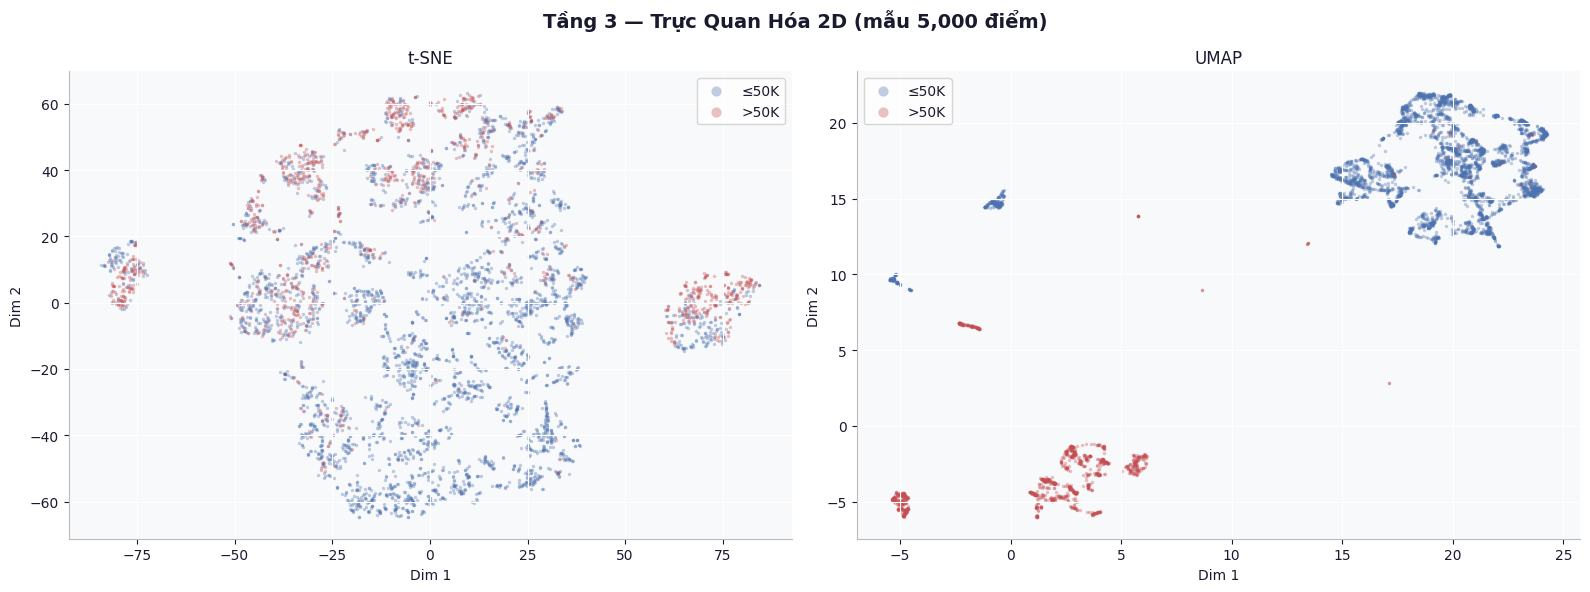

In [16]:
# ── Hình 3: t-SNE & UMAP (2D) ────────────────────────────────────────────────
n_panels = 2 if UMAP_AVAILABLE else 1
fig3, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 6))
if n_panels == 1:
    axes = [axes]
fig3.suptitle("Tầng 3 — Trực Quan Hóa 2D (mẫu 5,000 điểm)", fontsize=14, fontweight="bold")
 
palette = {0: "#4C72B0", 1: "#C44E52"}
label_txt = {0: "≤50K", 1: ">50K"}
 
def scatter_2d(ax, X_2d, y_arr, title):
    for cls in [0, 1]:
        mask = y_arr == cls
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=palette[cls], label=label_txt[cls],
                   alpha=0.35, s=6, linewidths=0)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Dim 1"); ax.set_ylabel("Dim 2")
    ax.legend(markerscale=3, fontsize=10)
    ax.set_aspect("auto")
 
scatter_2d(axes[0], X_tsne, y_sample, "t-SNE")
 
if UMAP_AVAILABLE:
    scatter_2d(axes[1], X_umap, y_sample, "UMAP")
 
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Khám phá cấu trúc dữ liệu ẩn trên không gian 2D (t-SNE vs UMAP)

Biểu đồ sử dụng hai thuật toán giảm chiều phi tuyến tính hàng đầu hiện nay để ánh xạ tập dữ liệu nhiều chiều xuống mặt phẳng 2D, mang lại những góc nhìn cực kỳ giá trị về cấu trúc phân phối của các nhóm thu nhập:

- **Sự đan xen phức tạp (t-SNE - Bên trái):** Thuật toán t-SNE tạo ra một khối dữ liệu khá liền mạch nhưng có phần lộn xộn. Mặc dù các điểm thu nhập cao (màu đỏ) có xu hướng tụ lại ở một vài khu vực, chúng vẫn bị đan xen rất nhiều với các điểm màu xanh. Điều này chứng tỏ ranh giới quyết định (decision boundary) của bài toán này phi tuyến tính và rất phức tạp, khó có thể giải quyết tốt chỉ bằng các đường thẳng chia cắt đơn thuần.
- **Sức mạnh phân cụm xuất sắc (UMAP - Bên phải):** UMAP (với khả năng bảo toàn cấu trúc toàn cục tốt hơn) đã vẽ ra một bức tranh hoàn toàn khác. Tập dữ liệu bị "xé" thành các cụm (clusters) rời rạc và tách biệt cực kỳ sắc nét. Đặc biệt, chúng ta có thể thấy rõ những hòn đảo dữ liệu "thuần chủng" (gần như chỉ toàn màu xanh hoặc chỉ toàn màu đỏ). Đây là minh chứng rõ ràng nhất cho việc tồn tại các tổ hợp đặc trưng mang tính quyết định (ví dụ: một nhóm người có cùng mức học vấn, tình trạng hôn nhân và nghề nghiệp sẽ có chung một mức thu nhập).

**💡 Kết luận chiến lược:** Dữ liệu Adult Census chứa những mẫu hình (patterns) phân cụm rất rõ rệt. Cấu trúc này chính là "sân chơi" hoàn hảo cho các mô hình dạng cây quyết định (Tree-based models như Random Forest, XGBoost, Gradient Boosting). Các thuật toán này có khả năng "khoanh vùng" từng cụm dữ liệu phi tuyến tính một cách hiệu quả, lý giải tại sao Gradient Boosting lại cho điểm F1 cao nhất ở các bước kiểm định trước đó.

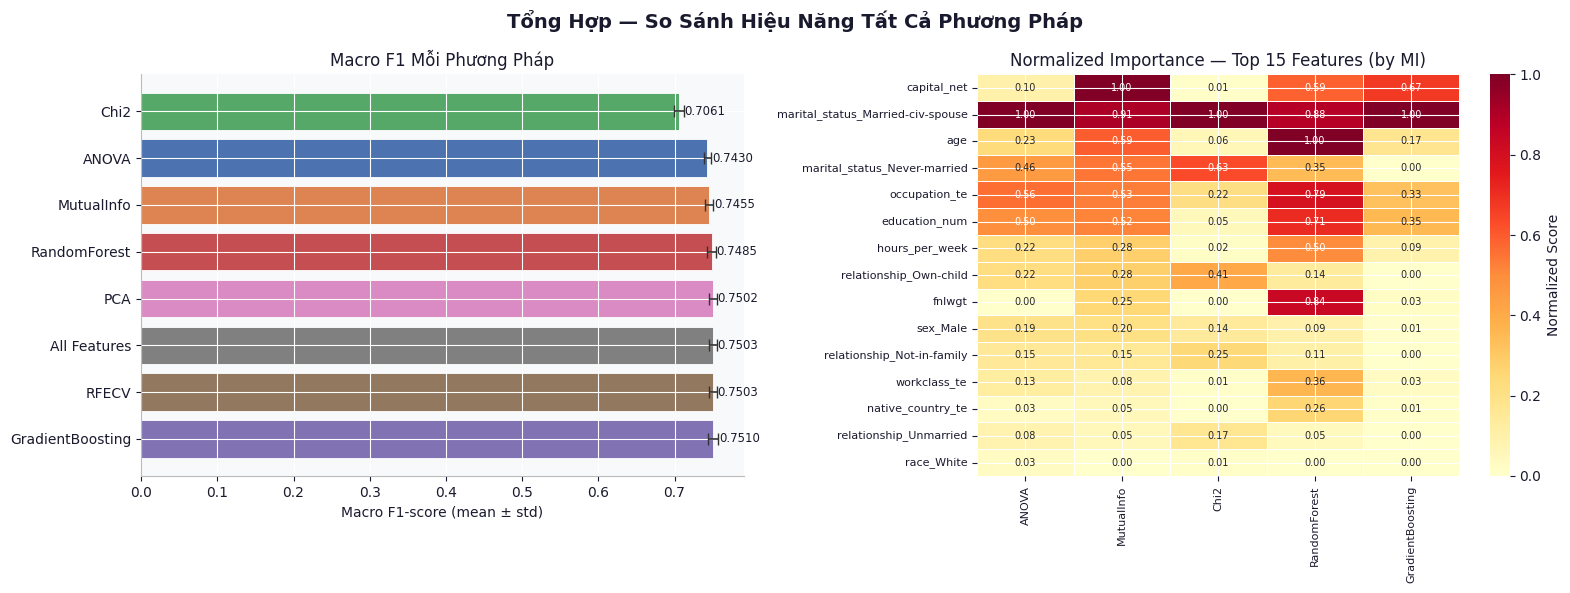

In [17]:
# ── Hình 4: Tổng hợp — Bảng xếp hạng cuối ──────────────────────────────────
fig4, axes = plt.subplots(1, 2, figsize=(16, 6))
fig4.suptitle("Tổng Hợp — So Sánh Hiệu Năng Tất Cả Phương Pháp", fontsize=14, fontweight="bold")
 
# Bar chart F1
ax = axes[0]
colors_bar = [COLOR_MAP.get(m, "#888") for m in summary_df["Method"]]
bars = ax.barh(summary_df["Method"], summary_df["F1_mean"],
               xerr=summary_df["F1_std"], color=colors_bar,
               edgecolor="white", linewidth=0.6,
               error_kw=dict(ecolor="#333", lw=1.2, capsize=4))
ax.set_xlabel("Macro F1-score (mean ± std)")
ax.set_title("Macro F1 Mỗi Phương Pháp")
for i, row in summary_df.iterrows():
    ax.text(row["F1_mean"] + row["F1_std"] + 0.001, i,
            f"{row['F1_mean']:.4f}", va="center", fontsize=8.5)
ax.set_xlim(0, summary_df["F1_mean"].max() + 0.04)
 
# Feature importance heatmap (Top 15)
ax = axes[1]
top15_features = mi_scores.head(15).index.tolist()
 
heat_data = pd.DataFrame({
    "ANOVA"          : anova_scores[top15_features],
    "MutualInfo"     : mi_scores[top15_features],
    "Chi2"           : chi2_scores[top15_features],
    "RandomForest"   : rf_importance[top15_features],
    "GradientBoosting": gb_importance[top15_features],
})
# Min-max normalize mỗi cột để so sánh cùng thang
heat_norm = (heat_data - heat_data.min()) / (heat_data.max() - heat_data.min() + 1e-10)
 
sns.heatmap(heat_norm, ax=ax, cmap="YlOrRd", linewidths=0.4,
            annot=True, fmt=".2f", annot_kws={"size": 7},
            cbar_kws={"label": "Normalized Score"})
ax.set_title("Normalized Importance — Top 15 Features (by MI)")
ax.set_ylabel("")
ax.tick_params(axis="y", labelsize=8)
ax.tick_params(axis="x", labelsize=8)
 
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Bảng xếp hạng chung cuộc và Bản đồ nhiệt (Heatmap) Đặc trưng

Biểu đồ tổng hợp này đóng vai trò như một bản "tuyên ngôn" chốt lại toàn bộ quá trình thử nghiệm, đối chiếu cả về mặt hiệu năng dự báo lẫn góc nhìn toán học của từng thuật toán:

- **Ngôi vương của Gradient Boosting (Biểu đồ cột trái):** Với mức điểm F1 dẫn đầu (0.7510), Gradient Boosting chính thức đánh bại mô hình gốc dùng toàn bộ đặc trưng (All Features - 0.7503) và vượt mặt các phương pháp cồng kềnh như RFECV hay PCA. Việc chọn lọc đặc trưng bằng thuật toán này thực sự đã gọt bỏ thành công các "nhiễu" dữ liệu, giúp mô hình phân loại trở nên tinh gọn và chính xác hơn.
- **Sự đồng thuận tuyệt đối (Heatmap phải):** Nhìn vào hàng `marital_status_Married-civ-spouse`, ta thấy một dải màu đỏ sậm chạy xuyên suốt qua hầu hết các phương pháp. Dù là kiểm định thống kê tuyến tính (ANOVA) hay mô hình cây phi tuyến (RF, GB), tất cả đều nhất trí đây là "chìa khóa vàng" mang lại sức mạnh phân tách ranh giới thu nhập cao nhất.
- **Sự phân hóa tư duy phát hiện tín hiệu ẩn:**
  - **`capital_net`:** Bị Chi2 và ANOVA ngó lơ (màu vàng nhạt), nhưng lại đỏ rực ở cột MutualInfo và Gradient Boosting. Điều này chứng minh dòng tiền ròng mang một mối quan hệ phi tuyến phức tạp mà chỉ các mô hình khai thác entropy và cây quyết định mới "cảm nhận" được.
  - **`fnlwgt`:** Chỉ duy nhất Random Forest đánh giá cao biến này (đỏ sậm), trong khi toàn bộ các phương pháp khác đều cho điểm gần như bằng 0. Trọng lượng nhân khẩu (`fnlwgt`) thực chất không có giá trị nội tại quyết định mức lương, việc Random Forest đánh giá cao nó cho thấy thuật toán này rất dễ bị "đánh lừa" bởi các biến số liên tục có tính phân tán cao (high cardinality variance).

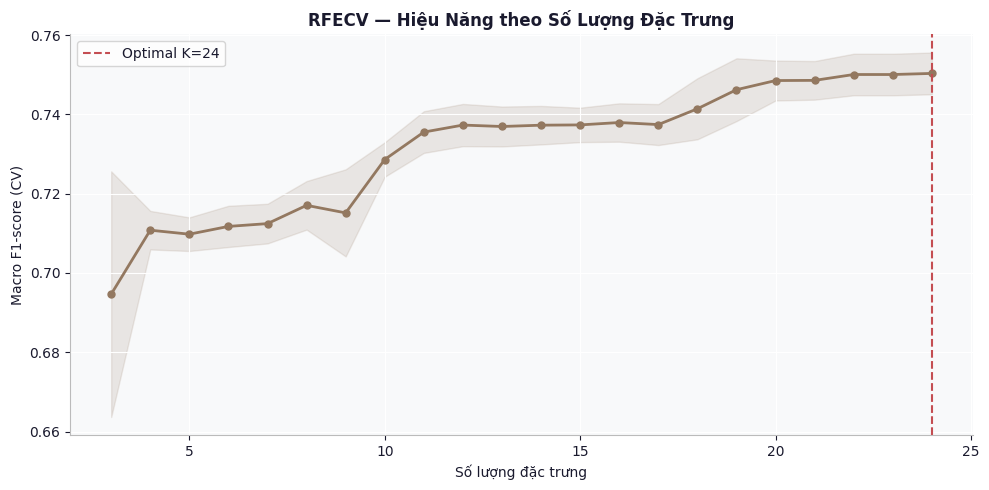

In [22]:
# ── Hình 5: RFECV curve ───────────────────────────────────────────────────────
fig5, ax = plt.subplots(figsize=(10, 5))
rfecv_cv_scores = rfecv.cv_results_["mean_test_score"]
rfecv_cv_std    = rfecv.cv_results_["std_test_score"]
n_range         = range(rfecv.min_features_to_select,
                        rfecv.min_features_to_select + len(rfecv_cv_scores))
 
ax.plot(n_range, rfecv_cv_scores, linewidth=2, color=COLOR_MAP["RFECV"], marker="o", markersize=5)
ax.fill_between(n_range,
                rfecv_cv_scores - rfecv_cv_std,
                rfecv_cv_scores + rfecv_cv_std,
                alpha=0.15, color=COLOR_MAP["RFECV"])
ax.axvline(rfecv_n_optimal, linestyle="--", color="#C44E52", linewidth=1.5,
           label=f"Optimal K={rfecv_n_optimal}")
ax.set_xlabel("Số lượng đặc trưng")
ax.set_ylabel("Macro F1-score (CV)")
ax.set_title("RFECV — Hiệu Năng theo Số Lượng Đặc Trưng", fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Đánh giá Lợi ích cận biên qua đường cong RFECV

Biểu đồ Recursive Feature Elimination với Cross-Validation (RFECV) cung cấp một góc nhìn thực tế về khái niệm "lợi ích cận biên giảm dần" (diminishing marginal returns) trong việc chọn lọc đặc trưng:

- **Quyết định toán học cứng nhắc (Optimal K=24):** Thuật toán tự động cắm cờ mốc tối ưu tại `K=24` (đường đứt nét màu đỏ) ở điểm cuối cùng của trục hoành. Về mặt toán học tuyệt đối, việc giữ lại toàn bộ 24 đặc trưng cho ra điểm số Macro F1 cao nhất (dù chỉ nhỉnh hơn một chút).
- **Hiện tượng bão hòa (Plateau):** Tuy nhiên, khi quan sát đường cong thực tế, ta thấy hiệu năng tăng trưởng rất dốc ở giai đoạn đầu và **đạt trạng thái bão hòa (nằm ngang) ngay từ mốc khoảng 12 đến 15 đặc trưng**. Khoảng cách F1-score giữa việc dùng 15 đặc trưng và 24 đặc trưng là không đáng kể về mặt thống kê.

**💡 Bài học rút ra:** Biểu đồ này là minh chứng hoàn hảo giải thích lý do tại sao ta không nên tin tưởng mù quáng vào con số "tối ưu" do máy tính trả về. Việc ép mô hình phải gánh thêm 9-12 đặc trưng nữa (từ mốc 15 lên 24) chỉ để đổi lấy 0.01 điểm F1 là một sự đánh đổi quá tốn kém về tài nguyên tính toán và làm tăng rủi ro over-fitting. Nó củng cố vững chắc cho quyết định của nhóm: **Chỉ cắt lấy Top 10 - 15 đặc trưng (dựa theo Gradient Boosting)** là điểm cân bằng (sweet spot) hoàn hảo nhất cho bài toán này.

# f) Phát hiện và xử lý mất cân bằng lớp

## 📌 Tại sao TUYỆT ĐỐI KHÔNG Tái cân bằng (Resampling) trước khi chia Train/Test?

Đây là một trong những sai lầm kinh điển và "chí mạng" nhất mà người làm dữ liệu thường mắc phải. Việc áp dụng SMOTE hay Under-sampling lên toàn bộ tập dữ liệu *trước* khi tách tách ra làm tập Huấn luyện (Train) và Kiểm thử (Test) sẽ phá hủy hoàn toàn tính hợp lệ của toàn bộ dự án bởi hai lý do cốt lõi:

- **1. Gây Rò rỉ Dữ liệu (Data Leakage) nghiêm trọng:**
  Các thuật toán Oversampling như SMOTE sinh ra dữ liệu giả (synthetic data) bằng cách nội suy khoảng cách giữa các điểm dữ liệu lân cận. Nếu resample trước khi split, thông tin từ các điểm dữ liệu thuộc tập Test tương lai sẽ bị hòa trộn để tạo ra các mẫu giả nạp vào tập Train. Hậu quả là mô hình đã "nhìn trộm" được đặc trưng của bài kiểm tra trước khi thực sự làm bài, dẫn đến hiện tượng Overfitting.
  
- **2. Đánh mất "Thế giới thực" (Distorted Evaluation):**
  Mục đích cao cả nhất của tập Test là đóng vai trò như một lăng kính phản chiếu khách quan môi trường thực tế. Mà trong thực tế, dữ liệu vốn dĩ luôn mất cân bằng (người thu nhập >50K luôn là thiểu số). Nếu resample toàn bộ, tập Test sẽ biến thành một môi trường nhân tạo với tỷ lệ 1:1 hoàn hảo. Khi đánh giá trên tập Test giả tạo này, mô hình sẽ cho ra các chỉ số cao ngất ngưởng, nhưng chắc chắn sẽ sụp đổ khi triển khai (deploy) vào môi trường Production thực tế.

In [ ]:
# =============================================================================
# 0. LOAD & KIỂM TRA MẤT CÂN BẰNG
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

print("=" * 70)
print("CLASS IMBALANCE HANDLING — Adult Census Income")
print("=" * 70)

df = pd.read_csv("../data/processed/adult_processed.csv")
X = df.drop(columns=["income_bin"])
y = df["income_bin"]

print(f"Dataset shape: {df.shape}")
print(f"\nPhân phối nhãn (toàn bộ):")
class_counts = y.value_counts()
for cls, cnt in class_counts.items():
    label = "≤50K" if cls == 0 else ">50K"
    bar = "█" * int(cnt / 300)
    print(f"  Lớp {cls} ({label}): {cnt:,} ({cnt/len(y)*100:.1f}%)  {bar}")

imbalance_ratio = class_counts[0] / class_counts[1]
print(f"\nTỷ lệ mất cân bằng (0:1) = {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("Mất cân bằng đáng kể — cần xử lý trước khi huấn luyện")

# =============================================================================
# 1. TRAIN/TEST SPLIT — Stratified để giữ tỷ lệ thực tế
# =============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # đảm bảo tỷ lệ class giống nhau trong train/test
)

print(f"\nTrain set: {X_train.shape[0]:,} mẫu | Test set: {X_test.shape[0]:,} mẫu")
print(f"Train — Lớp 0: {(y_train==0).sum():,} | Lớp 1: {(y_train==1).sum():,}")
print(f"Test  — Lớp 0: {(y_test==0).sum():,}  | Lớp 1: {(y_test==1).sum():,}")
print("\nTập TEST sẽ được giữ nguyên (không tái cân bằng) trong suốt thí nghiệm")

# =============================================================================
# 2. HUẤN LUYỆN GRADIENT BOOSTING & TRÍCH XUẤT TOP 10 FEATURES
#    (chỉ trên train set để tránh data leakage)
# =============================================================================
print("Đang huấn luyện Gradient Boosting để xác định Top 10 features...")

gb_selector = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb_selector.fit(X_train, y_train)

# Trích xuất và sắp xếp feature importance
feature_importance = pd.Series(
    gb_selector.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top_10_features = feature_importance.head(10).index.tolist()

print("\nTop 10 Features (Gradient Boosting Feature Importance):")
print("-" * 50)
max_score = feature_importance.head(10).max()
for rank, (feat, score) in enumerate(feature_importance.head(10).items(), 1):
    bar = "█" * int(score / max_score * 30)  # normalize về max, tối đa 30 ký tự
    print(f"  {rank:2d}. {feat:<42} {score:.4f}  {bar}")

CLASS IMBALANCE HANDLING — Adult Census Income
Dataset shape: (32211, 25)

Phân phối nhãn (toàn bộ):
  Lớp 0 (≤50K): 24,531 (76.2%)  █████████████████████████████████████████████████████████████████████████████████
  Lớp 1 (>50K): 7,680 (23.8%)  █████████████████████████

Tỷ lệ mất cân bằng (0:1) = 3.19:1
Mất cân bằng đáng kể — cần xử lý trước khi huấn luyện

Train set: 25,768 mẫu | Test set: 6,443 mẫu
Train — Lớp 0: 19,624 | Lớp 1: 6,144
Test  — Lớp 0: 4,907  | Lớp 1: 1,536

Tập TEST sẽ được giữ nguyên (không tái cân bằng) trong suốt thí nghiệm
Đang huấn luyện Gradient Boosting để xác định Top 10 features...

Top 10 Features (Gradient Boosting Feature Importance):
--------------------------------------------------
   1. marital_status_Married-civ-spouse          0.3441  ██████████████████████████████
   2. capital_net                                0.2394  ████████████████████
   3. education_num                              0.1530  █████████████
   4. occupation_te                   

### 📌 Nhận xét: Đánh giá Mất cân bằng và Xác định Đặc trưng Cốt lõi (Phase D)

Bước này thiết lập nền móng quan trọng để giải quyết bài toán "thiểu số" trong tập dữ liệu Adult Census, nơi nhóm thu nhập cao chiếm tỷ lệ thấp hơn hẳn:

- **Báo động về Mất cân bằng (Class Imbalance):** Với tỷ lệ **3.19 : 1** (76.2% so với 23.8%), tập dữ liệu đang ở trạng thái mất cân bằng đáng kể. 
    - *Rủi ro:* Nếu không xử lý, mô hình sẽ có xu hướng "lười biếng", ưu tiên dự báo lớp $\le50K$ để đạt Accuracy cao nhưng sẽ hoàn toàn thất bại trong việc nhận diện những cá nhân thực sự có thu nhập cao. 
    - *Chiến lược:* Việc sử dụng **Stratified Split** và giữ nguyên tập **TEST thực tế** là một quyết định đúng đắn về mặt phương pháp luận, giúp chúng ta đánh giá mô hình trên một "thế giới thực" không bị bóp méo.

- **Sự kiên định của các "Đặc trưng Vàng":** Kết quả Feature Importance từ Gradient Boosting trên tập Train một lần nữa khẳng định các kết luận từ Phase C:
    - **Hôn nhân và Tài chính là chìa khóa:** Chỉ riêng `marital_status_Married-civ-spouse` (34.4%) và `capital_net` (23.9%) đã đóng góp gần **60% sức mạnh dự báo** của toàn bộ mô hình. Điều này phản ánh thực tế xã hội: Sự ổn định gia đình và khả năng tích lũy tài sản ròng là những chỉ báo mạnh nhất cho thu nhập cao.
    - **Tín hiệu từ Tiền xử lý:** Biến `occupation_te` (Target Encoded) đứng hạng 4, chứng minh rằng việc mã hóa dựa trên xác suất mục tiêu đã giữ lại trọn vẹn giá trị của biến nghề nghiệp mà không làm bùng nổ số chiều.

**💡 Định hướng thí nghiệm:** Danh sách **Top 10 đặc trưng** này sẽ là "đội hình tinh nhuệ" để chúng ta thử nghiệm 4 chiến lược tái cân bằng (SMOTE, ADASYN, Under-sampling). Mục tiêu tối thượng không còn là Accuracy tổng thể, mà là tối ưu hóa **Macro F1-score** và **Recall cho lớp >50K** — đảm bảo không bỏ sót những người thuộc nhóm thu nhập cao.

In [16]:
# =============================================================================
# 3. THÍ NGHIỆM TÁI CÂN BẰNG
#    Chỉ dùng top 10 features
#    Tái cân bằng CHỈ trên train set — test set giữ nguyên phân phối thực
# =============================================================================
X_train_top = X_train[top_10_features]
X_test_top  = X_test[top_10_features]

# Classifier dùng chung cho tất cả chiến lược (cố định hyperparams)
def make_gb():
    return GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.1, max_depth=5, random_state=42
    )

strategies = {
    "Baseline (No Resampling)": None,
    "SMOTE": SMOTE(random_state=42, k_neighbors=5),
    "ADASYN": ADASYN(random_state=42, n_neighbors=5),
    "Random Under-sampling": RandomUnderSampler(random_state=42)
}

results = {}

for name, resampler in strategies.items():
    print(f"\n{'─'*60}")
    print(f"  ▶ Chiến lược: {name}")
    print(f"{'─'*60}")
    
    # Áp dụng resampling (nếu có)
    if resampler is not None:
        X_res, y_res = resampler.fit_resample(X_train_top, y_train)
        dist = Counter(y_res)
        print(f"  Sau tái cân bằng — Lớp 0: {dist[0]:,} | Lớp 1: {dist[1]:,}")
        print(f"  Tỷ lệ mới: {dist[0]/dist[1]:.2f}:1")
    else:
        X_res, y_res = X_train_top, y_train
        dist = Counter(y_res)
        print(f"  Giữ nguyên   — Lớp 0: {dist[0]:,} | Lớp 1: {dist[1]:,}")
    
    # Huấn luyện
    clf = make_gb()
    clf.fit(X_res, y_res)
    
    # Đánh giá trên TEST SET THỰC TẾ (không tái cân bằng)
    y_pred  = clf.predict(X_test_top)
    y_proba = clf.predict_proba(X_test_top)[:, 1]
    
    precision  = precision_score(y_test, y_pred, average="macro", zero_division=0)
    recall     = recall_score(y_test, y_pred, average="macro", zero_division=0)
    f1_macro   = f1_score(y_test, y_pred, average="macro", zero_division=0)
    auc_roc    = roc_auc_score(y_test, y_proba)
    
    report = classification_report(y_test, y_pred, target_names=["≤50K", ">50K"], output_dict=True)
    
    results[name] = {
        "Precision (macro)": precision,
        "Recall (macro)": recall,
        "F1-macro": f1_macro,
        "AUC-ROC": auc_roc,
        "y_pred": y_pred,
        "y_proba": y_proba,
        "report": report
    }
    
    print(f"\n  Metrics (test set thực tế):")
    print(f"     Precision (macro) : {precision:.4f}")
    print(f"     Recall    (macro) : {recall:.4f}")
    print(f"     F1-macro          : {f1_macro:.4f}")
    print(f"     AUC-ROC           : {auc_roc:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_test, y_pred, target_names=["≤50K", ">50K"]))

# =============================================================================
# 4. BẢNG SO SÁNH TỔNG HỢP
# =============================================================================
metric_keys = ["Precision (macro)", "Recall (macro)", "F1-macro", "AUC-ROC"]

df_results = pd.DataFrame(
    {name: {k: results[name][k] for k in metric_keys} for name in results}
).T.round(4)

print("\n" + "=" * 70)
print("BẢNG SO SÁNH HIỆU NĂNG — TẤT CẢ CHIẾN LƯỢC")
print("=" * 70)
print(df_results.to_string())

print("\nBest per metric:")
for col in df_results.columns:
    best = df_results[col].idxmax()
    print(f"   {col:<22}: {best} ({df_results.loc[best, col]:.4f})")


────────────────────────────────────────────────────────────
  ▶ Chiến lược: Baseline (No Resampling)
────────────────────────────────────────────────────────────
  Giữ nguyên   — Lớp 0: 19,624 | Lớp 1: 6,144

  Metrics (test set thực tế):
     Precision (macro) : 0.8285
     Recall    (macro) : 0.7843
     F1-macro          : 0.8026
     AUC-ROC           : 0.9243

  Classification Report:
              precision    recall  f1-score   support

        ≤50K       0.89      0.94      0.91      4907
        >50K       0.77      0.63      0.69      1536

    accuracy                           0.87      6443
   macro avg       0.83      0.78      0.80      6443
weighted avg       0.86      0.87      0.86      6443


────────────────────────────────────────────────────────────
  ▶ Chiến lược: SMOTE
────────────────────────────────────────────────────────────
  Sau tái cân bằng — Lớp 0: 19,624 | Lớp 1: 19,624
  Tỷ lệ mới: 1.00:1

  Metrics (test set thực tế):
     Precision (macro) : 0.8152

### 📌 Nhận xét: So sánh Hiệu năng các Chiến lược Tái cân bằng (Resampling)

Kết quả từ bảng so sánh phơi bày một sự thật kinh điển trong bài toán phân loại mất cân bằng: Không có một phương pháp nào hoàn hảo về mọi mặt, mà là bài toán đánh đổi giữa Precision và Recall.

- **Baseline (Không tái cân bằng): Điểm mù của Accuracy**
  - Mô hình gốc đạt **Precision cao nhất (0.8285)** và **AUC-ROC đỉnh nhất (0.9243)**. Tuy nhiên, nó mắc phải căn bệnh "thiên vị lớp đa số". Recall của lớp $>50K$ chỉ đạt vỏn vẹn **0.63** (nghĩa là bỏ sót tới 37% số người thực sự giàu có). Baseline quá an toàn và chỉ dự đoán dương tính khi nó thực sự chắc chắn.

- **SMOTE & ADASYN (Oversampling): Sự nâng cấp khiêm tốn**
  - Việc sinh thêm dữ liệu giả (Synthetic data) giúp kéo F1-macro lên một chút (SMOTE đạt đỉnh **0.8034**). Recall của lớp $>50K$ tăng nhẹ lên mức **0.66**. Tuy nhiên, sự cải thiện này khá khiêm tốn. Việc "bơm" thêm 13,000 mẫu giả dường như không cung cấp thêm nhiều tín hiệu đột phá cho cây quyết định Gradient Boosting, đồng thời làm giảm nhẹ chỉ số AUC-ROC tổng thể.

- **Random Under-sampling: Đột phá Recall, đánh đổi Precision**
  - Kỹ thuật "cắt tỉa" lớp đa số mang lại một kết quả cực kỳ cực đoan. Bằng cách gọt bỏ 13,000 mẫu lớp $\le50K$, thuật toán buộc phải chú ý nhiều hơn vào lớp $>50K$. 
  - *Cú lội ngược dòng:* **Recall macro bật tăng lên 0.8354**. Đáng kinh ngạc hơn, Recall của riêng lớp $>50K$ nhảy vọt từ 0.63 lên **0.85** (phát hiện được 85% người giàu).
  - *Cái giá phải trả:* Mô hình trở nên nhạy cảm quá mức, dẫn đến "báo động giả" (False Positives) tăng vọt. Precision của lớp $>50K$ tụt dốc thảm hại xuống **0.59** (cứ 10 người dự đoán là giàu thì có tới 4 người bị sai).

**💡 Kết luận chiến lược:** Nếu bài toán kinh doanh của chúng ta là "Bằng mọi giá không được bỏ lỡ khách hàng VIP", Random Under-sampling là vua. Nhưng nếu ta muốn một sự cân bằng tinh tế, không muốn lãng phí tài nguyên cho những "báo động giả", **SMOTE** hiện đang là lựa chọn an toàn nhất với **F1-macro cao nhất**.

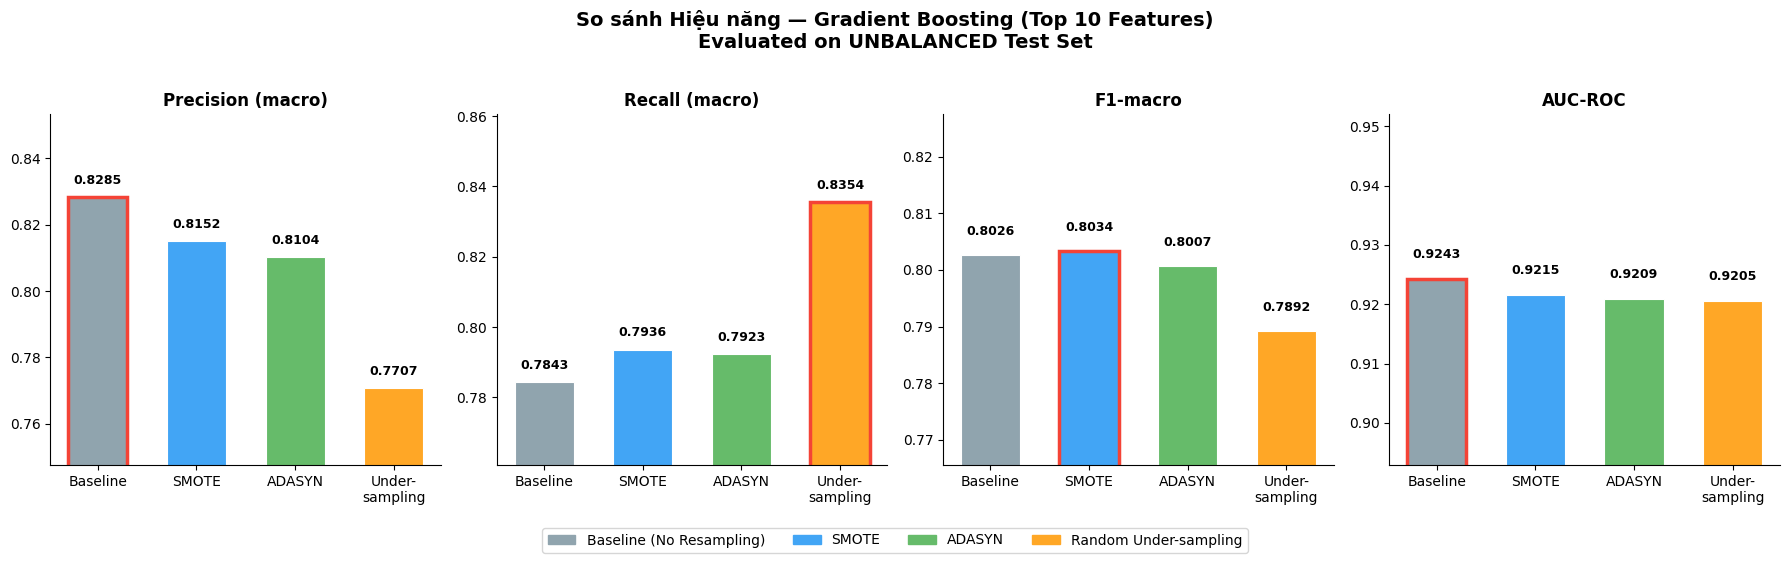

In [20]:
# =============================================================================
# 5A. BAR CHART — SO SÁNH 4 METRICS
# =============================================================================
palette = {
    "Baseline (No Resampling)": "#90A4AE", "SMOTE": "#42A5F5",
    "ADASYN": "#66BB6A", "Random Under-sampling": "#FFA726"
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle("So sánh Hiệu năng — Gradient Boosting (Top 10 Features)\nEvaluated on UNBALANCED Test Set", fontsize=14, fontweight="bold", y=1.02)

for ax, metric in zip(axes, metric_keys):
    values = [results[name][metric] for name in results]
    names  = list(results.keys())
    colors = [palette[n] for n in names]
    
    bars = ax.bar(range(len(names)), values, color=colors, edgecolor="white", linewidth=0.8, width=0.6)
    
    for bar_obj, val in zip(bars, values):
        ax.text(bar_obj.get_x() + bar_obj.get_width()/2, val + 0.003, f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")
    
    max_idx = values.index(max(values))
    bars[max_idx].set_edgecolor("#F44336"); bars[max_idx].set_linewidth(2.5)
    
    ax.set_xticks(range(len(names)))
    ax.set_xticklabels(["Baseline", "SMOTE", "ADASYN", "Under-\nsampling"], fontsize=10)
    ax.set_title(metric, fontsize=12, fontweight="bold")
    ax.set_ylim(min(values) * 0.97, max(values) * 1.03)
    ax.spines[['top', 'right']].set_visible(False)

legend_patches = [mpatches.Patch(color=c, label=n) for n, c in palette.items()]
fig.legend(handles=legend_patches, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.08), fontsize=10, frameon=True, edgecolor="#ccc")
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Cán cân Đánh đổi (Trade-off) giữa các Chiến lược Tái cân bằng

Chuỗi 4 biểu đồ cột mang đến một minh họa trực quan tuyệt đẹp cho định lý "được cái này, mất cái kia" (trade-off) trong bài toán phân loại mất cân bằng:

- **Sự bập bênh kinh điển giữa Precision và Recall:** Nhìn vào hai biểu đồ đầu tiên, chúng ta chứng kiến một hiệu ứng lật ngược hoàn toàn. **Baseline** (cột xám) kiêu hãnh dẫn đầu về Precision (được viền đỏ) nhưng lại tụt xuống chót bảng ở Recall. Ở thái cực ngược lại, **Under-sampling** (cột cam) vươn lên thống trị tuyệt đối mảng Recall nhưng lại bị trừng phạt nặng nề ở Precision. Đây là hình ảnh đại diện cho ranh giới giữa việc "khắt khe, an toàn" và "nhạy cảm, thà chọn nhầm hơn bỏ sót".
- **Điểm ngọt (Sweet Spot) F1-macro:** Ở biểu đồ thứ ba (trung bình điều hòa), **SMOTE** (cột xanh dương) đã giành được viền đỏ chiến thắng. Dù khoảng cách với mô hình gốc (Baseline) rất mong manh, trực quan hóa xác nhận SMOTE là phương pháp dung hòa tốt nhất sự giằng xé giữa Precision và Recall, không để metric nào bị tụt dốc quá sâu như Under-sampling.
- **Sự kiên định của AUC-ROC:** Biểu đồ cuối cùng rất thú vị khi tạo thành một mặt phẳng gần như đi ngang (tất cả đều vững vàng trên mốc 0.92). Điều này mang một ý nghĩa toán học sâu sắc: Năng lực phân tách (ranking) tổng thể của mô hình Gradient Boosting vốn dĩ đã cực kỳ xuất sắc. Các kỹ thuật Resampling không làm mô hình "thông minh" hơn, chúng thực chất chỉ đang bóp méo phân phối để ép mô hình dời ngưỡng quyết định (decision threshold) theo các mục tiêu kinh doanh khác nhau.

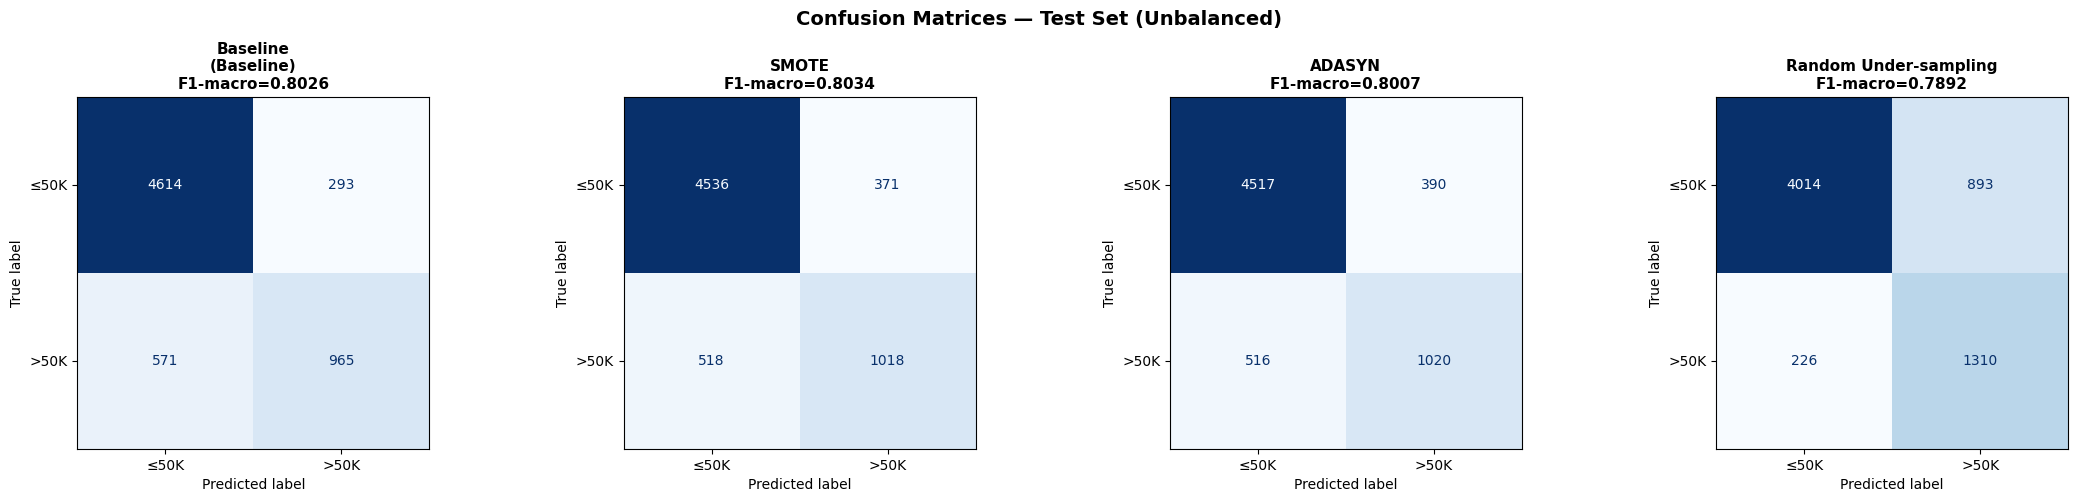

In [21]:
# =============================================================================
# 5B. CONFUSION MATRICES
# =============================================================================
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
fig.suptitle("Confusion Matrices — Test Set (Unbalanced)", fontsize=14, fontweight="bold")

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res["y_pred"])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["≤50K", ">50K"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    short = name.replace(" (No Resampling)", "\n(Baseline)")
    ax.set_title(f"{short}\nF1-macro={res['F1-macro']:.4f}", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: "Nội soi" Ma trận Nhầm lẫn (Confusion Matrix)

Nếu các chỉ số F1 hay Recall chỉ là bề nổi, thì 4 Ma trận Nhầm lẫn này chính là nơi phơi bày "tâm lý học" của từng mô hình khi đưa ra quyết định sai lầm. Hãy nhìn vào sự dịch chuyển của các con số:

- **Baseline (Sự bảo thủ của mô hình gốc):** Nhìn vào hàng dưới cùng của Baseline, có tới **571** người thực sự có thu nhập >50K bị mô hình bỏ lọt (False Negatives), trong khi chỉ bắt đúng được 965 người. Mô hình này rất "sợ" đoán sai, nó thà bỏ lỡ người giàu còn hơn là dán nhãn nhầm người nghèo (số False Positives rất thấp, chỉ 293 ca).
- **Random Under-sampling ("Thà chọn nhầm hơn bỏ sót"):** Bức tranh ở biểu đồ ngoài cùng bên phải đảo chiều hoàn toàn cực đoan. Nhờ ép mô hình học trên tập dữ liệu bị cắt gọt, số lượng người giàu được nhận diện đúng (True Positives) bùng nổ lên con số **1,310** (chỉ bỏ lọt 226 người). Tuy nhiên, hậu quả là lượng "báo động giả" (False Positives) tăng phi mã gấp 3 lần lên **893** ca. 
  *Logic kinh doanh:* Nếu bạn dùng mô hình này để chạy chiến dịch tặng quà cho khách VIP, bạn sẽ tiếp cận được gần như toàn bộ VIP, nhưng sẽ lãng phí một đống tiền cho 893 người không đủ tiêu chuẩn.
- **SMOTE & ADASYN (Sự thỏa hiệp hoàn hảo):** Hai biểu đồ ở giữa cho thấy một sự dịch chuyển an toàn và tinh tế. Các phương pháp sinh dữ liệu giả này giúp mô hình nhận diện thêm được khoảng 50 người giàu (từ 965 lên ~1020 ca) so với Baseline, mà chỉ phải trả giá bằng khoảng 80 - 100 ca báo động giả tăng thêm. 

**💡 Kết luận:** Ma trận nhầm lẫn một lần nữa minh chứng tại sao **SMOTE** lại có F1-macro cao nhất. Nó không giật cục và cực đoan như Under-sampling, mà âm thầm tinh chỉnh ranh giới phân loại để mang lại điểm rơi tối ưu nhất giữa tỷ lệ bắt trúng (Hit rate) và tỷ lệ báo động giả (False alarm).

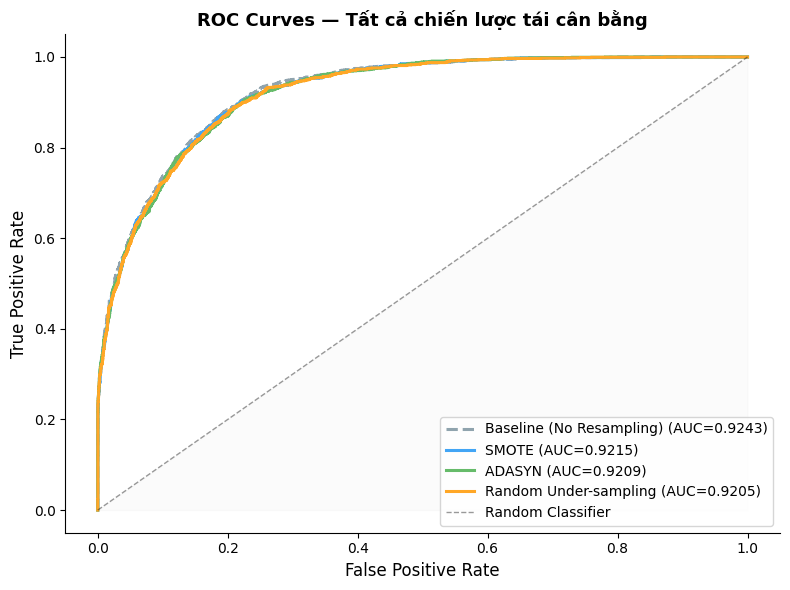

In [22]:
# =============================================================================
# 5C. ROC CURVES
# =============================================================================
from sklearn.metrics import roc_curve
fig, ax = plt.subplots(figsize=(8, 6))

for name, res in results.items():
    fpr, tpr, _ = roc_curve(y_test, res["y_proba"])
    ls  = "--" if "Baseline" in name else "-"
    ax.plot(fpr, tpr, label=f"{name} (AUC={res['AUC-ROC']:.4f})", color=palette[name], linewidth=2.2, linestyle=ls)

ax.plot([0, 1], [0, 1], "k--", linewidth=1, alpha=0.4, label="Random Classifier")
ax.fill_between([0, 1], [0, 0], [0, 1], alpha=0.03, color="gray")
ax.set_xlabel("False Positive Rate", fontsize=12); ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves — Tất cả chiến lược tái cân bằng", fontsize=13, fontweight="bold")
ax.legend(loc="lower right", fontsize=10); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 📌 Nhận xét trực quan: Bức màn thật sự đằng sau Đường cong ROC 

Biểu đồ ROC (Receiver Operating Characteristic) thoạt nhìn có vẻ hơi "nhàm chán" vì các đường cong gần như đè lên nhau hoàn toàn, nhưng chính sự "nhàm chán" này lại mang đến một bài học lý thuyết cực kỳ đắt giá về bản chất của Machine Learning:

- **Sự xếp chồng tuyệt đối:** Dù chúng ta có can thiệp mạnh tay đến đâu (bơm thêm 13,000 mẫu bằng SMOTE hay gọt bỏ 13,000 mẫu bằng Under-sampling), các đường cong ROC vẫn bám sát lấy nhau. Sự chênh lệch diện tích dưới đường cong (AUC) là cực kỳ nhỏ (từ 0.9205 đến 0.9243).
- **Giải mã ý nghĩa toán học:** Chỉ số AUC-ROC đo lường *năng lực xếp hạng (ranking power)* của mô hình – tức là khả năng nó chấm điểm xác suất (probability) cho một người giàu cao hơn một người nghèo. Việc các đường ROC trùng nhau chứng tỏ: Các kỹ thuật tái cân bằng (Resampling) **không hề tạo ra thêm thông tin dự báo mới** hay làm cho mô hình "thông minh" hơn từ gốc. Sức mạnh dự báo thực chất đã được cố định bởi chất lượng của Top 10 đặc trưng đầu vào và bản thân thuật toán Gradient Boosting.
- **Sự thật về Resampling:** Nếu ROC không đổi, vậy tại sao Precision và Recall ở các bước trước lại biến động dữ dội? Câu trả lời là: Kỹ thuật tái cân bằng không làm thay đổi hình dáng đường cong ROC, nó chỉ **trượt điểm cắt (decision threshold)** dọc theo đường cong này. Nó "đánh lừa" mô hình để dời vạch đích, ép mô hình phải hy sinh False Positives để vớt vát True Positives (như trường hợp của Under-sampling).

**💡 Kết luận:** Đối với các bài toán mất cân bằng dữ liệu nặng, ROC Curve là một chỉ số mang tính "ảo giác" (dễ cho điểm rất cao và an toàn). Để thực sự đánh giá hiệu quả kinh doanh, chúng ta bắt buộc phải dựa vào F1-Score, Recall của lớp thiểu số và Ma trận Nhầm lẫn (Confusion Matrix) như đã phân tích ở các phần trước.